In [1]:
#!/usr/bin/env python3
"""
Jupyter Notebook: Energetic materials Model Analysis
Compares three models: D-PARC, PARC-v2, and Large PARC-v2.

This notebook:
1. Loads all three models (run once)
2. Runs parameter comparison
3. Runs visualization on a sample batch
4. Runs global RMSE calculation
"""

################################################################################
# CELL 1: Imports (Combined)
################################################################################
import os
import sys
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob
import csv
from torch.utils.data import DataLoader


# Add project root to system path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

# Import model and data components
from PARCtorch.PARCv2 import PARCv2
from PARCtorch.utilities.unet_deform import UNet
from PARCtorch.data.dataset import GenericPhysicsDataset, custom_collate_fn
from PARCtorch.differentiator.differentiator import ADRDifferentiator as Differentiator
from PARCtorch.differentiator.finitedifference import FiniteDifference
from PARCtorch.integrator.integrator import Integrator
from PARCtorch.integrator.rk4 import RK4

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
################################################################################
# CELL 2: Configuration and Constants (Combined)
################################################################################
"""
Configure all paths, parameters, and settings for all tasks.
"""

# --- Model Checkpoints ---
MODEL_DEFORM_CHECKPOINT = '/home/jtb3sud/weights_dparc/em/DPARC.pth' 
MODEL_NO_DEFORM_CHECKPOINT = '/home/jtb3sud/weights_dparc/em/PARCv2.pth'
MODEL_LARGE_CHECKPOINT = '/home/jtb3sud/weights_dparc/em/PARCv2L.pth'

# --- Data Paths ---
EVAL_DATA_DIR = '/project/vil_baek/data/physics/PARCTorch/HMX/test'
MIN_MAX_PATH = '../data/hmx_min_max.json'
OUTPUT_DIR = '../results/comparison_em_three_models'

# --- General Settings ---
FUTURE_STEPS = 14
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Visualization-Specific Settings ---
BATCH_SIZE = 33  # For visualization dataloader
SAMPLE_ID_TO_COMPARE = 27
TIMESTEPS_TO_COMPARE = [0, 3, 7, 8]
TIME_PER_STEP = 0.17
VIZ_CHANNEL_MAP = {
    'Temperature (T)': 0,
    'Pressure (P)': 1,
    'Microstructure (μ)': 2,
    'Velocity U': 3,
    'Velocity V': 4,
}
CMAP_CONFIG = {
    'Temperature (T)': {'cmap': 'jet', 'label': 'K'},
    'Pressure (P)': {'cmap': 'viridis', 'label': 'Pa'},
    'Microstructure (μ)': {'cmap': 'binary', 'label': ''},
    'Velocity U': {'cmap': 'seismic', 'label': 'm/s'},
    'Velocity V': {'cmap': 'seismic', 'label': 'm/s'},
}

# --- Metrics-Specific Settings (RMSE & SSIM) ---
METRICS_CHANNEL_MAP = {
    'Temperature (T)': 0,
    'Pressure (P)': 1,
    'Microstructure (μ)': 2,
    'Velocity Magnitude': (3, 4),  # Tuple indicates u and v components
}
CHANNEL_UNITS = {
    'Temperature (T)': 'K',
    'Pressure (P)': 'Pa',
    'Microstructure (μ)': '(dimensionless)',
    'Velocity Magnitude': 'm/s',
}
SSIM_WIN_SIZE = 7  # Window size for SSIM computation
SSIM_DATA_RANGE = 1.0  # Data range for normalized data [0, 1]

print(f"✓ Configuration loaded. Using device: {DEVICE}")
print(f"✓ Output will be saved to: {OUTPUT_DIR}")

✓ Configuration loaded. Using device: cuda
✓ Output will be saved to: ../results/comparison_em_three_models


In [3]:
################################################################################
# CELL 3: Model Building and Loading Utilities
################################################################################
"""
Helper functions to build and load models.
"""

def build_model(model_type, device):
    """
    Build the PARCTorch EM model.
    (Using the standardized definition from RMSE/SSIM scripts)
    """
    n_fe_features = 128
    
    if model_type == 'deform':
        unet_em = UNet(
            block_dimensions=[64, 128, 256, 512, 1024],
            input_channels=5,
            output_channels=n_fe_features,
            padding_mode="reflect",
            up_block_use_concat=[False, True, False, True],
            skip_connection_indices=[2, 0],
            use_deform=True
        )
    elif model_type == 'standard':
        unet_em = UNet(
            block_dimensions=[64, 128, 256, 512, 1024],
            input_channels=5,
            output_channels=n_fe_features,
            padding_mode="reflect",
            up_block_use_concat=[False, True, False, True],
            skip_connection_indices=[2, 0],
            use_deform=False
        )
    elif model_type == 'large':
        unet_em = UNet(
            block_dimensions=[64, 64*2, 64*4, 64*8, 64*16, 64*32, 64*64],
            input_channels=5,
            output_channels=n_fe_features,
            padding_mode="reflect",
            up_block_use_concat=[False, True, False, True, False, False],
            skip_connection_indices=[4, 2],
            use_deform=False
        )
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    right_diff = FiniteDifference(padding_mode="replicate")
    rk4_int = RK4()

    diff_em = Differentiator(
        3,
        n_fe_features,
        [0, 1, 2, 3, 4],
        [0],
        unet_em,
        "constant",
        right_diff,
        True
    )

    ddi_list = [None] * 5

    em_int = Integrator(
        True,
        [],
        rk4_int,
        ddi_list,
        "constant",
        right_diff,
    )

    criterion = torch.nn.L1Loss()

    model = PARCv2(
        differentiator=diff_em,
        integrator=em_int,
        loss=criterion
    )
    
    model = model.to(device)
    return model


def load_model(model, weights_path, device):
    if weights_path is None:
        logging.info("No weights path provided. Training will start from scratch.")
        return model
    #logging.info(f"Loading model weights from {weights_path}...")
    try:
        checkpoint = torch.load(weights_path, map_location=device)
        
        # Handle wrapped checkpoint format (with metadata)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            # Raw state dict
            state_dict = checkpoint
        
        model.load_state_dict(state_dict)
    except Exception as e:
        print("error")
        raise
    model.eval()
    return model

print("✓ Model utility functions defined.")

✓ Model utility functions defined.


In [4]:
################################################################################
# CELL 4: Build and Load All Models (Run Once)
################################################################################

# Clear CUDA cache before building models
if DEVICE == 'cuda':
    torch.cuda.empty_cache()
    print("✓ CUDA cache cleared")

# Build and load all three models
print("Building models...")
try:
    model_deform = build_model('deform', DEVICE)
    model_standard = build_model('standard', DEVICE)
    model_large = build_model('large', DEVICE)
except RuntimeError as e:
    if "CUDA" in str(e):
        print("⚠️ CUDA error detected. Clearing cache and retrying...")
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        model_deform = build_model('deform', DEVICE)
        model_standard = build_model('standard', DEVICE)
        model_large = build_model('large', DEVICE)
    else:
        raise

print("Loading model checkpoints...")
model_deform = load_model(model_deform, MODEL_DEFORM_CHECKPOINT, DEVICE)
model_standard = load_model(model_standard, MODEL_NO_DEFORM_CHECKPOINT, DEVICE)
model_large = load_model(model_large, MODEL_LARGE_CHECKPOINT, DEVICE)

print("✓ All three models built and loaded successfully")

✓ CUDA cache cleared
Building models...
Loading model checkpoints...
✓ All three models built and loaded successfully


In [5]:
################################################################################
# CELL 5: Load Normalization Parameters (Run Once)
################################################################################

with open(MIN_MAX_PATH, 'r') as f:
    norm_params = json.load(f)

print(f"✓ Normalization parameters loaded from: {MIN_MAX_PATH}")

def denormalize(channel_idx, tensor, norm_params):
    """Denormalize a tensor for a specific channel."""
    # (Moved this utility function here as it's used by Viz and RMSE)
    channel_min = norm_params["channel_min"][channel_idx]
    channel_max = norm_params["channel_max"][channel_idx]
    return tensor * (channel_max - channel_min) + channel_min

print(f"✓ Denormalization utility function defined.")

✓ Normalization parameters loaded from: ../data/hmx_min_max.json
✓ Denormalization utility function defined.


In [6]:
################################################################################
# CELL 6: Task 1 - Model Parameter Comparison
################################################################################
def count_parameters(model):
    """Count trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_model_size_mb(model):
    """Calculate model size in MB."""
    param_size = 0
    buffer_size = 0
    
    # Count parameters (trainable and non-trainable)
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    
    # Count buffers (e.g., running stats in batch norm)
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    
    size_all_mb = (param_size + buffer_size) / 1024**2
    return size_all_mb

# Count parameters and get model sizes
params_deform = count_parameters(model_deform)
params_standard = count_parameters(model_standard)
params_large = count_parameters(model_large)

size_deform = get_model_size_mb(model_deform)
size_standard = get_model_size_mb(model_standard)
size_large = get_model_size_mb(model_large)

print("\n" + "="*80)
print("MODEL PARAMETER COMPARISON")
print("="*80)
print(f"D-PARC (deformable conv):     {params_deform:,} params | {size_deform:.2f} MB")
print(f"PARC-v2 (standard):         {params_standard:,} params | {size_standard:.2f} MB")
print(f"Large PARC-v2:              {params_large:,} params | {size_large:.2f} MB")
print(f"\nParameter Differences:")
print(f"  Deform vs Standard:         {params_deform - params_standard:+,} ({100*(params_deform - params_standard)/params_standard:+.2f}%)")
print(f"  Large vs Standard:          {params_large - params_standard:+,} ({100*(params_large - params_standard)/params_standard:+.2f}%)")
print(f"  Large vs Deform:            {params_large - params_deform:+,} ({100*(params_large - params_deform)/params_deform:+.2f}%)")
print(f"\nModel Size Differences:")
print(f"  Deform vs Standard:         {size_deform - size_standard:+.2f} MB ({100*(size_deform - size_standard)/size_standard:+.2f}%)")
print(f"  Large vs Standard:          {size_large - size_standard:+.2f} MB ({100*(size_large - size_standard)/size_standard:+.2f}%)")
print(f"  Large vs Deform:            {size_large - size_deform:+.2f} MB ({100*(size_large - size_deform)/size_deform:+.2f}%)")
print("="*80 + "\n")


MODEL PARAMETER COMPARISON
D-PARC (deformable conv):     19,745,873 params | 75.32 MB
PARC-v2 (standard):         19,229,509 params | 73.35 MB
Large PARC-v2:              243,569,477 params | 929.14 MB

Parameter Differences:
  Deform vs Standard:         +516,364 (+2.69%)
  Large vs Standard:          +224,339,968 (+1166.64%)
  Large vs Deform:            +223,823,604 (+1133.52%)

Model Size Differences:
  Deform vs Standard:         +1.97 MB (+2.69%)
  Large vs Standard:          +855.79 MB (+1166.64%)
  Large vs Deform:            +853.82 MB (+1133.52%)



In [7]:
################################################################################
# CELL 8: Find All Test Files (for Metrics)
################################################################################

test_files = sorted(glob.glob(os.path.join(EVAL_DATA_DIR, '*.npy')))
print(f"Found {len(test_files)} simulation files for metrics calculation.")

Found 32 simulation files for metrics calculation.


In [8]:
################################################################################
# CELL 9E: Task 3E - Wall Clock Time Benchmark (Inference, Resolution-Normalized)
################################################################################

import time
import platform

# Set this once per notebook: "burgers", "navier_stokes", or "em"
DATASET_TAG = "em"  # <-- change this per notebook

print("\n" + "="*80)
print(f"[{DATASET_TAG}] BENCHMARKING WALL CLOCK INFERENCE TIME")
print("="*80)

# ============================================================================
# HARDWARE INFO (for reproducibility / reporting alongside timing results)
# ============================================================================
print("\n" + "="*80)
print("HARDWARE CONFIGURATION")
print("="*80)

if torch.cuda.is_available():
    gpu_idx = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(gpu_idx)
    gpu_props = torch.cuda.get_device_properties(gpu_idx)
    total_mem_gb = gpu_props.total_memory / (1024**3)
    cuda_version = torch.version.cuda
    cudnn_version = torch.backends.cudnn.version()

    print(f"GPU: {gpu_name}")
    print(f"Total GPU Memory: {total_mem_gb:.2f} GB")
    print(f"Compute Capability: {gpu_props.major}.{gpu_props.minor}")
    print(f"CUDA Version: {cuda_version}")
    print(f"cuDNN Version: {cudnn_version}")
    print(f"PyTorch Version: {torch.__version__}")

    hardware_info = {
        'device': gpu_name,
        'total_memory_gb': f'{total_mem_gb:.2f}',
        'compute_capability': f'{gpu_props.major}.{gpu_props.minor}',
        'cuda_version': str(cuda_version),
        'cudnn_version': str(cudnn_version),
        'pytorch_version': torch.__version__,
    }
else:
    cpu_name = platform.processor() or "Unknown CPU"
    print(f"No GPU detected — running on CPU: {cpu_name}")
    print(f"PyTorch Version: {torch.__version__}")

    hardware_info = {
        'device': f'CPU ({cpu_name})',
        'total_memory_gb': 'N/A',
        'compute_capability': 'N/A',
        'cuda_version': 'N/A',
        'cudnn_version': 'N/A',
        'pytorch_version': torch.__version__,
    }
print("="*80)

# ============================================================================
# CONFIG
# ============================================================================
N_WARMUP = 10          # untimed warmup runs — lets cuDNN pick kernels, avoids first-call overhead
N_TRIALS = 50          # timed runs to average over
BENCHMARK_BATCH_SIZE = 1  # set >1 if you want throughput at larger batch sizes too

models_to_benchmark = {
    'D-PARC': model_deform,
    'PARCv2': model_standard,
    'PARCv2-L': model_large,
}

# Use one representative test file to build a realistic input (same shape as your real inference)
sample_file = test_files[0]
full_sim = np.load(sample_file)
full_sim_tensor = torch.from_numpy(full_sim).float().to(DEVICE)

normalized_sim = torch.zeros_like(full_sim_tensor)
for ch in range(full_sim_tensor.shape[1]):
    channel_min = norm_params["channel_min"][ch]
    channel_max = norm_params["channel_max"][ch]
    normalized_sim[:, ch, :, :] = (full_sim_tensor[:, ch, :, :] - channel_min) / (channel_max - channel_min)

ic_single = normalized_sim[0:1, :, :, :]
ic = ic_single.repeat(BENCHMARK_BATCH_SIZE, 1, 1, 1)  # replicate for batch-size testing

# Capture spatial resolution for cross-dataset normalization
grid_h, grid_w = ic_single.shape[-2], ic_single.shape[-1]
n_pixels = grid_h * grid_w
n_megapixels = n_pixels / 1e6
print(f"\nGrid resolution: {grid_h} x {grid_w}  ({n_megapixels:.4f} megapixels)")

num_steps_to_predict = min(FUTURE_STEPS, full_sim_tensor.shape[0] - 1)
t0 = torch.tensor(0.0, device=DEVICE)
t1 = torch.arange(1, num_steps_to_predict + 1, dtype=torch.float32, device=DEVICE) / num_steps_to_predict

# ============================================================================
# BENCHMARK FUNCTION
# ============================================================================
def benchmark_model(model, ic, t0, t1, n_warmup, n_trials, device):
    model.eval()
    use_cuda = (device.type == 'cuda') if isinstance(device, torch.device) else ('cuda' in str(device))

    # --- Warmup (untimed) ---
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(ic, t0, t1)
    if use_cuda:
        torch.cuda.synchronize()

    times_ms = []

    if use_cuda:
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)
        with torch.no_grad():
            for _ in range(n_trials):
                starter.record()
                _ = model(ic, t0, t1)
                ender.record()
                torch.cuda.synchronize()
                times_ms.append(starter.elapsed_time(ender))  # milliseconds
    else:
        # CPU fallback: perf_counter is safe here since CPU ops are synchronous
        with torch.no_grad():
            for _ in range(n_trials):
                start = time.perf_counter()
                _ = model(ic, t0, t1)
                end = time.perf_counter()
                times_ms.append((end - start) * 1000.0)

    times_ms = np.array(times_ms)
    return times_ms

# ============================================================================
# RUN BENCHMARKS
# ============================================================================
timing_results = {}

for model_name, model in models_to_benchmark.items():
    print(f"\nBenchmarking {model_name}...")
    times_ms = benchmark_model(model, ic, t0, t1, N_WARMUP, N_TRIALS, DEVICE)
    timing_results[model_name] = times_ms

    mean_ms = times_ms.mean()
    std_ms = times_ms.std()
    median_ms = np.median(times_ms)
    per_step_ms = mean_ms / num_steps_to_predict

    print(f"  Full rollout ({num_steps_to_predict} steps): "
          f"{mean_ms:.3f} ± {std_ms:.3f} ms  (median: {median_ms:.3f} ms)")
    print(f"  Per-timestep: {per_step_ms:.4f} ms/step")

# ============================================================================
# PRINT COMPARISON TABLE + RELATIVE SPEEDUP (RESOLUTION-NORMALIZED)
# ============================================================================
print("\n" + "="*80)
print(f"[{DATASET_TAG}] WALL CLOCK TIME COMPARISON (Full Rollout)")
print("="*80)
print(f"{'Model':<15} {'Mean (ms)':<15} {'Per-Step (ms)':<18} {'Per-Step/MPx (ms)':<20} {'Relative to PARCv2':<20}")
print("-" * 100)

baseline_mean = timing_results['PARCv2'].mean()

timing_csv_rows = []
for model_name, times_ms in timing_results.items():
    mean_ms = times_ms.mean()
    std_ms = times_ms.std()
    per_step_ms = mean_ms / num_steps_to_predict
    per_step_per_mpx_ms = per_step_ms / n_megapixels  # resolution-normalized
    relative = mean_ms / baseline_mean

    relative_str = f"{relative:.2f}x" if model_name != 'PARCv2' else "1.00x (baseline)"
    print(f"{model_name:<15} {mean_ms:<15.3f} {per_step_ms:<18.4f} {per_step_per_mpx_ms:<20.4f} {relative_str:<20}")

    timing_csv_rows.append([
        model_name, f'{mean_ms:.4f}', f'{std_ms:.4f}', f'{np.median(times_ms):.4f}',
        f'{per_step_ms:.5f}', f'{per_step_per_mpx_ms:.5f}', f'{relative:.4f}',
        f'{grid_h}x{grid_w}',
    ])

# ============================================================================
# SAVE TO CSV (with hardware metadata header)
# ============================================================================
timing_csv_path = os.path.join(OUTPUT_DIR, f'wall_clock_timing_{DATASET_TAG}.csv')
with open(timing_csv_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['# Hardware Configuration'])
    for key, val in hardware_info.items():
        writer.writerow([f'# {key}', val])
    writer.writerow([])  # blank line separating metadata from data
    writer.writerow(['Model', 'Mean_ms', 'Std_ms', 'Median_ms', 'Per_Step_ms',
                      'Per_Step_Per_Megapixel_ms', 'Relative_to_PARCv2', 'Grid_Resolution'])
    writer.writerows(timing_csv_rows)

print(f"\n✓ [{DATASET_TAG}] Wall clock timing results saved to: {timing_csv_path}")
print("="*80)


[em] BENCHMARKING WALL CLOCK INFERENCE TIME

HARDWARE CONFIGURATION
GPU: NVIDIA A100-SXM4-80GB
Total GPU Memory: 79.25 GB
Compute Capability: 8.0
CUDA Version: 12.8
cuDNN Version: 91002
PyTorch Version: 2.9.1+cu128

Grid resolution: 128 x 256  (0.0328 megapixels)

Benchmarking D-PARC...
  Full rollout (14 steps): 923.603 ± 91.602 ms  (median: 890.214 ms)
  Per-timestep: 65.9716 ms/step

Benchmarking PARCv2...
  Full rollout (14 steps): 938.143 ± 182.173 ms  (median: 880.571 ms)
  Per-timestep: 67.0102 ms/step

Benchmarking PARCv2-L...
  Full rollout (14 steps): 1501.138 ± 121.438 ms  (median: 1512.182 ms)
  Per-timestep: 107.2242 ms/step

[em] WALL CLOCK TIME COMPARISON (Full Rollout)
Model           Mean (ms)       Per-Step (ms)      Per-Step/MPx (ms)    Relative to PARCv2  
----------------------------------------------------------------------------------------------------
D-PARC          923.603         65.9716            2013.2941            0.98x               
PARCv2          93

Loading evaluation dataset...


Listing samples: 100%|██████████| 32/32 [00:00<00:00, 39.98it/s]


✓ Dataset loaded. Total samples: 32
Loading SPECIFIC sample 0 for visualization...
Running predictions on the single sample...
✓ Predictions complete

CHECKING DATA ALIGNMENT
IC shape: torch.Size([1, 5, 128, 256]), Ground truth shape: torch.Size([14, 1, 5, 128, 256])
Does IC match GT[0]? False
✓ Ground truth EXCLUDES t=0. Alignment: pred[t] ↔ gt[t]

Organizing data for plotting...
Processing Temperature (T)...
Features to be plotted: ['Temperature (T)']

Generating plot...


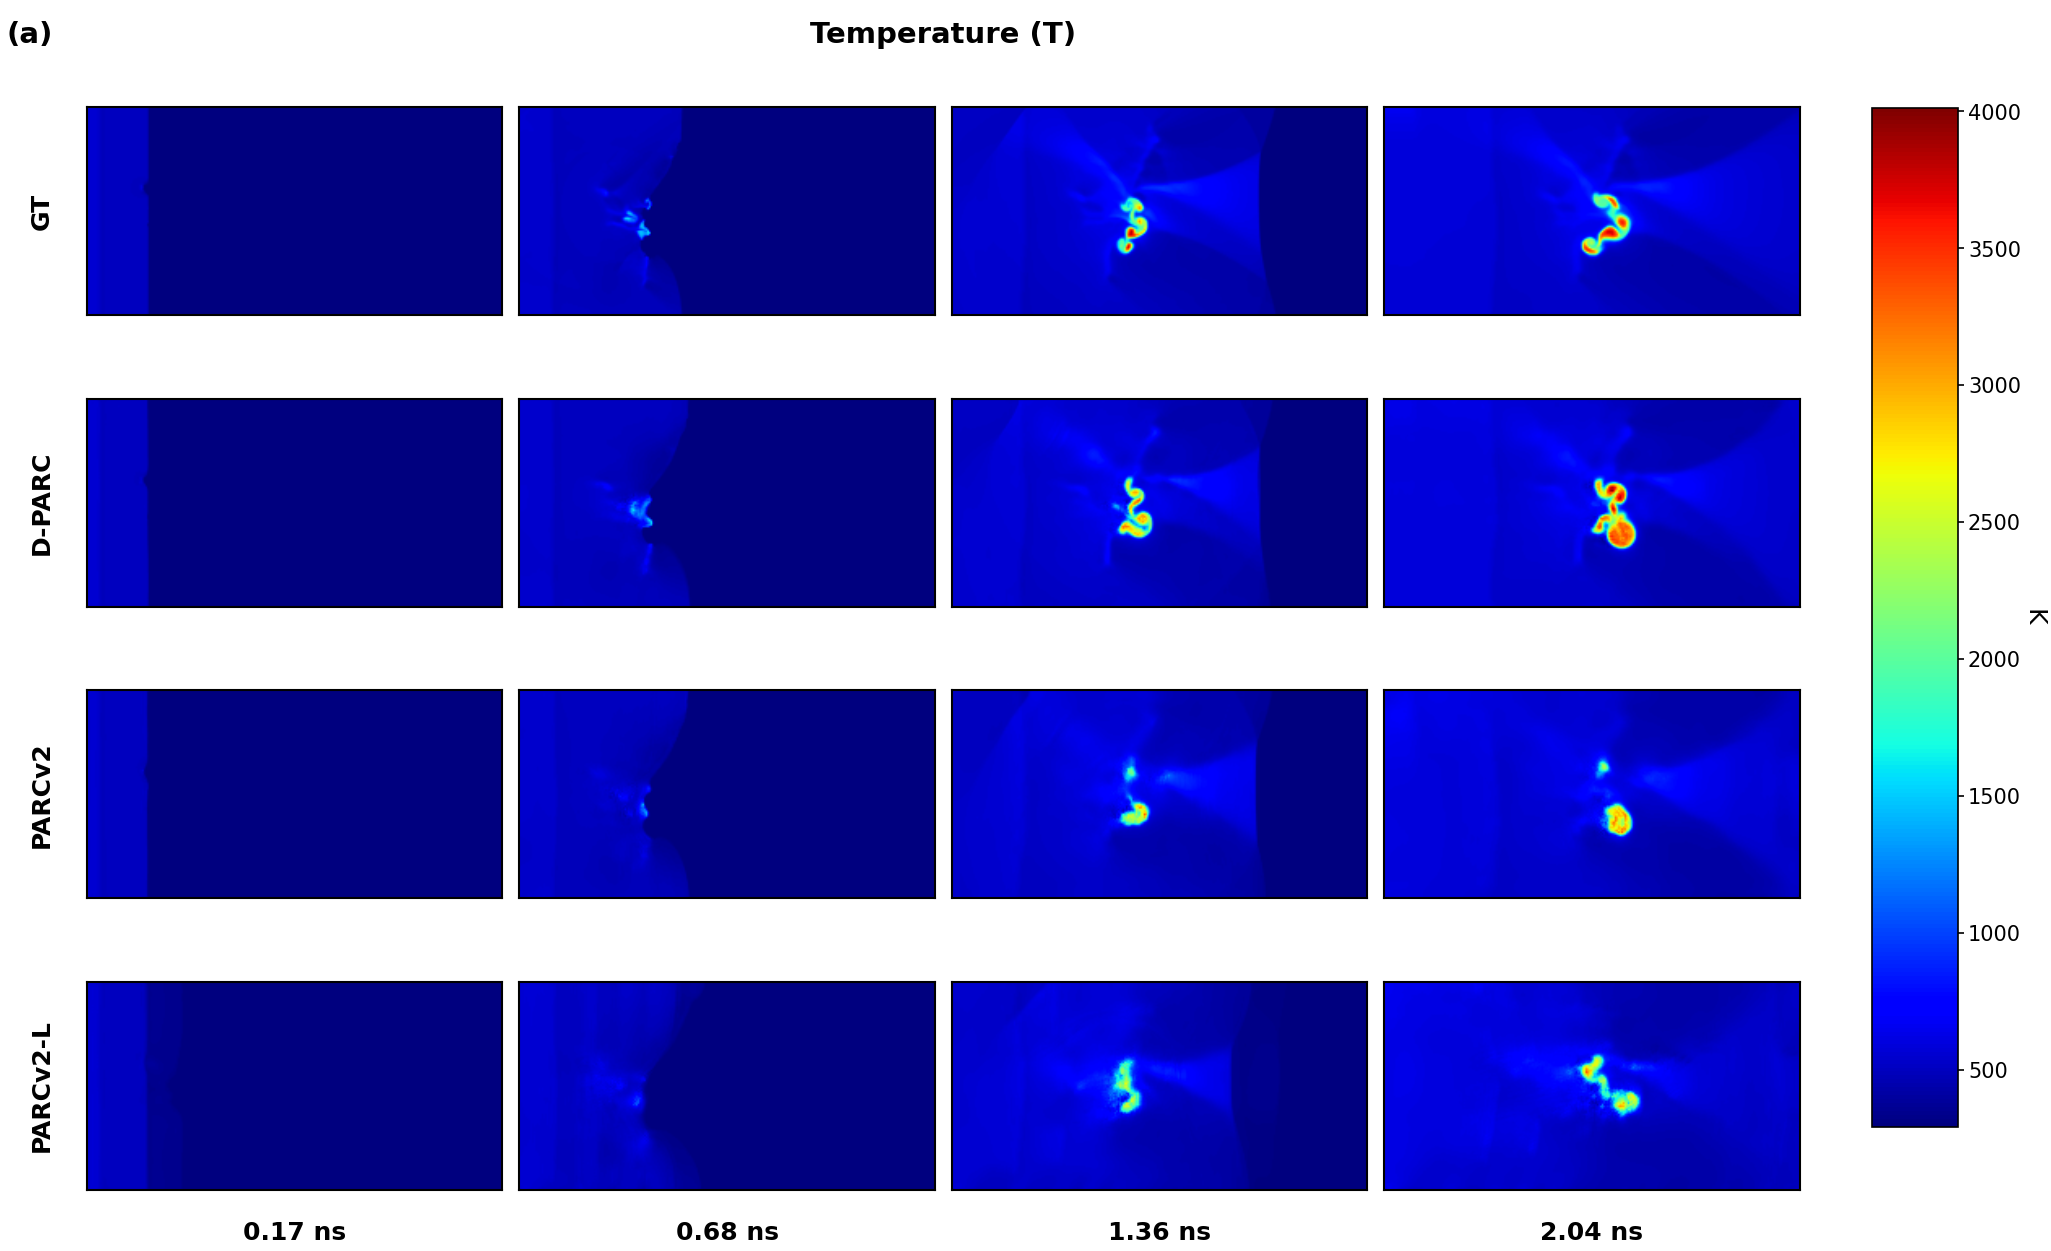

✓ Plot saved as PDF: /home/jtb3sud/PARCtorch/PARCtorch/scripts/results/em_comparison_temperature_sample0.pdf
✓ Plot saved as PNG: /home/jtb3sud/PARCtorch/PARCtorch/scripts/results/em_comparison_temperature_sample0.png

✓ Visualization complete!


In [9]:
################################################################################
# CELL 7 (EMS Refactored): Visualizing Temperature with Publication Formatting
################################################################################

# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from pathlib import Path
import os
import torch

# --- Configuration ---
# Select the specific sample ID to compare
SAMPLE_ID_TO_COMPARE = 0  # Change this to look at different samples
TIMESTEPS_TO_COMPARE = [0, 3, 7, 11] # Adjust as needed

# --- 7a. Load Data for Visualization ---
print("Loading evaluation dataset...")
eval_dataset = GenericPhysicsDataset(
    data_dirs=[EVAL_DATA_DIR],
    future_steps=FUTURE_STEPS,
    min_max_path=MIN_MAX_PATH
)

# We use the collate_fn to manually build a batch of size 1 for the specific sample
eval_loader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=1,
    pin_memory=True if DEVICE == 'cuda' else False,
    collate_fn=custom_collate_fn
)
print(f"✓ Dataset loaded. Total samples: {len(eval_dataset)}")

# --- 7b. Run Predictions for Visualization ---
print(f"Loading SPECIFIC sample {SAMPLE_ID_TO_COMPARE} for visualization...")

if SAMPLE_ID_TO_COMPARE >= len(eval_dataset):
    print(f"⚠️ SAMPLE_ID_TO_COMPARE ({SAMPLE_ID_TO_COMPARE}) is out of range! Defaulting to 0.")
    SAMPLE_ID_TO_COMPARE = 0

# Get the specific sample and create a batch of size 1
sample_data = eval_dataset[SAMPLE_ID_TO_COMPARE]
batch = custom_collate_fn([sample_data])

print("Running predictions on the single sample...")
ic, t0, t1, ground_truth = batch

ic = ic.to(DEVICE)
t0 = t0.to(DEVICE)
t1 = t1.to(DEVICE)
ground_truth = ground_truth.to(DEVICE)

with torch.no_grad():
    pred_deform = model_deform(ic, t0, t1)
    pred_standard = model_standard(ic, t0, t1)
    pred_large = model_large(ic, t0, t1)

print(f"✓ Predictions complete")

# --- Output directory (PASS THIS IN) ---
OUTPUT_DIR = "/home/jtb3sud/PARCtorch/PARCtorch/scripts/results"   # <- change as needed


# --- 7c. Check Alignment ---
print("\n" + "="*80)
print("CHECKING DATA ALIGNMENT")
print(f"IC shape: {ic.shape}, Ground truth shape: {ground_truth.shape}")
ic_matches_gt0 = torch.allclose(ic[0], ground_truth[0, 0], atol=1e-6)
print(f"Does IC match GT[0]? {ic_matches_gt0}")
if ic_matches_gt0:
    print("✓ Ground truth INCLUDES t=0. Alignment: pred[t] ↔ gt[t+1]")
else:
    print("✓ Ground truth EXCLUDES t=0. Alignment: pred[t] ↔ gt[t]")
print("="*80 + "\n")

# --- 7d. Organize Data for Plotting ---
print("Organizing data for plotting...")
data_to_plot = {}
features_to_plot = [] 
models_to_plot = ['ground_truth', 'deform', 'standard', 'large']
sample_idx_in_batch = 0 

# --- FILTER: Look specifically for 'Temperature' ---
# If you want to see other fields, add them to this list or logic
desired_fields = ['Temperature (T)'] 

for feature_name, channel_idx in VIZ_CHANNEL_MAP.items():
    # Only process if it matches our desired fields (or if you want everything, remove the if)
    if feature_name not in desired_fields:
        continue

    print(f"Processing {feature_name}...")
    features_to_plot.append(feature_name)
    data_to_plot[feature_name] = {ts: {} for ts in TIMESTEPS_TO_COMPARE}
    
    for ts in TIMESTEPS_TO_COMPARE:
        if ts >= ground_truth.shape[0]:
            continue
            
        for model_name, pred_tensor in zip(models_to_plot, [ground_truth, pred_deform, pred_standard, pred_large]):
            
            # Extract data (shape: [H, W])
            data = pred_tensor[ts, sample_idx_in_batch, channel_idx, :, :].cpu()
            
            # Denormalize
            denorm_data = denormalize(channel_idx, data, norm_params).numpy()
            data_to_plot[feature_name][ts][model_name] = denorm_data

print(f"Features to be plotted: {features_to_plot}")

# --- 7e. Plotting Style Function ---
def set_publication_style():
    """Set publication-quality matplotlib style parameters."""
    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'font.size': 6,
        'axes.labelsize': 6,
        'axes.titlesize': 7,
        'xtick.labelsize': 5,
        'ytick.labelsize': 5,
        'legend.fontsize': 5,
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.02,
        'axes.linewidth': 0.5,
        'xtick.major.width': 0.5,
        'ytick.major.width': 0.5,
    })

# --- 7f. Generate Plot ---
print("\nGenerating plot...")
if not data_to_plot or not features_to_plot:
    print("⚠️ The `data_to_plot` dictionary is empty or desired features were not found.")
else:
    set_publication_style()
    
    features = features_to_plot
    timesteps = TIMESTEPS_TO_COMPARE
    num_features = len(features)
    num_timesteps = len(timesteps)
    
    row_names = ['ground_truth', 'deform', 'standard', 'large']
    row_labels = ['GT', 'D-PARC', 'PARCv2', 'PARCv2-L']
    num_models = len(row_names)
    
    # --- Figure Sizing (Matches NS Gold Standard) ---
    first_grid = next(iter(next(iter(data_to_plot.values())).values()))['ground_truth']
    ny, nx = first_grid.shape
    data_aspect_ratio = ny / nx

    fig_width_mm = 180
    fig_width_in = fig_width_mm / 25.4
    
    panel_height_in = (fig_width_in / num_timesteps) * data_aspect_ratio
    fig_height_in = panel_height_in * (num_models + 0.5) * num_features * 1.1 
    
    fig = plt.figure(figsize=(fig_width_in, fig_height_in))
    
    # --- Outer GridSpec ---
    outer_gs = gridspec.GridSpec(
        num_features, 2, figure=fig,
        width_ratios=[1, 0.05], # Plot column, Cbar column
        wspace=0.08, hspace=0.2,
        top=0.98, bottom=0.05, left=0.1, right=0.98
    )
    
    subfig_labels = ['a', 'b', 'c', 'd', 'e', 'f']
    
    for i, feature in enumerate(features):
        
        # --- Determine vmin/vmax for the *entire feature block* ---
        all_grids = []
        for ts in timesteps:
            if ts not in data_to_plot[feature]: continue
            for model_name in row_names:
                if model_name in data_to_plot[feature][ts]:
                    all_grids.append(data_to_plot[feature][ts][model_name])
        
        if not all_grids:
            continue
            
        vmin = min(g.min() for g in all_grids)
        vmax = max(g.max() for g in all_grids)
        
        # Get cmap from config or default to inferno for temperature
        if feature in CMAP_CONFIG:
            cmap = CMAP_CONFIG[feature]['cmap']
            cbar_label = CMAP_CONFIG[feature]['label']
        else:
            cmap = 'inferno' # Good default for temperature
            cbar_label = 'K'

        # Symmetrize if seismic/diverging
        if cmap == 'seismic' or cmap == 'coolwarm':
            abs_max = max(abs(vmin), abs(vmax))
            vmin = -abs_max
            vmax = abs_max

        # --- Inner GridSpec ---
        inner_gs_spec = outer_gs[i, 0]
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            num_models + 1, num_timesteps, subplot_spec=inner_gs_spec,
            height_ratios=[0.2] + [1] * num_models, 
            hspace=0.02, wspace=0.04
        )
        
        # --- Feature Title ---
        title_ax = fig.add_subplot(inner_gs[0, :])
        title_ax.text(-0.02, 0.5, f"({subfig_labels[i]})",
                      fontsize=7, weight='bold',
                      rotation=0, va='center', ha='right',
                      transform=title_ax.transAxes)
        
        feature_display = feature.replace('_', ' ').title()
        title_ax.text(0.5, 0.5, feature_display,
                      fontsize=7, weight='bold',
                      va='center', ha='center',
                      transform=title_ax.transAxes)
        title_ax.axis('off')

        # --- Plotting Loop ---
        im = None 
        for row_idx, (row_name, row_label) in enumerate(zip(row_names, row_labels)):
            for j, ts in enumerate(timesteps):
                ax = fig.add_subplot(inner_gs[row_idx + 1, j])
                
                if ts in data_to_plot[feature] and row_name in data_to_plot[feature][ts]:
                    grid = data_to_plot[feature][ts][row_name]
                    im = ax.imshow(
                        grid, cmap=cmap, vmin=vmin, vmax=vmax,
                        interpolation='bilinear', aspect='equal', 
                        origin='lower' # KEPT 'lower' for EMS/Solid Mechanics
                    )
                else:
                    ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                            transform=ax.transAxes, fontsize=5)

                # --- Labels ---
                if row_idx == num_models - 1: # Time labels
                    time_seconds = (ts + 1) * TIME_PER_STEP 
                    ax.text(0.5, -0.15, f"{time_seconds:.2f} ns", fontsize=6,
                            ha='center', va='top', transform=ax.transAxes,
                            weight='bold')
                
                if j == 0: # Model labels
                    ax.text(-0.08, 0.5, row_label, fontsize=6, weight='bold',
                            rotation=90, va='center', ha='right',
                            transform=ax.transAxes)
                
                ax.set_xticks([])
                ax.set_yticks([])

        # --- Colorbar ---
        if im:
            cbar_gs = gridspec.GridSpecFromSubplotSpec(
                3, 1, subplot_spec=outer_gs[i, 1],
                height_ratios=[0.1, 1, 0.1], 
                hspace=0 
            )
            cax = fig.add_subplot(cbar_gs[1, 0])

            cbar = plt.colorbar(im, cax=cax, aspect=15) 
            cbar.ax.tick_params(labelsize=5, width=0.4, length=1.5, pad=1)
            cbar.outline.set_linewidth(0.4)
            if cbar_label:
                cbar.set_label(cbar_label, rotation=270, labelpad=6, fontsize=6)

    # --- Save ---
    output_dir = Path(OUTPUT_DIR)
    output_dir.mkdir(exist_ok=True)
    
    pdf_path = output_dir / f"em_comparison_temperature_sample{SAMPLE_ID_TO_COMPARE}.pdf"
    png_path = output_dir / f"em_comparison_temperature_sample{SAMPLE_ID_TO_COMPARE}.png"

    plt.savefig(pdf_path)
    plt.savefig(png_path)
    plt.show()
    plt.close(fig)

    print(f"✓ Plot saved as PDF: {pdf_path}")
    print(f"✓ Plot saved as PNG: {png_path}")

print("\n" + "="*80)
print("✓ Visualization complete!")
print("="*80)

In [10]:
################################################################################
# CELL 9B: Task 3B - Calculate Global RMSE + SSIM (Per-Channel)
################################################################################

from skimage.metrics import structural_similarity as ssim_sk

print("\n" + "="*80)
print("COMPUTING PER-CHANNEL GLOBAL RMSE + SSIM")
print("="*80)

# ============================================================================
# INITIALIZE ACCUMULATORS
# ============================================================================

# RMSE accumulators
squared_error_sum_deform_norm = {}
squared_error_sum_standard_norm = {}
squared_error_sum_large_norm = {}
squared_error_sum_deform_denorm = {}
squared_error_sum_standard_denorm = {}
squared_error_sum_large_denorm = {}
element_count = {}

# SSIM accumulators (computed on normalized fields to avoid overflow)
ssim_sum_deform = {}
ssim_sum_standard = {}
ssim_sum_large = {}
ssim_frame_count = {}

for feature_name in METRICS_CHANNEL_MAP.keys():
    squared_error_sum_deform_norm[feature_name] = 0.0
    squared_error_sum_standard_norm[feature_name] = 0.0
    squared_error_sum_large_norm[feature_name] = 0.0
    squared_error_sum_deform_denorm[feature_name] = 0.0
    squared_error_sum_standard_denorm[feature_name] = 0.0
    squared_error_sum_large_denorm[feature_name] = 0.0
    element_count[feature_name] = 0
    ssim_sum_deform[feature_name] = 0.0
    ssim_sum_standard[feature_name] = 0.0
    ssim_sum_large[feature_name] = 0.0
    ssim_frame_count[feature_name] = 0

def compute_ssim_series(pred_field, gt_field):
    """SSIM on normalized [T, H, W] fields. Cast to float64 to avoid
    overflow in skimage's internal variance/covariance terms."""
    pred_np = pred_field.detach().cpu().numpy().astype(np.float64)
    gt_np = gt_field.detach().cpu().numpy().astype(np.float64)
    data_range = gt_np.max() - gt_np.min()
    if data_range == 0:
        data_range = 1e-8
    frame_ssims = [
        ssim_sk(gt_np[t], pred_np[t], data_range=data_range)
        for t in range(pred_np.shape[0])
    ]
    return float(np.mean(frame_ssims))

# ============================================================================
# MAIN PROCESSING LOOP
# ============================================================================

for file_idx, test_file in enumerate(test_files):
    progress = (file_idx + 1) / len(test_files)
    bar_length = 40
    filled_length = int(bar_length * progress)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    print(f'\rProcessing: |{bar}| {file_idx + 1}/{len(test_files)} ({progress:.1%})', end='', flush=True)
    
    full_sim = np.load(test_file)
    full_sim_tensor = torch.from_numpy(full_sim).float().to(DEVICE)
    
    normalized_sim = torch.zeros_like(full_sim_tensor)
    for ch in range(full_sim_tensor.shape[1]):
        channel_min = norm_params["channel_min"][ch]
        channel_max = norm_params["channel_max"][ch]
        normalized_sim[:, ch, :, :] = (full_sim_tensor[:, ch, :, :] - channel_min) / (channel_max - channel_min)
    
    ic = normalized_sim[0:1, :, :, :]
    num_steps_to_predict = min(FUTURE_STEPS, full_sim_tensor.shape[0] - 1)
    t0 = torch.tensor(0.0, device=DEVICE)
    t1 = torch.arange(1, num_steps_to_predict + 1, dtype=torch.float32, device=DEVICE) / num_steps_to_predict
    ground_truth_file = normalized_sim[1:num_steps_to_predict+1, :, :, :]
    
    with torch.no_grad():
        pred_deform_file = model_deform(ic, t0, t1)
        pred_standard_file = model_standard(ic, t0, t1)
        pred_large_file = model_large(ic, t0, t1)
    
    min_len = min(pred_deform_file.shape[0], ground_truth_file.shape[0])
    pred_deform_aligned = pred_deform_file[:min_len]
    pred_standard_aligned = pred_standard_file[:min_len]
    pred_large_aligned = pred_large_file[:min_len]
    gt_aligned = ground_truth_file[:min_len].unsqueeze(1)
    
    # ========================================================================
    # COMPUTE RMSE + SSIM METRICS
    # ========================================================================
    for feature_name, channel_idx in METRICS_CHANNEL_MAP.items():
        if isinstance(channel_idx, tuple):
            ch_u, ch_v = channel_idx
            
            gt_u_norm = gt_aligned[:, 0, ch_u, :, :]
            gt_v_norm = gt_aligned[:, 0, ch_v, :, :]
            pred_d_u_norm = pred_deform_aligned[:, 0, ch_u, :, :]
            pred_d_v_norm = pred_deform_aligned[:, 0, ch_v, :, :]
            pred_s_u_norm = pred_standard_aligned[:, 0, ch_u, :, :]
            pred_s_v_norm = pred_standard_aligned[:, 0, ch_v, :, :]
            pred_l_u_norm = pred_large_aligned[:, 0, ch_u, :, :]
            pred_l_v_norm = pred_large_aligned[:, 0, ch_v, :, :]
            
            gt_vel_mag_norm = torch.sqrt(gt_u_norm**2 + gt_v_norm**2)
            pred_d_vel_mag_norm = torch.sqrt(pred_d_u_norm**2 + pred_d_v_norm**2)
            pred_s_vel_mag_norm = torch.sqrt(pred_s_u_norm**2 + pred_s_v_norm**2)
            pred_l_vel_mag_norm = torch.sqrt(pred_l_u_norm**2 + pred_l_v_norm**2)
            
            sq_err_d_norm = (pred_d_vel_mag_norm - gt_vel_mag_norm) ** 2
            sq_err_s_norm = (pred_s_vel_mag_norm - gt_vel_mag_norm) ** 2
            sq_err_l_norm = (pred_l_vel_mag_norm - gt_vel_mag_norm) ** 2
            
            squared_error_sum_deform_norm[feature_name] += torch.sum(sq_err_d_norm).item()
            squared_error_sum_standard_norm[feature_name] += torch.sum(sq_err_s_norm).item()
            squared_error_sum_large_norm[feature_name] += torch.sum(sq_err_l_norm).item()
            
            gt_u_denorm = denormalize(ch_u, gt_u_norm, norm_params)
            gt_v_denorm = denormalize(ch_v, gt_v_norm, norm_params)
            pred_d_u_denorm = denormalize(ch_u, pred_d_u_norm, norm_params)
            pred_d_v_denorm = denormalize(ch_v, pred_d_v_norm, norm_params)
            pred_s_u_denorm = denormalize(ch_u, pred_s_u_norm, norm_params)
            pred_s_v_denorm = denormalize(ch_v, pred_s_v_norm, norm_params)
            pred_l_u_denorm = denormalize(ch_u, pred_l_u_norm, norm_params)
            pred_l_v_denorm = denormalize(ch_v, pred_l_v_norm, norm_params)
            
            gt_vel_mag_denorm = torch.sqrt(gt_u_denorm**2 + gt_v_denorm**2)
            pred_d_vel_mag_denorm = torch.sqrt(pred_d_u_denorm**2 + pred_d_v_denorm**2)
            pred_s_vel_mag_denorm = torch.sqrt(pred_s_u_denorm**2 + pred_s_v_denorm**2)
            pred_l_vel_mag_denorm = torch.sqrt(pred_l_u_denorm**2 + pred_l_v_denorm**2)
            
            sq_err_d_denorm = (pred_d_vel_mag_denorm - gt_vel_mag_denorm) ** 2
            sq_err_s_denorm = (pred_s_vel_mag_denorm - gt_vel_mag_denorm) ** 2
            sq_err_l_denorm = (pred_l_vel_mag_denorm - gt_vel_mag_denorm) ** 2
            
            squared_error_sum_deform_denorm[feature_name] += torch.sum(sq_err_d_denorm).item()
            squared_error_sum_standard_denorm[feature_name] += torch.sum(sq_err_s_denorm).item()
            squared_error_sum_large_denorm[feature_name] += torch.sum(sq_err_l_denorm).item()
            
            element_count[feature_name] += gt_vel_mag_norm.numel()

            # SSIM on NORMALIZED velocity magnitude field (avoids overflow)
            ssim_sum_deform[feature_name] += compute_ssim_series(pred_d_vel_mag_norm, gt_vel_mag_norm)
            ssim_sum_standard[feature_name] += compute_ssim_series(pred_s_vel_mag_norm, gt_vel_mag_norm)
            ssim_sum_large[feature_name] += compute_ssim_series(pred_l_vel_mag_norm, gt_vel_mag_norm)
            ssim_frame_count[feature_name] += 1
            
        else:
            ch = channel_idx
            
            gt_ch_norm = gt_aligned[:, 0, ch, :, :]
            pred_d_ch_norm = pred_deform_aligned[:, 0, ch, :, :]
            pred_s_ch_norm = pred_standard_aligned[:, 0, ch, :, :]
            pred_l_ch_norm = pred_large_aligned[:, 0, ch, :, :]
            
            sq_err_d_norm = (pred_d_ch_norm - gt_ch_norm) ** 2
            sq_err_s_norm = (pred_s_ch_norm - gt_ch_norm) ** 2
            sq_err_l_norm = (pred_l_ch_norm - gt_ch_norm) ** 2
            
            squared_error_sum_deform_norm[feature_name] += torch.sum(sq_err_d_norm).item()
            squared_error_sum_standard_norm[feature_name] += torch.sum(sq_err_s_norm).item()
            squared_error_sum_large_norm[feature_name] += torch.sum(sq_err_l_norm).item()
            
            gt_ch_denorm = denormalize(ch, gt_ch_norm, norm_params)
            pred_d_ch_denorm = denormalize(ch, pred_d_ch_norm, norm_params)
            pred_s_ch_denorm = denormalize(ch, pred_s_ch_norm, norm_params)
            pred_l_ch_denorm = denormalize(ch, pred_l_ch_norm, norm_params)
            
            sq_err_d_denorm = (pred_d_ch_denorm - gt_ch_denorm) ** 2
            sq_err_s_denorm = (pred_s_ch_denorm - gt_ch_denorm) ** 2
            sq_err_l_denorm = (pred_l_ch_denorm - gt_ch_denorm) ** 2
            
            squared_error_sum_deform_denorm[feature_name] += torch.sum(sq_err_d_denorm).item()
            squared_error_sum_standard_denorm[feature_name] += torch.sum(sq_err_s_denorm).item()
            squared_error_sum_large_denorm[feature_name] += torch.sum(sq_err_l_denorm).item()
            
            element_count[feature_name] += gt_ch_norm.numel()

            # SSIM on NORMALIZED scalar field (avoids overflow)
            ssim_sum_deform[feature_name] += compute_ssim_series(pred_d_ch_norm, gt_ch_norm)
            ssim_sum_standard[feature_name] += compute_ssim_series(pred_s_ch_norm, gt_ch_norm)
            ssim_sum_large[feature_name] += compute_ssim_series(pred_l_ch_norm, gt_ch_norm)
            ssim_frame_count[feature_name] += 1

print("\n")  # New line after progress bar

# ============================================================================
# CALCULATE AND PRINT RMSE RESULTS
# ============================================================================
print("\n" + "="*80)
print("PER-CHANNEL GLOBAL RMSE RESULTS (NORMALIZED)")
print("="*80)
print(f"{'Channel':<25} {'D-PARC RMSE':<15} {'PARC-v2 RMSE':<15} {'Large RMSE':<15} {'Best Model':<15}")
print("-" * 85)

channel_rmse_deform_norm = {}
channel_rmse_standard_norm = {}
channel_rmse_large_norm = {}
channel_rmse_deform_denorm = {}
channel_rmse_standard_denorm = {}
channel_rmse_large_denorm = {}

for feature_name in METRICS_CHANNEL_MAP.keys():
    rmse_d = np.sqrt(squared_error_sum_deform_norm[feature_name] / element_count[feature_name])
    rmse_s = np.sqrt(squared_error_sum_standard_norm[feature_name] / element_count[feature_name])
    rmse_l = np.sqrt(squared_error_sum_large_norm[feature_name] / element_count[feature_name])
    
    channel_rmse_deform_norm[feature_name] = rmse_d
    channel_rmse_standard_norm[feature_name] = rmse_s
    channel_rmse_large_norm[feature_name] = rmse_l
    
    best_model = "Large"
    if rmse_d <= min(rmse_s, rmse_l): best_model = "D-PARC"
    elif rmse_s <= min(rmse_d, rmse_l): best_model = "PARC-v2"
    
    print(f"{feature_name:<25} {rmse_d:<15.10f} {rmse_s:<15.10f} {rmse_l:<15.10f} {best_model:<15}")

print("\n" + "="*80)
print("PER-CHANNEL GLOBAL RMSE RESULTS (DENORMALIZED - PHYSICAL UNITS)")
print("="*80)
print(f"{'Channel':<25} {'D-PARC RMSE':<20} {'PARC-v2 RMSE':<20} {'Large RMSE':<20} {'Best':<15}")
print("-" * 100)

for feature_name in METRICS_CHANNEL_MAP.keys():
    rmse_d = np.sqrt(squared_error_sum_deform_denorm[feature_name] / element_count[feature_name])
    rmse_s = np.sqrt(squared_error_sum_standard_denorm[feature_name] / element_count[feature_name])
    rmse_l = np.sqrt(squared_error_sum_large_denorm[feature_name] / element_count[feature_name])
    
    channel_rmse_deform_denorm[feature_name] = rmse_d
    channel_rmse_standard_denorm[feature_name] = rmse_s
    channel_rmse_large_denorm[feature_name] = rmse_l

    best_model = "Large"
    if rmse_d <= min(rmse_s, rmse_l): best_model = "D-PARC"
    elif rmse_s <= min(rmse_d, rmse_l): best_model = "PARC-v2"
    
    units = CHANNEL_UNITS[feature_name]
    print(f"{feature_name:<25} {rmse_d:<20.6e} {rmse_s:<20.6e} {rmse_l:<20.6e} {best_model:<15}")
    print(f"{'  (' + units + ')':<25}")

# --- Calculate and Print SSIM Results ---
print("\n" + "="*80)
print("PER-CHANNEL MEAN SSIM (NORMALIZED FIELDS)")
print("="*80)
print(f"{'Channel':<25} {'D-PARC SSIM':<15} {'PARC-v2 SSIM':<15} {'Large SSIM':<15} {'Best Model':<15}")
print("-" * 85)

channel_ssim_deform = {}
channel_ssim_standard = {}
channel_ssim_large = {}

for feature_name in METRICS_CHANNEL_MAP.keys():
    n = ssim_frame_count[feature_name]
    mean_ssim_d = ssim_sum_deform[feature_name] / n
    mean_ssim_s = ssim_sum_standard[feature_name] / n
    mean_ssim_l = ssim_sum_large[feature_name] / n

    channel_ssim_deform[feature_name] = mean_ssim_d
    channel_ssim_standard[feature_name] = mean_ssim_s
    channel_ssim_large[feature_name] = mean_ssim_l

    best_model_ssim = "Large"
    if mean_ssim_d >= max(mean_ssim_s, mean_ssim_l): best_model_ssim = "D-PARC"
    elif mean_ssim_s >= max(mean_ssim_d, mean_ssim_l): best_model_ssim = "PARC-v2"

    print(f"{feature_name:<25} {mean_ssim_d:<15.4f} {mean_ssim_s:<15.4f} {mean_ssim_l:<15.4f} {best_model_ssim:<15}")

# Print Relative Improvements
print("\n" + "="*80)
print("RELATIVE IMPROVEMENTS (vs PARC-v2 baseline)")
print("="*80)
print(f"\n{'Channel':<25} {'Normalized Space':<30} {'Physical Units':<30}")
print(f"{'':25} {'D-PARC':<15} {'Large':<15} {'D-PARC':<15} {'Large':<15}")
print("-" * 85)

results_for_csv = []

for feature_name in METRICS_CHANNEL_MAP.keys():
    rmse_d_norm = channel_rmse_deform_norm[feature_name]
    rmse_s_norm = channel_rmse_standard_norm[feature_name]
    rmse_l_norm = channel_rmse_large_norm[feature_name]
    improvement_d_norm = ((rmse_s_norm - rmse_d_norm) / rmse_s_norm) * 100
    improvement_l_norm = ((rmse_s_norm - rmse_l_norm) / rmse_s_norm) * 100
    
    rmse_d_denorm = channel_rmse_deform_denorm[feature_name]
    rmse_s_denorm = channel_rmse_standard_denorm[feature_name]
    rmse_l_denorm = channel_rmse_large_denorm[feature_name]
    improvement_d_denorm = ((rmse_s_denorm - rmse_d_denorm) / rmse_s_denorm) * 100
    improvement_l_denorm = ((rmse_s_denorm - rmse_l_denorm) / rmse_s_denorm) * 100
    
    print(f"{feature_name:<25} {improvement_d_norm:+.2f}%{'':<9} {improvement_l_norm:+.2f}%{'':<9} "
          f"{improvement_d_denorm:+.2f}%{'':<9} {improvement_l_denorm:+.2f}%")
    
    best_model_norm = "Large"
    if rmse_d_norm <= min(rmse_s_norm, rmse_l_norm): best_model_norm = "D-PARC"
    elif rmse_s_norm <= min(rmse_d_norm, rmse_l_norm): best_model_norm = "PARC-v2"
        
    best_model_denorm = "Large"
    if rmse_d_denorm <= min(rmse_s_denorm, rmse_l_denorm): best_model_denorm = "D-PARC"
    elif rmse_s_denorm <= min(rmse_d_denorm, rmse_l_denorm): best_model_denorm = "PARC-v2"

    results_for_csv.append([
        feature_name, CHANNEL_UNITS[feature_name],
        f'{rmse_d_norm:.10f}', f'{rmse_s_norm:.10f}', f'{rmse_l_norm:.10f}',
        f'{rmse_d_denorm:.6e}', f'{rmse_s_denorm:.6e}', f'{rmse_l_denorm:.6e}',
        best_model_norm, best_model_denorm,
        f'{improvement_d_norm:+.2f}', f'{improvement_l_norm:+.2f}',
        f'{improvement_d_denorm:+.2f}', f'{improvement_l_denorm:+.2f}',
        f'{element_count[feature_name]}',
        f'{channel_ssim_deform[feature_name]:.4f}',
        f'{channel_ssim_standard[feature_name]:.4f}',
        f'{channel_ssim_large[feature_name]:.4f}',
    ])

print("\n" + "="*80)

# ============================================================================
# SAVE RESULTS TO CSV
# ============================================================================
csv_path = os.path.join(OUTPUT_DIR, 'per_channel_global_rmse.csv')
with open(csv_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow([
        'Channel', 'Units',
        'D-PARC_RMSE_Normalized', 'PARC-v2_RMSE_Normalized', 'Large_RMSE_Normalized',
        'D-PARC_RMSE_Physical', 'PARC-v2_RMSE_Physical', 'Large_RMSE_Physical',
        'Best_Model_Normalized', 'Best_Model_Physical',
        'D-PARC_Improvement_%_Norm', 'Large_Improvement_%_Norm',
        'D-PARC_Improvement_%_Physical', 'Large_Improvement_%_Physical',
        'Elements_Per_Channel',
        'D-PARC_SSIM_Normalized', 'PARC-v2_SSIM_Normalized', 'Large_SSIM_Normalized',
    ])
    writer.writerows(results_for_csv)

print(f"✓ RMSE + SSIM results saved to: {csv_path}")
print("✓ PER-CHANNEL GLOBAL RMSE + SSIM ANALYSIS COMPLETE!")
print("="*80)


COMPUTING PER-CHANNEL GLOBAL RMSE + SSIM
Processing: |████████████████████████████████████████| 32/32 (100.0%)


PER-CHANNEL GLOBAL RMSE RESULTS (NORMALIZED)
Channel                   D-PARC RMSE     PARC-v2 RMSE    Large RMSE      Best Model     
-------------------------------------------------------------------------------------
Temperature (T)           0.0602661466    0.0609957615    0.0957813319    D-PARC         
Pressure (P)              0.0259101873    0.0271806516    0.0259150800    D-PARC         
Microstructure (μ)        0.0281753474    0.0323549079    0.0374472023    D-PARC         
Velocity Magnitude        0.0139482184    0.0146984790    0.0149818991    D-PARC         

PER-CHANNEL GLOBAL RMSE RESULTS (DENORMALIZED - PHYSICAL UNITS)
Channel                   D-PARC RMSE          PARC-v2 RMSE         Large RMSE           Best           
----------------------------------------------------------------------------------------------------
Temperature (T)           2.832509

In [13]:
################################################################################
# CELL 9D: Task 3D - Q-Q Plots (All fields in one image) 
#          + Extreme Value Analysis (Excluding Microstructure)
################################################################################

import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================================
# CONFIG
# ============================================================================
# Caps total retained samples per feature across the whole test set, to keep
# memory and compute tractable. Set to None to keep every value.
MAX_SAMPLES_PER_FEATURE = 200_000

DATASET_TAG = "em"  # <-- change this each time you rerun for a different dataset

print("\n" + "="*80)
print(f"[{DATASET_TAG}] COLLECTING FIELD VALUES FOR Q-Q COMPARISON")
print("="*80)

# ============================================================================
# FILTER FEATURES (Remove Microstructure)
# ============================================================================
filtered_metrics_map = {
    name: idx for name, idx in METRICS_CHANNEL_MAP.items() 
    if "microstructure" not in name.lower()
}

# ============================================================================
# ACCUMULATORS
# ============================================================================
values_gt = {feature_name: [] for feature_name in filtered_metrics_map.keys()}
values_deform = {feature_name: [] for feature_name in filtered_metrics_map.keys()}
values_standard = {feature_name: [] for feature_name in filtered_metrics_map.keys()}
values_large = {feature_name: [] for feature_name in filtered_metrics_map.keys()}

# Per-file extreme-value tracking: GT max location + each model's value AT that location
extreme_records = {feature_name: [] for feature_name in filtered_metrics_map.keys()}

for file_idx, test_file in enumerate(test_files):
    progress = (file_idx + 1) / len(test_files)
    bar_length = 40
    filled_length = int(bar_length * progress)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    print(f'\r[{DATASET_TAG}] Processing: |{bar}| {file_idx + 1}/{len(test_files)} ({progress:.1%})', end='', flush=True)

    full_sim = np.load(test_file)
    full_sim_tensor = torch.from_numpy(full_sim).float().to(DEVICE)

    normalized_sim = torch.zeros_like(full_sim_tensor)
    for ch in range(full_sim_tensor.shape[1]):
        channel_min = norm_params["channel_min"][ch]
        channel_max = norm_params["channel_max"][ch]
        normalized_sim[:, ch, :, :] = (full_sim_tensor[:, ch, :, :] - channel_min) / (channel_max - channel_min)

    ic = normalized_sim[0:1, :, :, :]
    num_steps_to_predict = min(FUTURE_STEPS, full_sim_tensor.shape[0] - 1)
    t0 = torch.tensor(0.0, device=DEVICE)
    t1 = torch.arange(1, num_steps_to_predict + 1, dtype=torch.float32, device=DEVICE) / num_steps_to_predict
    ground_truth_file = normalized_sim[1:num_steps_to_predict+1, :, :, :].unsqueeze(1)

    with torch.no_grad():
        pred_deform_file = model_deform(ic, t0, t1)
        pred_standard_file = model_standard(ic, t0, t1)
        pred_large_file = model_large(ic, t0, t1)

    min_len = min(pred_deform_file.shape[0], ground_truth_file.shape[0])
    pred_deform_aligned = pred_deform_file[:min_len]
    pred_standard_aligned = pred_standard_file[:min_len]
    pred_large_aligned = pred_large_file[:min_len]
    gt_aligned = ground_truth_file[:min_len]

    for feature_name, channel_idx in filtered_metrics_map.items():
        if isinstance(channel_idx, tuple):
            ch_u, ch_v = channel_idx

            gt_u_norm = gt_aligned[:, 0, ch_u, :, :]
            gt_v_norm = gt_aligned[:, 0, ch_v, :, :]
            pred_d_u_norm = pred_deform_aligned[:, 0, ch_u, :, :]
            pred_d_v_norm = pred_deform_aligned[:, 0, ch_v, :, :]
            pred_s_u_norm = pred_standard_aligned[:, 0, ch_u, :, :]
            pred_s_v_norm = pred_standard_aligned[:, 0, ch_v, :, :]
            pred_l_u_norm = pred_large_aligned[:, 0, ch_u, :, :]
            pred_l_v_norm = pred_large_aligned[:, 0, ch_v, :, :]

            gt_u_denorm = denormalize(ch_u, gt_u_norm, norm_params)
            gt_v_denorm = denormalize(ch_v, gt_v_norm, norm_params)
            pred_d_u_denorm = denormalize(ch_u, pred_d_u_norm, norm_params)
            pred_d_v_denorm = denormalize(ch_v, pred_d_v_norm, norm_params)
            pred_s_u_denorm = denormalize(ch_u, pred_s_u_norm, norm_params)
            pred_s_v_denorm = denormalize(ch_v, pred_s_v_norm, norm_params)
            pred_l_u_denorm = denormalize(ch_u, pred_l_u_norm, norm_params)
            pred_l_v_denorm = denormalize(ch_v, pred_l_v_norm, norm_params)

            gt_field = torch.sqrt(gt_u_denorm**2 + gt_v_denorm**2)
            pred_d_field = torch.sqrt(pred_d_u_denorm**2 + pred_d_v_denorm**2)
            pred_s_field = torch.sqrt(pred_s_u_denorm**2 + pred_s_v_denorm**2)
            pred_l_field = torch.sqrt(pred_l_u_denorm**2 + pred_l_v_denorm**2)
        else:
            ch = channel_idx
            gt_ch_norm = gt_aligned[:, 0, ch, :, :]
            pred_d_ch_norm = pred_deform_aligned[:, 0, ch, :, :]
            pred_s_ch_norm = pred_standard_aligned[:, 0, ch, :, :]
            pred_l_ch_norm = pred_large_aligned[:, 0, ch, :, :]

            gt_field = denormalize(ch, gt_ch_norm, norm_params)
            pred_d_field = denormalize(ch, pred_d_ch_norm, norm_params)
            pred_s_field = denormalize(ch, pred_s_ch_norm, norm_params)
            pred_l_field = denormalize(ch, pred_l_ch_norm, norm_params)

        # --- Flatten for distribution accumulation, with per-file subsampling cap ---
        gt_full = gt_field.detach().cpu().numpy()
        d_full = pred_d_field.detach().cpu().numpy()
        s_full = pred_s_field.detach().cpu().numpy()
        l_full = pred_l_field.detach().cpu().numpy()

        gt_np, d_np, s_np, l_np = gt_full.ravel(), d_full.ravel(), s_full.ravel(), l_full.ravel()

        if MAX_SAMPLES_PER_FEATURE is not None:
            per_file_cap = max(1, MAX_SAMPLES_PER_FEATURE // len(test_files))
            if gt_np.size > per_file_cap:
                idx = np.random.choice(gt_np.size, size=per_file_cap, replace=False)
                gt_np, d_np, s_np, l_np = gt_np[idx], d_np[idx], s_np[idx], l_np[idx]

        values_gt[feature_name].append(gt_np)
        values_deform[feature_name].append(d_np)
        values_standard[feature_name].append(s_np)
        values_large[feature_name].append(l_np)

        # --- Extreme-value tracking: use FULL (unsampled) field so the true GT max isn't missed ---
        flat_idx = np.argmax(gt_full)
        extreme_records[feature_name].append({
            'file': os.path.basename(test_file),
            'gt_max': gt_full.flat[flat_idx],
            'd_parc_at_gt_max_loc': d_full.flat[flat_idx],
            'parcv2_at_gt_max_loc': s_full.flat[flat_idx],
            'large_at_gt_max_loc': l_full.flat[flat_idx],
            'd_parc_own_max': d_full.max(),
            'parcv2_own_max': s_full.max(),
            'large_own_max': l_full.max(),
        })

print("\n")

# ============================================================================
# CONCATENATE
# ============================================================================
for feature_name in filtered_metrics_map.keys():
    values_gt[feature_name] = np.concatenate(values_gt[feature_name])
    values_deform[feature_name] = np.concatenate(values_deform[feature_name])
    values_standard[feature_name] = np.concatenate(values_standard[feature_name])
    values_large[feature_name] = np.concatenate(values_large[feature_name])

# ============================================================================
# PLOT: Q-Q PLOT COMPARISON (ALL FIELDS IN ONE FIGURE)
# ============================================================================
print("="*80)
print(f"[{DATASET_TAG}] GENERATING COMBINED Q-Q PLOTS")
print("="*80)

quantile_probs = np.concatenate([
    np.linspace(0.0, 0.90, 40),
    np.linspace(0.90, 0.999, 60),
    [0.9995, 0.9999, 1.0] 
])

features = list(filtered_metrics_map.keys())
num_features = len(features)

# Dynamically calculate grid layout (max 3 columns)
cols = min(3, num_features)
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = np.atleast_1d(axes).flatten()

for idx, feature_name in enumerate(features):
    ax = axes[idx]
    units = METRICS_UNITS[feature_name] if 'METRICS_UNITS' in dir() else CHANNEL_UNITS[feature_name]

    data_series = {
        'DNS (Ground Truth)': values_gt[feature_name],
        'PARCv2': values_standard[feature_name],
        'PARCv2-L': values_large[feature_name],
        'D-PARC': values_deform[feature_name],
    }
    
    colors = {'DNS (Ground Truth)': 'black', 'PARCv2': 'tab:orange', 'PARCv2-L': 'tab:green', 'D-PARC': 'tab:blue'}
    linestyles = {'DNS (Ground Truth)': '-', 'PARCv2': '--', 'PARCv2-L': '--', 'D-PARC': '-'}

    gt_data = data_series['DNS (Ground Truth)']
    gt_quantiles = np.quantile(gt_data, quantile_probs)
    
    x_min = min(v.min() for v in data_series.values())
    x_max = max(v.max() for v in data_series.values())

    for label, data in data_series.items():
        if label == 'DNS (Ground Truth)':
            continue
        model_quantiles = np.quantile(data, quantile_probs)
        ax.plot(gt_quantiles, model_quantiles, label=label, color=colors[label],
                linestyle=linestyles[label], marker='o', markersize=2, linewidth=1.5)

    qq_min = min(gt_quantiles.min(), x_min)
    qq_max = max(gt_quantiles.max(), x_max)
    ax.plot([qq_min, qq_max], [qq_min, qq_max], color='gray', linestyle=':', linewidth=1.5, label='Perfect Agreement')
    
    if "Temperature" in feature_name or "Magnitude" in feature_name:
        ax.set_xlim(left=max(0, qq_min))
        ax.set_ylim(bottom=max(0, qq_min))
        
    ax.set_xlabel(f'GT Quantile ({units})')
    ax.set_ylabel(f'Model Quantile ({units})')
    ax.set_title(f'Q-Q Plot: {feature_name}', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Turn off empty subplots if the grid isn't completely filled
for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

fig.suptitle(f'Tail-Weighted Quantile-Quantile (Q-Q) Plots — {DATASET_TAG}', fontsize=16, y=1.02)
fig.tight_layout()

# SAVED AS PDF
fig_path = os.path.join(OUTPUT_DIR, f'qq_plots_combined_{DATASET_TAG}.pdf')
fig.savefig(fig_path, format='pdf', bbox_inches='tight')
plt.close(fig)

print(f"✓ [{DATASET_TAG}] Saved combined Q-Q plots for all fields -> {fig_path}")

# ============================================================================
# EXTREME VALUE (MAXIMUM) PREDICTIVE ACCURACY
# ============================================================================
print("\n" + "="*80)
print(f"[{DATASET_TAG}] EXTREME VALUE (MAXIMUM) PREDICTIVE ACCURACY")
print("="*80)

for feature_name in filtered_metrics_map.keys():
    records = extreme_records[feature_name]
    gt_maxes = np.array([r['gt_max'] for r in records])
    d_at_max = np.array([r['d_parc_at_gt_max_loc'] for r in records])
    s_at_max = np.array([r['parcv2_at_gt_max_loc'] for r in records])
    l_at_max = np.array([r['large_at_gt_max_loc'] for r in records])

    worst_idx = np.argmax(gt_maxes)
    global_gt_max = gt_maxes[worst_idx]

    eps = 1e-12
    rel_err_d = np.abs(d_at_max - gt_maxes) / (np.abs(gt_maxes) + eps)
    rel_err_s = np.abs(s_at_max - gt_maxes) / (np.abs(gt_maxes) + eps)
    rel_err_l = np.abs(l_at_max - gt_maxes) / (np.abs(gt_maxes) + eps)

    print(f"\n{feature_name}:")
    print(f"  Global GT max across test set: {global_gt_max:.4e} (file: {records[worst_idx]['file']})")
    print(f"  Mean relative error AT GT max location — "
          f"D-PARC: {rel_err_d.mean()*100:.2f}%  "
          f"PARCv2: {rel_err_s.mean()*100:.2f}%  "
          f"PARCv2-L: {rel_err_l.mean()*100:.2f}%")

print("\n" + "="*80)


[em] COLLECTING FIELD VALUES FOR Q-Q COMPARISON
[em] Processing: |████████████████████████████████████████| 32/32 (100.0%)

[em] GENERATING COMBINED Q-Q PLOTS
✓ [em] Saved combined Q-Q plots for all fields -> /home/jtb3sud/PARCtorch/PARCtorch/scripts/results/qq_plots_combined_em.pdf

[em] EXTREME VALUE (MAXIMUM) PREDICTIVE ACCURACY

Temperature (T):
  Global GT max across test set: 5.0000e+03 (file: void_155.npy)
  Mean relative error AT GT max location — D-PARC: 46.01%  PARCv2: 51.09%  PARCv2-L: 51.64%

Pressure (P):
  Global GT max across test set: 6.0108e+10 (file: void_153.npy)
  Mean relative error AT GT max location — D-PARC: 53.88%  PARCv2: 61.27%  PARCv2-L: 65.33%

Velocity Magnitude:
  Global GT max across test set: 7.2003e+03 (file: void_175.npy)
  Mean relative error AT GT max location — D-PARC: 41.73%  PARCv2: 46.54%  PARCv2-L: 48.10%



In [11]:
################################################################################
# CELL 9F: Task 3F - Combined Spatial-Temperature Hotspot Metrics
################################################################################
#
# PURPOSE:
# This cell implements multiple combined metrics that penalize BOTH:
# 1. Spatial misalignment (hotspot in wrong location)
# 2. Temperature errors (incorrect hotspot intensity)
#
# METRICS IMPLEMENTED:
# 1. IoU-Weighted Temperature Error (Recommended)
#    - Temperature RMSE amplified by spatial misalignment
#    - Interpretable in Kelvin units
#
# 2. Dice-Temperature Combined Score
#    - Additive combination of spatial overlap and temperature error
#    - Normalized to [0, 2] range
#
# 3. Hausdorff-Temperature Weighted Score
#    - Maximum spatial distance + temperature error
#    - Good for safety-critical applications
#
# 4. Precision-Recall-Temperature F-Score
#    - Balances spatial precision, recall, and temperature accuracy
#
# Each metric provides a single score that captures both spatial and 
# temperature performance, making model comparison straightforward.
################################################################################

print("\n" + "="*80)
print("COMPUTING COMBINED SPATIAL-TEMPERATURE HOTSPOT METRICS")
print("="*80)

# ============================================================================
# IMPORTS AND SETUP
# ============================================================================

from scipy.ndimage import distance_transform_edt
from scipy.spatial.distance import directed_hausdorff

# Physical constants
HOTSPOT_THRESH = 875.0

# ============================================================================
# METRIC COMPUTATION FUNCTIONS
# ============================================================================

def compute_spatial_metrics(gt_mask, pred_mask):
    """
    Compute spatial overlap metrics between ground truth and predicted masks.
    
    Parameters:
    -----------
    gt_mask : numpy.ndarray, shape [H, W]
        Binary ground truth hotspot mask
    pred_mask : numpy.ndarray, shape [H, W]
        Binary predicted hotspot mask
    
    Returns:
    --------
    metrics : dict
        Dictionary containing:
        - 'iou': Intersection over Union
        - 'dice': Dice coefficient
        - 'precision': TP / (TP + FP)
        - 'recall': TP / (TP + FN)
        - 'f1': Harmonic mean of precision and recall
        - 'tp_count': Number of true positive pixels
        - 'fp_count': Number of false positive pixels
        - 'fn_count': Number of false negative pixels
    """
    # Calculate overlap statistics
    tp = np.sum(gt_mask & pred_mask)
    fp = np.sum((~gt_mask) & pred_mask)
    fn = np.sum(gt_mask & (~pred_mask))
    tn = np.sum((~gt_mask) & (~pred_mask))
    
    # IoU (Jaccard Index)
    union = tp + fp + fn
    iou = tp / union if union > 0 else 0.0
    
    # Dice Coefficient (F1 for spatial overlap)
    dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    
    # Precision and Recall
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    # F1 Score
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'iou': iou,
        'dice': dice,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp_count': int(tp),
        'fp_count': int(fp),
        'fn_count': int(fn)
    }

def compute_hausdorff_distance(gt_mask, pred_mask):
    """
    Compute Hausdorff distance between hotspot boundaries.
    
    Hausdorff distance measures the maximum distance from any point on one
    boundary to the closest point on the other boundary. It captures the
    worst-case spatial misalignment.
    
    Parameters:
    -----------
    gt_mask : numpy.ndarray, shape [H, W]
        Binary ground truth hotspot mask
    pred_mask : numpy.ndarray, shape [H, W]
        Binary predicted hotspot mask
    
    Returns:
    --------
    hausdorff_dist : float
        Hausdorff distance in pixels
    """
    # Get coordinates of hotspot pixels
    gt_points = np.argwhere(gt_mask)
    pred_points = np.argwhere(pred_mask)
    
    # Handle edge cases
    if len(gt_points) == 0 and len(pred_points) == 0:
        return 0.0
    elif len(gt_points) == 0 or len(pred_points) == 0:
        # If one is empty, return diagonal of image as worst case
        return np.sqrt(gt_mask.shape[0]**2 + gt_mask.shape[1]**2)
    
    # Compute directed Hausdorff distances in both directions
    dist_forward = directed_hausdorff(gt_points, pred_points)[0]
    dist_backward = directed_hausdorff(pred_points, gt_points)[0]
    
    # Hausdorff distance is the maximum of the two directed distances
    return max(dist_forward, dist_backward)

def compute_temperature_metrics_in_tp(gt_temp, pred_temp, tp_mask):
    """
    Compute temperature error metrics within true positive regions.
    
    Parameters:
    -----------
    gt_temp : numpy.ndarray, shape [H, W]
        Ground truth temperature field (Kelvin)
    pred_temp : numpy.ndarray, shape [H, W]
        Predicted temperature field (Kelvin)
    tp_mask : numpy.ndarray, shape [H, W]
        Binary mask of true positive pixels
    
    Returns:
    --------
    metrics : dict
        - 'mae': Mean Absolute Error in TP regions
        - 'rmse': Root Mean Square Error in TP regions
        - 'max_error': Maximum absolute error in TP regions
    """
    tp_count = np.sum(tp_mask)
    
    if tp_count == 0:
        return {'mae': 0.0, 'rmse': 0.0, 'max_error': 0.0}
    
    # Extract temperatures in TP regions
    gt_tp = gt_temp[tp_mask]
    pred_tp = pred_temp[tp_mask]
    
    # Compute errors
    errors = np.abs(gt_tp - pred_tp)
    mae = np.mean(errors)
    rmse = np.sqrt(np.mean((gt_tp - pred_tp)**2))
    max_error = np.max(errors)
    
    return {
        'mae': mae,
        'rmse': rmse,
        'max_error': max_error
    }

# ============================================================================
# COMBINED METRIC FUNCTIONS
# ============================================================================

def metric_1_iou_weighted_temperature(spatial_metrics, temp_metrics):
    """
    IoU-Weighted Temperature Error (RECOMMENDED)
    
    Formula: temp_RMSE × (2 - IoU)
    
    - When IoU = 1 (perfect overlap): score = temp_RMSE
    - When IoU = 0 (no overlap): score = 2 × temp_RMSE
    - Linear interpolation between
    
    Interpretation: Temperature error amplified by poor spatial alignment.
    Lower is better. Units: Kelvin
    """
    iou = spatial_metrics['iou']
    rmse = temp_metrics['rmse']
    
    spatial_penalty_factor = 2 - iou  # ranges from 1 to 2
    combined_score = rmse * spatial_penalty_factor
    
    return combined_score

def metric_2_dice_temperature_score(spatial_metrics, temp_metrics):
    """
    Dice-Temperature Combined Score
    
    Formula: (1 - Dice) + (normalized_temp_RMSE)
    
    - Dice component: 0 (perfect) to 1 (no overlap)
    - Temperature component: normalized to [0, 1] range
    - Combined: 0 (perfect) to 2 (worst)
    
    Interpretation: Additive combination of spatial and temperature errors.
    Lower is better. Dimensionless.
    """
    dice = spatial_metrics['dice']
    rmse = temp_metrics['rmse']
    
    # Normalize temperature error to [0, 1] range
    # Assume max reasonable error is 500K (threshold 850K, max temp 5000K)
    temp_normalized = min(rmse / 500.0, 1.0)
    
    combined_score = (1 - dice) + temp_normalized
    
    return combined_score

def metric_3_hausdorff_temperature_weighted(hausdorff_dist, temp_metrics, alpha=1.0, beta=1.0):
    """
    Hausdorff-Temperature Weighted Score
    
    Formula: α × hausdorff_distance + β × (temp_RMSE / scale)
    
    - Hausdorff: maximum spatial distance (pixels)
    - Temperature: RMSE in TP regions (Kelvin)
    - α, β: weighting factors (default 1.0 each)
    - scale: convert pixels to comparable units
    
    Interpretation: Worst-case spatial error + temperature error.
    Lower is better. Units: Mixed (weighted combination)
    """
    rmse = temp_metrics['rmse']
    
    # Scale factor: convert pixels to physical distance
    # Physical domain: 2 * 2.25, Grid: 128 x 256
    pixel_size = (2 * 2.25) / 128  # physical units per pixel
    
    # Scaled Hausdorff in physical units
    hausdorff_physical = hausdorff_dist * pixel_size
    
    # Temperature scaled by typical hotspot temperature range (500K)
    temp_scaled = rmse / 500.0
    
    combined_score = alpha * hausdorff_physical + beta * temp_scaled
    
    return combined_score

def metric_4_precision_recall_temperature_fscore(spatial_metrics, temp_metrics):
    """
    Precision-Recall-Temperature F-Score
    
    Formula: Harmonic mean of spatial F1 and temperature accuracy
    
    - Spatial F1: harmonic mean of precision and recall
    - Temperature accuracy: 1 - (normalized_RMSE)
    - Combined F-score: harmonic mean of both
    
    Interpretation: Balanced score considering spatial and temperature.
    Higher is better. Range: [0, 1]
    """
    spatial_f1 = spatial_metrics['f1']
    rmse = temp_metrics['rmse']
    
    # Temperature accuracy (higher is better)
    # Normalize by max reasonable error (500K)
    temp_accuracy = max(0, 1 - (rmse / 500.0))
    
    # Harmonic mean (F-score style combination)
    if spatial_f1 + temp_accuracy > 0:
        combined_fscore = 2 * (spatial_f1 * temp_accuracy) / (spatial_f1 + temp_accuracy)
    else:
        combined_fscore = 0.0
    
    return combined_fscore

# ============================================================================
# INITIALIZE ACCUMULATORS
# ============================================================================

# Metric 1: IoU-Weighted Temperature Error
m1_deform = []
m1_standard = []
m1_large = []

# Metric 2: Dice-Temperature Score
m2_deform = []
m2_standard = []
m2_large = []

# Metric 3: Hausdorff-Temperature Weighted
m3_deform = []
m3_standard = []
m3_large = []

# Metric 4: Precision-Recall-Temperature F-Score
m4_deform = []
m4_standard = []
m4_large = []

# Component breakdowns (for analysis)
iou_deform, iou_standard, iou_large = [], [], []
dice_deform, dice_standard, dice_large = [], [], []
hausdorff_deform, hausdorff_standard, hausdorff_large = [], [], []
rmse_tp_deform, rmse_tp_standard, rmse_tp_large = [], [], []

# Track which channel is temperature
TEMP_CHANNEL_NAME = 'Temperature (T)'
if TEMP_CHANNEL_NAME in METRICS_CHANNEL_MAP:
    temp_channel_idx = METRICS_CHANNEL_MAP[TEMP_CHANNEL_NAME]
    if isinstance(temp_channel_idx, tuple):
        raise ValueError("Temperature channel should be scalar, not a tuple")
else:
    print(f"WARNING: '{TEMP_CHANNEL_NAME}' not found in METRICS_CHANNEL_MAP.")
    print("Combined hotspot metrics will be skipped.")
    temp_channel_idx = None

# ============================================================================
# MAIN PROCESSING LOOP
# ============================================================================

if temp_channel_idx is not None:
    for file_idx, test_file in enumerate(test_files):
        # Progress bar
        progress = (file_idx + 1) / len(test_files)
        bar_length = 40
        filled_length = int(bar_length * progress)
        bar = '█' * filled_length + '-' * (bar_length - filled_length)
        print(f'\rProcessing: |{bar}| {file_idx + 1}/{len(test_files)} ({progress:.1%})', end='', flush=True)
        
        # Load and normalize data
        full_sim = np.load(test_file)
        full_sim_tensor = torch.from_numpy(full_sim).float().to(DEVICE)
        
        normalized_sim = torch.zeros_like(full_sim_tensor)
        for ch in range(full_sim_tensor.shape[1]):
            channel_min = norm_params["channel_min"][ch]
            channel_max = norm_params["channel_max"][ch]
            normalized_sim[:, ch, :, :] = (full_sim_tensor[:, ch, :, :] - channel_min) / (channel_max - channel_min)
        
        # Prepare model inputs
        ic = normalized_sim[0:1, :, :, :]
        num_steps_to_predict = min(FUTURE_STEPS, full_sim_tensor.shape[0] - 1)
        t0 = torch.tensor(0.0, device=DEVICE)
        t1 = torch.arange(1, num_steps_to_predict + 1, dtype=torch.float32, device=DEVICE) / num_steps_to_predict
        ground_truth_file = normalized_sim[1:num_steps_to_predict+1, :, :, :]
        
        # Run predictions
        with torch.no_grad():
            pred_deform_file = model_deform(ic, t0, t1)
            pred_standard_file = model_standard(ic, t0, t1)
            pred_large_file = model_large(ic, t0, t1)
        
        # Align lengths
        min_len = min(pred_deform_file.shape[0], ground_truth_file.shape[0])
        pred_deform_aligned = pred_deform_file[:min_len]
        pred_standard_aligned = pred_standard_file[:min_len]
        pred_large_aligned = pred_large_file[:min_len]
        gt_aligned = ground_truth_file[:min_len].unsqueeze(1)
        
        # Extract temperature channel (normalized)
        gt_temp_norm = gt_aligned[:, 0, temp_channel_idx, :, :].cpu().numpy()
        pred_d_temp_norm = pred_deform_aligned[:, 0, temp_channel_idx, :, :].cpu().numpy()
        pred_s_temp_norm = pred_standard_aligned[:, 0, temp_channel_idx, :, :].cpu().numpy()
        pred_l_temp_norm = pred_large_aligned[:, 0, temp_channel_idx, :, :].cpu().numpy()
        
        # Denormalize to physical units using norm_params
        channel_min = norm_params["channel_min"][temp_channel_idx]
        channel_max = norm_params["channel_max"][temp_channel_idx]
        
        gt_temp = (gt_temp_norm * (channel_max - channel_min)) + channel_min
        pred_d_temp = (pred_d_temp_norm * (channel_max - channel_min)) + channel_min
        pred_s_temp = (pred_s_temp_norm * (channel_max - channel_min)) + channel_min
        pred_l_temp = (pred_l_temp_norm * (channel_max - channel_min)) + channel_min
        
        # Process each timestep
        for ts in range(min_len):
            # Create hotspot masks
            gt_mask = gt_temp[ts] > HOTSPOT_THRESH
            pred_d_mask = pred_d_temp[ts] > HOTSPOT_THRESH
            pred_s_mask = pred_s_temp[ts] > HOTSPOT_THRESH
            pred_l_mask = pred_l_temp[ts] > HOTSPOT_THRESH
            
            # Skip if no ground truth hotspots (nothing to evaluate)
            if not np.any(gt_mask):
                continue
            
            # ================================================================
            # COMPUTE COMPONENT METRICS FOR EACH MODEL
            # ================================================================
            
            # --- D-PARC ---
            spatial_d = compute_spatial_metrics(gt_mask, pred_d_mask)
            tp_mask_d = gt_mask & pred_d_mask
            temp_d = compute_temperature_metrics_in_tp(gt_temp[ts], pred_d_temp[ts], tp_mask_d)
            hausdorff_d = compute_hausdorff_distance(gt_mask, pred_d_mask)
            
            # --- PARC-v2 ---
            spatial_s = compute_spatial_metrics(gt_mask, pred_s_mask)
            tp_mask_s = gt_mask & pred_s_mask
            temp_s = compute_temperature_metrics_in_tp(gt_temp[ts], pred_s_temp[ts], tp_mask_s)
            hausdorff_s = compute_hausdorff_distance(gt_mask, pred_s_mask)
            
            # --- Large ---
            spatial_l = compute_spatial_metrics(gt_mask, pred_l_mask)
            tp_mask_l = gt_mask & pred_l_mask
            temp_l = compute_temperature_metrics_in_tp(gt_temp[ts], pred_l_temp[ts], tp_mask_l)
            hausdorff_l = compute_hausdorff_distance(gt_mask, pred_l_mask)
            
            # ================================================================
            # COMPUTE COMBINED METRICS
            # ================================================================
            
            # Metric 1: IoU-Weighted Temperature Error
            m1_deform.append(metric_1_iou_weighted_temperature(spatial_d, temp_d))
            m1_standard.append(metric_1_iou_weighted_temperature(spatial_s, temp_s))
            m1_large.append(metric_1_iou_weighted_temperature(spatial_l, temp_l))
            
            # Metric 2: Dice-Temperature Score
            m2_deform.append(metric_2_dice_temperature_score(spatial_d, temp_d))
            m2_standard.append(metric_2_dice_temperature_score(spatial_s, temp_s))
            m2_large.append(metric_2_dice_temperature_score(spatial_l, temp_l))
            
            # Metric 3: Hausdorff-Temperature Weighted
            m3_deform.append(metric_3_hausdorff_temperature_weighted(hausdorff_d, temp_d))
            m3_standard.append(metric_3_hausdorff_temperature_weighted(hausdorff_s, temp_s))
            m3_large.append(metric_3_hausdorff_temperature_weighted(hausdorff_l, temp_l))
            
            # Metric 4: Precision-Recall-Temperature F-Score
            m4_deform.append(metric_4_precision_recall_temperature_fscore(spatial_d, temp_d))
            m4_standard.append(metric_4_precision_recall_temperature_fscore(spatial_s, temp_s))
            m4_large.append(metric_4_precision_recall_temperature_fscore(spatial_l, temp_l))
            
            # Store component metrics for breakdown analysis
            iou_deform.append(spatial_d['iou'])
            iou_standard.append(spatial_s['iou'])
            iou_large.append(spatial_l['iou'])
            
            dice_deform.append(spatial_d['dice'])
            dice_standard.append(spatial_s['dice'])
            dice_large.append(spatial_l['dice'])
            
            hausdorff_deform.append(hausdorff_d)
            hausdorff_standard.append(hausdorff_s)
            hausdorff_large.append(hausdorff_l)
            
            rmse_tp_deform.append(temp_d['rmse'])
            rmse_tp_standard.append(temp_s['rmse'])
            rmse_tp_large.append(temp_l['rmse'])

    print("\n")  # New line after progress bar

# ============================================================================
# COMPUTE AND PRINT RESULTS
# ============================================================================

if temp_channel_idx is not None and len(m1_deform) > 0:
    print("\n" + "="*80)
    print("COMBINED SPATIAL-TEMPERATURE HOTSPOT METRICS")
    print("="*80)
    
    # ========================================================================
    # METRIC 1: IoU-Weighted Temperature Error (RECOMMENDED)
    # ========================================================================
    print("\n" + "="*80)
    print("METRIC 1: IoU-Weighted Temperature Error (RECOMMENDED)")
    print("="*80)
    print("Formula: temp_RMSE × (2 - IoU)")
    print("Interpretation: Temperature error amplified by poor spatial alignment")
    print("Units: Kelvin | Lower is better")
    print("-" * 80)
    
    m1_d = np.mean(m1_deform)
    m1_s = np.mean(m1_standard)
    m1_l = np.mean(m1_large)
    
    print(f"\n  D-PARC:   {m1_d:.4f} K")
    print(f"  PARC-v2:  {m1_s:.4f} K")
    print(f"  Large:    {m1_l:.4f} K")
    
    m1_d_imp = ((m1_s - m1_d) / m1_s) * 100
    m1_l_imp = ((m1_s - m1_l) / m1_s) * 100
    
    print(f"\n  Improvement vs PARC-v2:")
    print(f"    D-PARC:  {m1_d_imp:+.2f}%")
    print(f"    Large:   {m1_l_imp:+.2f}%")
    
    # ========================================================================
    # METRIC 2: Dice-Temperature Score
    # ========================================================================
    print("\n" + "="*80)
    print("METRIC 2: Dice-Temperature Combined Score")
    print("="*80)
    print("Formula: (1 - Dice) + normalized_temp_RMSE")
    print("Interpretation: Additive combination of spatial and temperature errors")
    print("Range: [0, 2] | Lower is better")
    print("-" * 80)
    
    m2_d = np.mean(m2_deform)
    m2_s = np.mean(m2_standard)
    m2_l = np.mean(m2_large)
    
    print(f"\n  D-PARC:   {m2_d:.4f}")
    print(f"  PARC-v2:  {m2_s:.4f}")
    print(f"  Large:    {m2_l:.4f}")
    
    m2_d_imp = ((m2_s - m2_d) / m2_s) * 100
    m2_l_imp = ((m2_s - m2_l) / m2_s) * 100
    
    print(f"\n  Improvement vs PARC-v2:")
    print(f"    D-PARC:  {m2_d_imp:+.2f}%")
    print(f"    Large:   {m2_l_imp:+.2f}%")
    
    # ========================================================================
    # METRIC 3: Hausdorff-Temperature Weighted Score
    # ========================================================================
    print("\n" + "="*80)
    print("METRIC 3: Hausdorff-Temperature Weighted Score")
    print("="*80)
    print("Formula: α × hausdorff_distance + β × normalized_temp_RMSE")
    print("Interpretation: Worst-case spatial distance + temperature error")
    print("Units: Weighted combination | Lower is better")
    print("-" * 80)
    
    m3_d = np.mean(m3_deform)
    m3_s = np.mean(m3_standard)
    m3_l = np.mean(m3_large)
    
    print(f"\n  D-PARC:   {m3_d:.4f}")
    print(f"  PARC-v2:  {m3_s:.4f}")
    print(f"  Large:    {m3_l:.4f}")
    
    m3_d_imp = ((m3_s - m3_d) / m3_s) * 100
    m3_l_imp = ((m3_s - m3_l) / m3_s) * 100
    
    print(f"\n  Improvement vs PARC-v2:")
    print(f"    D-PARC:  {m3_d_imp:+.2f}%")
    print(f"    Large:   {m3_l_imp:+.2f}%")
    
    # ========================================================================
    # METRIC 4: Precision-Recall-Temperature F-Score
    # ========================================================================
    print("\n" + "="*80)
    print("METRIC 4: Precision-Recall-Temperature F-Score")
    print("="*80)
    print("Formula: Harmonic mean of spatial F1 and temperature accuracy")
    print("Interpretation: Balanced score for spatial and temperature performance")
    print("Range: [0, 1] | Higher is better")
    print("-" * 80)
    
    m4_d = np.mean(m4_deform)
    m4_s = np.mean(m4_standard)
    m4_l = np.mean(m4_large)
    
    print(f"\n  D-PARC:   {m4_d:.4f}")
    print(f"  PARC-v2:  {m4_s:.4f}")
    print(f"  Large:    {m4_l:.4f}")
    
    m4_d_imp = ((m4_d - m4_s) / m4_s) * 100
    m4_l_imp = ((m4_l - m4_s) / m4_s) * 100
    
    print(f"\n  Improvement vs PARC-v2:")
    print(f"    D-PARC:  {m4_d_imp:+.2f}%")
    print(f"    Large:   {m4_l_imp:+.2f}%")
    
    # ========================================================================
    # COMPONENT BREAKDOWN
    # ========================================================================
    print("\n" + "="*80)
    print("COMPONENT BREAKDOWN (for diagnostic purposes)")
    print("="*80)
    
    print("\nSpatial Component - IoU:")
    print(f"  D-PARC:   {np.mean(iou_deform):.4f}")
    print(f"  PARC-v2:  {np.mean(iou_standard):.4f}")
    print(f"  Large:    {np.mean(iou_large):.4f}")
    
    print("\nSpatial Component - Dice:")
    print(f"  D-PARC:   {np.mean(dice_deform):.4f}")
    print(f"  PARC-v2:  {np.mean(dice_standard):.4f}")
    print(f"  Large:    {np.mean(dice_large):.4f}")
    
    print("\nSpatial Component - Hausdorff Distance (pixels):")
    print(f"  D-PARC:   {np.mean(hausdorff_deform):.2f}")
    print(f"  PARC-v2:  {np.mean(hausdorff_standard):.2f}")
    print(f"  Large:    {np.mean(hausdorff_large):.2f}")
    
    print("\nTemperature Component - RMSE in TP regions (K):")
    print(f"  D-PARC:   {np.mean(rmse_tp_deform):.2f}")
    print(f"  PARC-v2:  {np.mean(rmse_tp_standard):.2f}")
    print(f"  Large:    {np.mean(rmse_tp_large):.2f}")
    
    # ========================================================================
    # SAVE RESULTS TO CSV
    # ========================================================================
    print("\n" + "="*80)
    
    combined_results = [
        ['IoU_Weighted_Temp_Error', 'K', m1_d, m1_s, m1_l, m1_d_imp, m1_l_imp],
        ['Dice_Temp_Score', 'dimensionless', m2_d, m2_s, m2_l, m2_d_imp, m2_l_imp],
        ['Hausdorff_Temp_Weighted', 'mixed', m3_d, m3_s, m3_l, m3_d_imp, m3_l_imp],
        ['PrecRecall_Temp_FScore', 'dimensionless', m4_d, m4_s, m4_l, m4_d_imp, m4_l_imp],
        ['---Components---', '---', '---', '---', '---', '---', '---'],
        ['IoU', 'fraction', np.mean(iou_deform), np.mean(iou_standard), np.mean(iou_large), '-', '-'],
        ['Dice', 'fraction', np.mean(dice_deform), np.mean(dice_standard), np.mean(dice_large), '-', '-'],
        ['Hausdorff', 'pixels', np.mean(hausdorff_deform), np.mean(hausdorff_standard), np.mean(hausdorff_large), '-', '-'],
        ['RMSE_TP', 'K', np.mean(rmse_tp_deform), np.mean(rmse_tp_standard), np.mean(rmse_tp_large), '-', '-'],
    ]
    
    combined_csv_path = os.path.join(OUTPUT_DIR, 'hotspot_metrics_combined.csv')
    with open(combined_csv_path, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow([
            'Metric', 'Units',
            'D-PARC', 'PARC-v2', 'Large',
            'D-PARC_Improvement_%', 'Large_Improvement_%'
        ])
        writer.writerows(combined_results)
    
    print(f"✓ Combined metrics saved to: {combined_csv_path}")
    
    # ========================================================================
    # RECOMMENDATIONS
    # ========================================================================
    print("\n" + "="*80)
    print("METRIC RECOMMENDATIONS")
    print("="*80)
    
    print("\n✅ RECOMMENDED: Metric 1 (IoU-Weighted Temperature Error)")
    print("   - Most interpretable (units in Kelvin)")
    print("   - Naturally weights spatial and temperature errors")
    print("   - No arbitrary parameters to tune")
    print(f"   - Winner: {'D-PARC' if m1_d < m1_s else 'PARC-v2'}")
    
    print("\n📊 Alternative: Metric 2 (Dice-Temperature Score)")
    print("   - Good for equal weighting of spatial and temperature")
    print("   - Normalized scale [0-2]")
    print(f"   - Winner: {'D-PARC' if m2_d < m2_s else 'PARC-v2'}")
    
    print("\n⚠️  Metric 3 (Hausdorff-Temperature)")
    print("   - Focuses on worst-case spatial errors")
    print("   - Good for safety-critical applications")
    print(f"   - Winner: {'D-PARC' if m3_d < m3_s else 'PARC-v2'}")
    
    print("\n📈 Metric 4 (F-Score style)")
    print("   - Balances precision, recall, and temperature")
    print("   - Higher is better (opposite direction from others)")
    print(f"   - Winner: {'D-PARC' if m4_d > m4_s else 'PARC-v2'}")
    
    print("\n" + "="*80)
    print("✓ COMBINED SPATIAL-TEMPERATURE ANALYSIS COMPLETE!")
    print("="*80)

else:
    if temp_channel_idx is None:
        print("\nSkipping combined metrics: Temperature channel not found.")
    else:
        print("\nSkipping combined metrics: No data collected.")
    print("="*80)


COMPUTING COMBINED SPATIAL-TEMPERATURE HOTSPOT METRICS
Processing: |████████████████████████████████████████| 32/32 (100.0%)


COMBINED SPATIAL-TEMPERATURE HOTSPOT METRICS

METRIC 1: IoU-Weighted Temperature Error (RECOMMENDED)
Formula: temp_RMSE × (2 - IoU)
Interpretation: Temperature error amplified by poor spatial alignment
Units: Kelvin | Lower is better
--------------------------------------------------------------------------------

  D-PARC:   1847.0087 K
  PARC-v2:  1907.2885 K
  Large:    2101.7268 K

  Improvement vs PARC-v2:
    D-PARC:  +3.16%
    Large:   -10.19%

METRIC 2: Dice-Temperature Combined Score
Formula: (1 - Dice) + normalized_temp_RMSE
Interpretation: Additive combination of spatial and temperature errors
Range: [0, 2] | Lower is better
--------------------------------------------------------------------------------

  D-PARC:   1.3941
  PARC-v2:  1.4257
  Large:    1.5566

  Improvement vs PARC-v2:
    D-PARC:  +2.21%
    Large:   -9.18%

METRIC 3: Hausdorff-

In [10]:
################################################################################
# Robust Publication Style Function (No Font Warnings)
################################################################################
"""
This handles missing fonts gracefully and works on any system.
Replace your set_publication_style() function with this version.
"""

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def set_publication_style():
    """
    Set matplotlib style for publication-quality figures.
    Handles missing fonts gracefully - no warnings!
    """
    
    # Check which serif fonts are available
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    # Preferred fonts in order of preference
    serif_fonts = [
        'Times New Roman',
        'DejaVu Serif',
        'Liberation Serif', 
        'Georgia',
        'Palatino',
        'serif'  # Fallback to system default serif
    ]
    
    # Find first available font
    selected_font = 'serif'  # Ultimate fallback
    for font in serif_fonts:
        if font in available_fonts or font == 'serif':
            selected_font = font
            break
    
    # Set style
    plt.rcParams.update({
        'font.size': 10,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'figure.titlesize': 12,
        'font.family': 'serif',
        'font.serif': [selected_font],  # Use detected font
        'axes.linewidth': 1.2,
        'grid.linewidth': 0.8,
        'lines.linewidth': 1.5,
        'patch.linewidth': 1.0,
        'xtick.major.width': 1.2,
        'ytick.major.width': 1.2,
        'xtick.minor.width': 0.8,
        'ytick.minor.width': 0.8,
    })
    
    # Suppress font warnings
    import warnings
    warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')


# ==============================================================================
# ALTERNATIVE: Even Simpler Version (Just suppress warnings)
# ==============================================================================

def set_publication_style_simple():
    """
    Simpler version - just use system defaults and suppress warnings.
    This is actually fine for most publications!
    """
    import warnings
    warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')
    
    plt.rcParams.update({
        'font.size': 10,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'figure.titlesize': 12,
        'axes.linewidth': 1.2,
        'grid.linewidth': 0.8,
        'lines.linewidth': 1.5,
    })


# ==============================================================================
# ALTERNATIVE: Install Times New Roman (if you really want it)
# ==============================================================================

"""
If you're on Linux and really want Times New Roman:

Option 1: Install MS Core Fonts
```bash
sudo apt-get install msttcorefonts -qq
rm ~/.cache/matplotlib -rf  # Clear matplotlib font cache
```

Option 2: Use TeX fonts (requires LaTeX installation)
```python
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
})
```

Option 3: Just use DejaVu Serif (looks professional, always available)
```python
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
})
```
"""


# ==============================================================================
# RECOMMENDED: Quick Fix for Your Existing Code
# ==============================================================================

"""
ADD THIS AT THE TOP OF YOUR NOTEBOOK (in CELL 1 after imports):
"""

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')

# OR change your set_publication_style() to:

def set_publication_style():
    """Publication style without font warnings."""
    import warnings
    warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')
    
    plt.rcParams.update({
        'font.size': 10,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'figure.titlesize': 12,
        'font.family': 'sans-serif',  # Changed from 'serif'
        'axes.linewidth': 1.2,
        'grid.linewidth': 0.8,
        'lines.linewidth': 1.5,
    })


# ==============================================================================
# BONUS: Check What Fonts You Have
# ==============================================================================

def list_available_fonts():
    """
    Print all available serif fonts on your system.
    Run this once to see what you can use!
    """
    import matplotlib.font_manager as fm
    
    serif_fonts = sorted(set([
        f.name for f in fm.fontManager.ttflist 
        if 'serif' in f.name.lower() or 'times' in f.name.lower()
    ]))
    
    print("Available serif/times fonts on your system:")
    print("-" * 50)
    for font in serif_fonts:
        print(f"  - {font}")
    print(f"\nTotal: {len(serif_fonts)} fonts found")
    
    # Also show most common serif fonts
    common_serif = [
        'DejaVu Serif', 'Liberation Serif', 'Times New Roman',
        'Georgia', 'Palatino', 'Garamond', 'Computer Modern'
    ]
    
    print("\nChecking common serif fonts:")
    print("-" * 50)
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    for font in common_serif:
        status = "✓ Available" if font in available_fonts else "✗ Not found"
        print(f"  {font:<25} {status}")


# Paper ALERT!!!!!!!!!!!!!!!!!!

In [11]:
import gc
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')
from matplotlib.colors import LogNorm

print("\n" + "="*80)
print("EFFECTIVE RECEPTIVE FIELD (ERF) ANALYSIS - UNET-ONLY")
print("="*80)

# =============================================================================
# ERF Configuration
# =============================================================================

# Analysis parameters
OUTPUT_POINT = (45, 118)  # Spatial location to analyze (row, col)

# Timestep to analyze - you can change this to see ERF at different times!
ANALYZE_TIMESTEP = 6  # Analyze how state at T=7 is processed to predict T=8
# 
# The model uses state at T to predict T+1, so we:
# 1. Run forward pass (no gradients) to get state at T=ANALYZE_TIMESTEP
# 2. Pass that state through UNet and backprop to see ERF
#
# Try different timesteps to see how ERF evolves:
# - T=0: Initial condition (standard architectural ERF)
# - T=7: Middle of simulation
# - T=14: Near end of simulation

ERF_FORWARD_STEPS = ANALYZE_TIMESTEP + 2  # Need T and T+1

# Channel to visualize
CHANNEL_TO_VISUALIZE = 0  # 0=T, 1=P, 2=μ, 3=U, 4=V

CHANNEL_NAMES_VIZ = {
    0: 'Temperature (T)',
    1: 'Pressure (P)',
    2: 'Microstructure (μ)',
    3: 'Velocity U',
    4: 'Velocity V'
}

CHANNEL_CMAPS = {
    0: 'jet',      # Temperature
    1: 'viridis',  # Pressure
    2: 'binary',   # Microstructure
    3: 'seismic',  # Velocity U
    4: 'seismic',  # Velocity V
}

# Visualization limits (in physical units)
VMIN_VIZ = 300   # K for temperature
VMAX_VIZ = 5000  # K for temperature

print(f"\n✓ ERF Configuration:")
print(f"  Output point: {OUTPUT_POINT}")
print(f"  Analysis type: UNet-Only (Architectural)")
print(f"  Analyzing timestep: T={ANALYZE_TIMESTEP} (state used to predict T={ANALYZE_TIMESTEP+1})")
print(f"  Visualizing channel: {CHANNEL_NAMES_VIZ[CHANNEL_TO_VISUALIZE]}")
print(f"  Colormap range: [{VMIN_VIZ}, {VMAX_VIZ}]")

# =============================================================================
# Load Data for ERF Analysis
# =============================================================================

print("\nLoading data for ERF analysis...")
erf_dataset = GenericPhysicsDataset(
    data_dirs=[EVAL_DATA_DIR],
    future_steps=ERF_FORWARD_STEPS,  # Load enough timesteps
    min_max_path=MIN_MAX_PATH
)

erf_loader = DataLoader(
    erf_dataset, 
    batch_size=1,  # ERF requires batch_size=1
    shuffle=False,
    num_workers=1, 
    pin_memory=(DEVICE=='cuda'),
    collate_fn=custom_collate_fn
)

erf_batch = next(iter(erf_loader))
erf_ic, erf_t0, erf_t1, _ = erf_batch
erf_ic = erf_ic.to(DEVICE)
erf_t0 = erf_t0.to(DEVICE)
erf_t1 = erf_t1.to(DEVICE)

print(f"✓ ERF data loaded. Initial condition shape: {erf_ic.shape}")


EFFECTIVE RECEPTIVE FIELD (ERF) ANALYSIS - UNET-ONLY

✓ ERF Configuration:
  Output point: (45, 118)
  Analysis type: UNet-Only (Architectural)
  Analyzing timestep: T=6 (state used to predict T=7)
  Visualizing channel: Temperature (T)
  Colormap range: [300, 5000]

Loading data for ERF analysis...


Listing samples: 100%|██████████| 32/32 [00:00<00:00, 309.65it/s]


✓ ERF data loaded. Initial condition shape: torch.Size([1, 5, 128, 256])


In [12]:
# =============================================================================
# Get State at Target Timestep and Output at T+1
# =============================================================================

def get_state_and_output(model, ic, t0, t1, target_timestep):
    """
    Run model forward to get state at timestep T and output at T+1.
    
    Args:
        model: PARC model
        ic: Initial condition [1, C, H, W]
        t0: Initial time scalar
        t1: Time array for future steps
        target_timestep: Which timestep to extract (0 = IC, 1 = first prediction, etc.)
    
    Returns:
        state_at_t: [1, C, H, W] state at target timestep
        output_at_t1: [1, C, H, W] output at target_timestep+1
    """
    model.eval()
    with torch.no_grad():
        if target_timestep == 0:
            # State is IC, output is first prediction
            state_at_t = ic.clone()
            t1_single = t1[:1]
            rollout = model(ic, t0, t1_single)
            output_at_t1 = rollout[0, :, :, :, :].clone()
        else:
            # Run forward to get both T and T+1
            t1_partial = t1[:target_timestep+2]
            rollout = model(ic, t0, t1_partial)
            state_at_t = rollout[target_timestep, :, :, :, :].clone()
            output_at_t1 = rollout[target_timestep+1, :, :, :, :].clone()
    
    return state_at_t, output_at_t1


print(f"\nExtracting states at T={ANALYZE_TIMESTEP} and outputs at T={ANALYZE_TIMESTEP+1}...")

state_at_t_deform, output_at_t1_deform = get_state_and_output(
    model_deform, erf_ic, erf_t0, erf_t1, ANALYZE_TIMESTEP
)
state_at_t_standard, output_at_t1_standard = get_state_and_output(
    model_standard, erf_ic, erf_t0, erf_t1, ANALYZE_TIMESTEP
)
state_at_t_large, output_at_t1_large = get_state_and_output(
    model_large, erf_ic, erf_t0, erf_t1, ANALYZE_TIMESTEP
)

print(f"✓ States at T={ANALYZE_TIMESTEP} extracted. Shape: {state_at_t_deform.shape}")
print(f"✓ Outputs at T={ANALYZE_TIMESTEP+1} extracted. Shape: {output_at_t1_deform.shape}")


Extracting states at T=6 and outputs at T=7...
✓ States at T=6 extracted. Shape: torch.Size([1, 5, 128, 256])
✓ Outputs at T=7 extracted. Shape: torch.Size([1, 5, 128, 256])



MULTI-POINT ERF ANALYSIS - CONTEXT UTILIZATION & SPARSITY (V4.3)

✓ Configuration:
  Timestep: T=6
  PARCv2 Theoretical Receptive Field Area: 6084 pixels

COMPUTING ERF WITH MODEL-SPECIFIC DENOMINATORS
Global Domain Size (HxW): 128x256 = 32768 pixels

[1/3] D-PARC (Deformable)

  Analyzing 3 high_strain points...
  -> Using Denominator (Valid Domain Area): 32768 pixels

  Analyzing 3 low_strain points...
  -> Using Denominator (Valid Domain Area): 32768 pixels

[2/3] PARC-v2 (Standard)
-> Applying architectural constraint: 6084 pixels

  Analyzing 3 high_strain points...
  -> Using Denominator (Valid Domain Area): 6084 pixels

  Analyzing 3 low_strain points...
  -> Using Denominator (Valid Domain Area): 6084 pixels

[3/3] Large (Global Capacity)

  Analyzing 3 high_strain points...
  -> Using Denominator (Valid Domain Area): 32768 pixels

  Analyzing 3 low_strain points...
  -> Using Denominator (Valid Domain Area): 32768 pixels

✓ ERF computation complete!

EXPORTING RELATIVE SPARSI

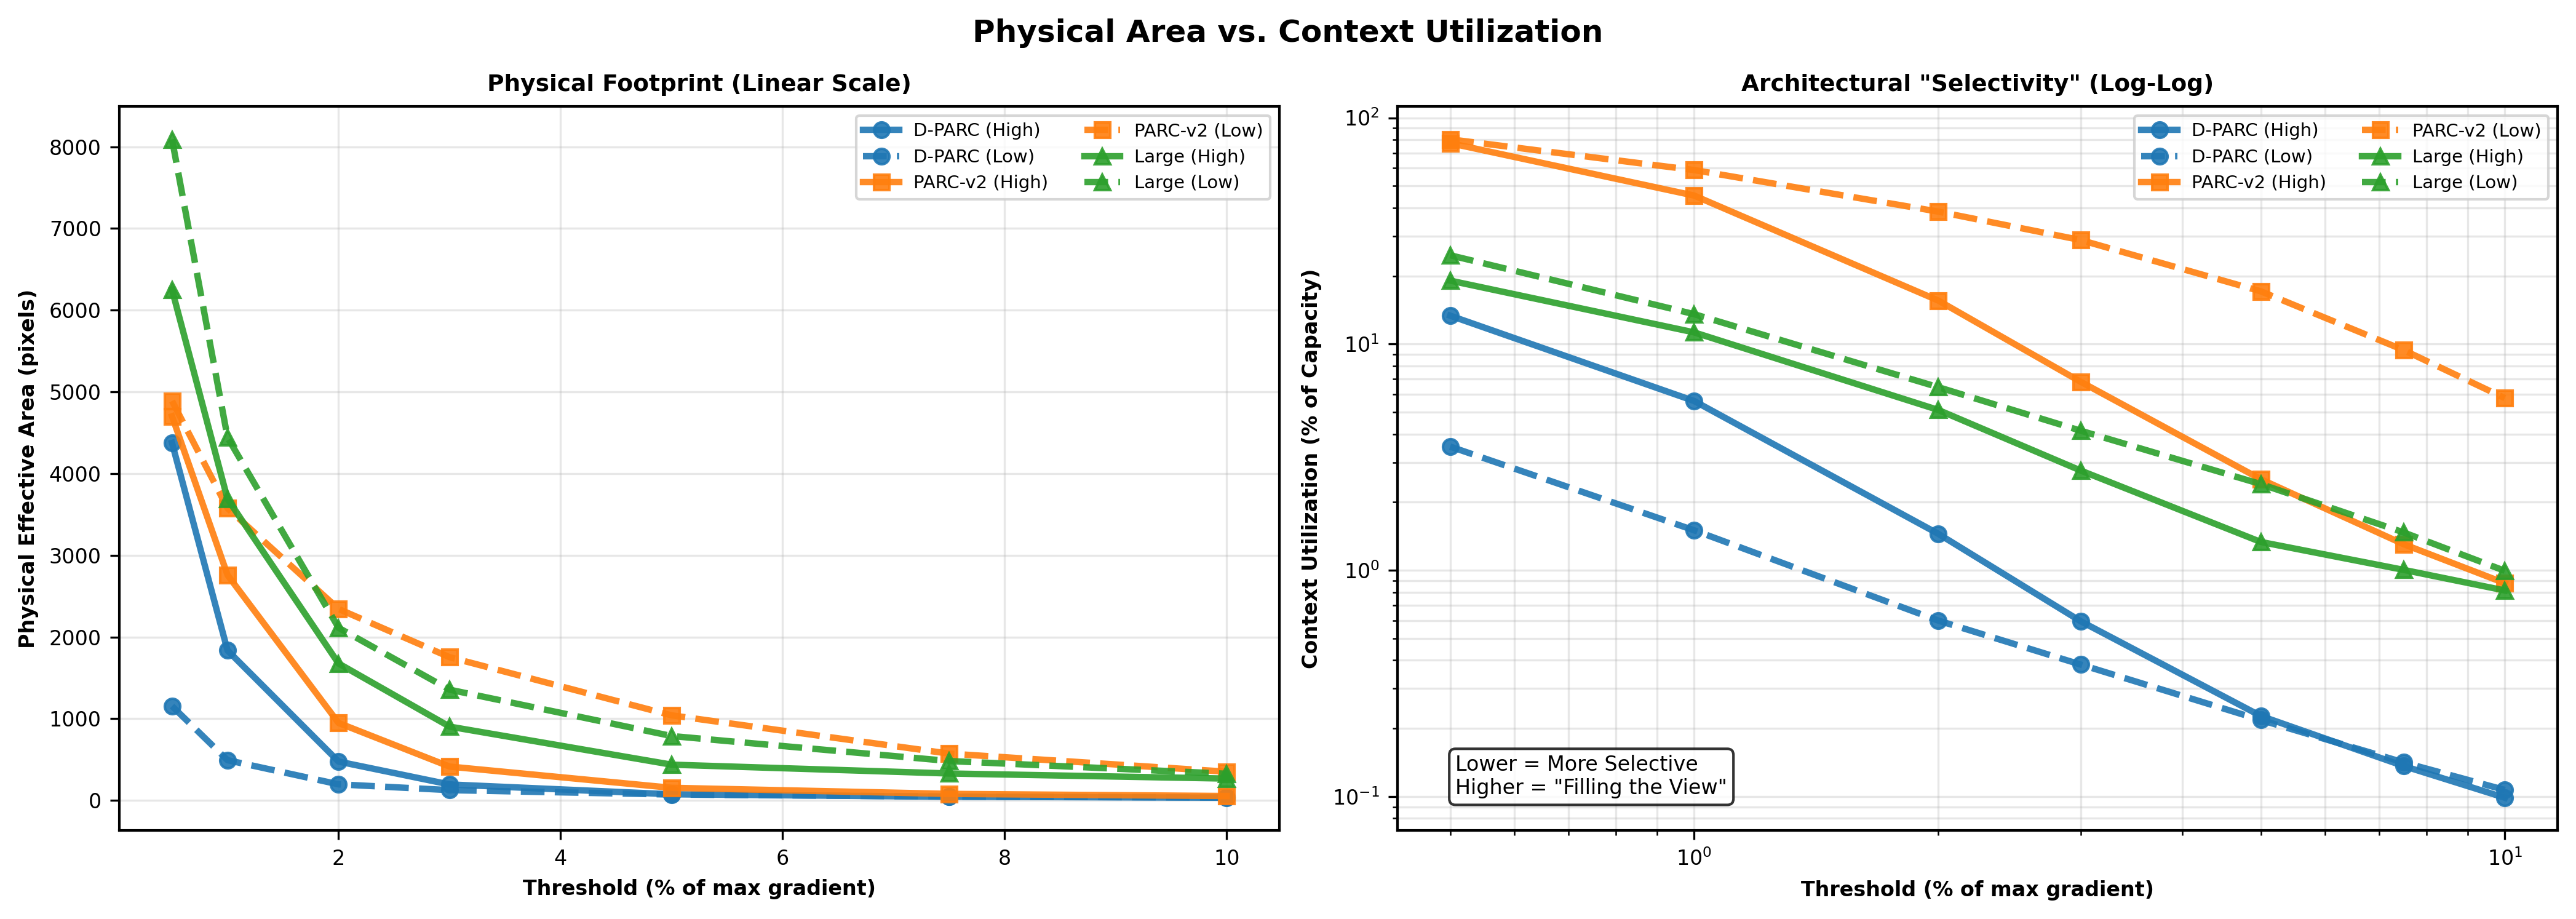


GENERATING VISUALIZATION


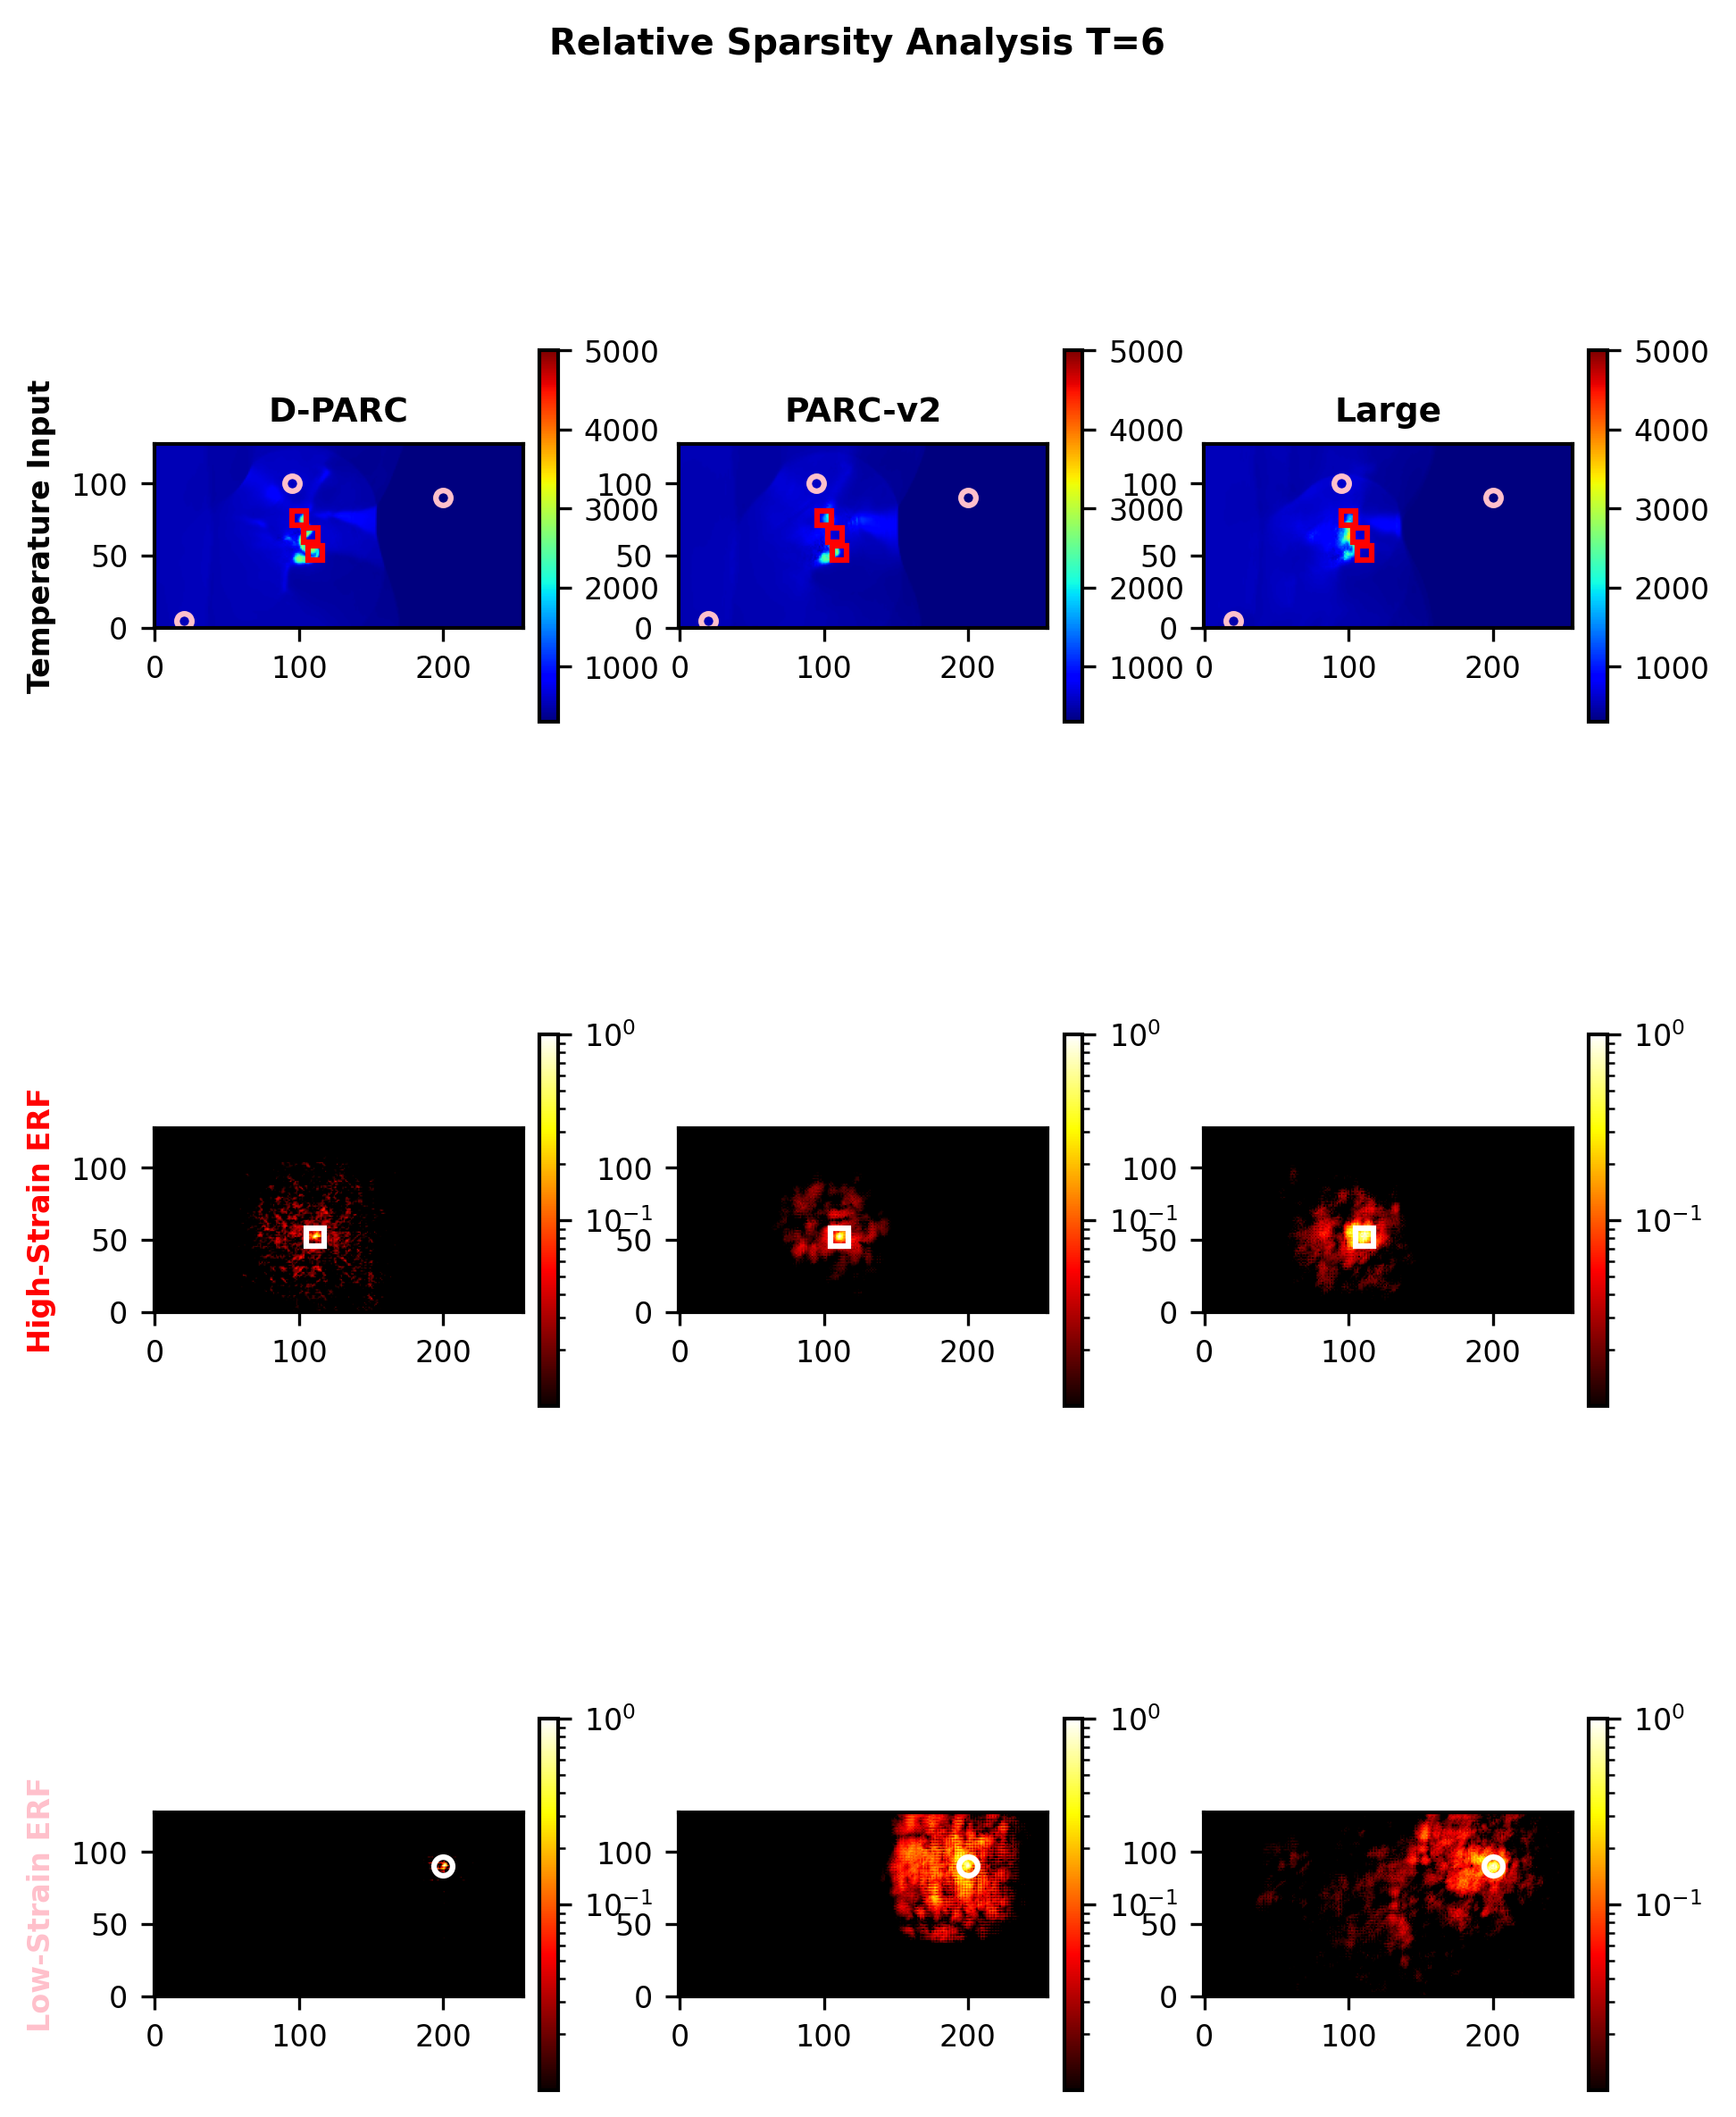


SUMMARY: RELATIVE SPATIAL SPARSITY @ 1% THRESHOLD
High Strain Regions (Relative Sparsity):
  D-PARC:  94.40% (Denominator: Global)
  PARC-v2: 54.67% (Denominator: TRF=6084)
  Large:   88.74% (Denominator: Global)


In [13]:
################################################################################
# CELL: Multi-Point ERF Analysis - Context Utilization & Sparsity (V4.3 - FINAL)
################################################################################
"""
Multi-Point ERF Analysis for Energetic Materials

V4.3 Features:
1. Relative Spatial Sparsity: Metrics calculated against specific denominators.
   - PARCv2: 6,084 px (Theoretical Receptive Field)
   - D-PARC/Large: HxW (Global Domain)
2. Context Utilization Plot: 
   - Left: Physical Footprint (Linear) -> "How big is the spot?"
   - Right: Context Utilization (Log-Log) -> "How much of its brain is it using?"
3. Visualization: Representative points shown on screen.
"""

import gc
import warnings
import os
from pathlib import Path
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import csv
import torch

print("\n" + "="*80)
print("MULTI-POINT ERF ANALYSIS - CONTEXT UTILIZATION & SPARSITY (V4.3)")
print("="*80)

# =============================================================================
# Configuration
# =============================================================================

ANALYZE_TIMESTEP = 6
CHANNEL_TO_VISUALIZE = 0  # Temperature
VMIN_VIZ = 300
VMAX_VIZ = 5000

# Define analysis points
HIGH_STRAIN_POINTS = [
    (52, 111),   # Point 1 - High strain
    (76, 100),   # Point 2 - High strain  
    (64, 108),   # Point 3 - High strain
]

LOW_STRAIN_POINTS = [
    (90, 200),    # Point 1 - Low strain
    (100, 95),   # Point 2 - Low strain
    (5, 20),    # Point 3 - Low strain
]

# Thresholds to test
TEST_THRESHOLDS = [0.005, 0.01, 0.02, 0.03, 0.05, 0.075, 0.10]

# Output configuration
OUTPUT_DIR = Path("erf_multipoint_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- DENOMINATOR CONFIGURATION ---
PARCV2_TRF_AREA = 6084  # User supplied fixed value

print(f"\n✓ Configuration:")
print(f"  Timestep: T={ANALYZE_TIMESTEP}")
print(f"  PARCv2 Theoretical Receptive Field Area: {PARCV2_TRF_AREA} pixels")

# =============================================================================
# Helper Functions
# =============================================================================

def set_plot_style():
    """Publication-ready style."""
    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'font.size': 8,
        'axes.labelsize': 8,
        'axes.titlesize': 9,
        'legend.fontsize': 7,
        'figure.dpi': 300,
        'axes.linewidth': 1.0,
    })

def denormalize_channel(normalized_data, channel_idx, norm_params):
    """Denormalize a single channel back to physical units."""
    channel_min = norm_params["channel_min"][channel_idx]
    channel_max = norm_params["channel_max"][channel_idx]
    return normalized_data * (channel_max - channel_min) + channel_min

def compute_unet_erf_aggregate(model, input_state, output_point):
    """Compute UNet-only ERF aggregated across all output features."""
    unet = None
    possible_names = ['feature_extraction', 'feature_extractor', 'unet', 'network', 
                      'fe_network', 'encoder', 'feature_net']
    
    for attr_name in possible_names:
        if hasattr(model.differentiator, attr_name):
            unet = getattr(model.differentiator, attr_name)
            break
    
    if unet is None:
        raise AttributeError("Could not find UNet in model.differentiator")
    
    unet.eval()
    input_grad = input_state.detach().requires_grad_(True)
    
    with torch.set_grad_enabled(True):
        features = unet(input_grad)
        output_value = features[0, :, output_point[0], output_point[1]].sum()
    
    if input_grad.grad is not None:
        input_grad.grad.zero_()
    output_value.backward()
    
    if input_grad.grad is None:
        raise RuntimeError("Gradients are None!")
    
    gradients = input_grad.grad[0].detach().cpu().numpy()
    erf_map = np.abs(gradients)
    
    del input_grad, features, output_value
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    
    return erf_map

# =============================================================================
# Core ERF Computation - Relative Sparsity
# =============================================================================

def compute_relative_sparsity_metrics(erf_map, thresholds, valid_domain_area):
    """
    Compute Relative Spatial Sparsity.
    Formula: Sparsity = (1 - Activated_Area / Valid_Domain_Area) * 100
    """
    erf_agg = np.sum(erf_map, axis=0)
    erf_norm = erf_agg / (erf_agg.max() + 1e-10)
    
    results = {}
    for thresh in thresholds:
        erf_binary = (erf_norm > thresh).astype(float)
        activated = np.sum(erf_binary)
        
        # Relative Sparsity Formula
        sparsity = max(0, (1 - activated / valid_domain_area) * 100)
        
        results[thresh] = {
            'area': activated,
            'sparsity': sparsity
        }
    
    return results

def analyze_multiple_points(model, input_state, points, thresholds, point_type, valid_domain_area):
    """
    Analyze ERF at multiple points using specific domain area denominator.
    """
    print(f"\n  Analyzing {len(points)} {point_type} points...")
    print(f"  -> Using Denominator (Valid Domain Area): {valid_domain_area} pixels")
    
    results = {}
    
    for idx, point in enumerate(points):
        erf_map = compute_unet_erf_aggregate(model, input_state.clone(), point)
        metrics = compute_relative_sparsity_metrics(erf_map, thresholds, valid_domain_area)
        
        results[f'point_{idx+1}'] = {
            'coords': point,
            'erf_map': erf_map,
            'metrics': metrics
        }
    
    # Compute averages
    avg_metrics = {}
    for thresh in thresholds:
        areas = [results[f'point_{i+1}']['metrics'][thresh]['area'] 
                 for i in range(len(points))]
        sparsities = [results[f'point_{i+1}']['metrics'][thresh]['sparsity'] 
                      for i in range(len(points))]
        
        avg_metrics[thresh] = {
            'area_mean': np.mean(areas),
            'area_std': np.std(areas),
            'sparsity_mean': np.mean(sparsities),
            'sparsity_std': np.std(sparsities)
        }
    
    results['average'] = avg_metrics
    return results

# =============================================================================
# Analyze All Models
# =============================================================================

print("\n" + "="*80)
print("COMPUTING ERF WITH MODEL-SPECIFIC DENOMINATORS")
print("="*80)

# Get Domain Size (H x W)
H, W = state_at_t_deform.shape[-2], state_at_t_deform.shape[-1]
GLOBAL_DOMAIN_AREA = H * W
print(f"Global Domain Size (HxW): {H}x{W} = {GLOBAL_DOMAIN_AREA} pixels")

# Calculate Specific Denominators
PARCV2_DENOMINATOR = min(PARCV2_TRF_AREA, GLOBAL_DOMAIN_AREA)
DPARC_DENOMINATOR = GLOBAL_DOMAIN_AREA

all_results = {
    'D-PARC': {'high_strain': None, 'low_strain': None},
    'PARC-v2': {'high_strain': None, 'low_strain': None},
    'Large': {'high_strain': None, 'low_strain': None}
}

# D-PARC (Denominator: Global)
print(f"\n[1/3] D-PARC (Deformable)")
all_results['D-PARC']['high_strain'] = analyze_multiple_points(
    model_deform, state_at_t_deform, HIGH_STRAIN_POINTS, TEST_THRESHOLDS, 'high_strain',
    valid_domain_area=DPARC_DENOMINATOR
)
all_results['D-PARC']['low_strain'] = analyze_multiple_points(
    model_deform, state_at_t_deform, LOW_STRAIN_POINTS, TEST_THRESHOLDS, 'low_strain',
    valid_domain_area=DPARC_DENOMINATOR
)

# PARC-v2 (Denominator: Fixed TRF)
print(f"\n[2/3] PARC-v2 (Standard)")
print(f"-> Applying architectural constraint: {PARCV2_DENOMINATOR} pixels")
all_results['PARC-v2']['high_strain'] = analyze_multiple_points(
    model_standard, state_at_t_standard, HIGH_STRAIN_POINTS, TEST_THRESHOLDS, 'high_strain',
    valid_domain_area=PARCV2_DENOMINATOR
)
all_results['PARC-v2']['low_strain'] = analyze_multiple_points(
    model_standard, state_at_t_standard, LOW_STRAIN_POINTS, TEST_THRESHOLDS, 'low_strain',
    valid_domain_area=PARCV2_DENOMINATOR
)

# Large (Denominator: Global)
print(f"\n[3/3] Large (Global Capacity)")
all_results['Large']['high_strain'] = analyze_multiple_points(
    model_large, state_at_t_large, HIGH_STRAIN_POINTS, TEST_THRESHOLDS, 'high_strain',
    valid_domain_area=DPARC_DENOMINATOR
)
all_results['Large']['low_strain'] = analyze_multiple_points(
    model_large, state_at_t_large, LOW_STRAIN_POINTS, TEST_THRESHOLDS, 'low_strain',
    valid_domain_area=DPARC_DENOMINATOR
)

print("\n✓ ERF computation complete!")

# =============================================================================
# Export and Summary
# =============================================================================

print("\n" + "="*80)
print("EXPORTING RELATIVE SPARSITY METRICS")
print("="*80)

def export_and_print(filename, point_type, title):
    csv_path = OUTPUT_DIR / filename
    print(f"\n📊 {title} (Relative Sparsity)")
    print(f"{'Threshold':<12} {'D-PARC':>30} {'PARC-v2':>30} {'Large':>30}")
    print(f"{'(% of max)':<12} {'Area':>15} {'Rel. Sparsity':>15} {'Area':>15} {'Rel. Sparsity':>15} {'Area':>15} {'Rel. Sparsity':>15}")
    print("-" * 115)

    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Threshold (%)', 
                        'D-PARC Area', 'D-PARC Rel Sparsity',
                        'PARC-v2 Area', 'PARC-v2 Rel Sparsity',
                        'Large Area', 'Large Rel Sparsity'])
        
        for thresh in TEST_THRESHOLDS:
            row = [f"{thresh*100:.1f}"]
            print_data = [f"{thresh*100:>6.1f}%      "]
            
            for model in ['D-PARC', 'PARC-v2', 'Large']:
                avg = all_results[model][point_type]['average'][thresh]
                row.append(f"{avg['area_mean']:.1f}±{avg['area_std']:.1f}")
                row.append(f"{avg['sparsity_mean']:.2f}±{avg['sparsity_std']:.2f}")
                
                print_data.append(f"{avg['area_mean']:>7.0f}±{avg['area_std']:<6.0f}")
                print_data.append(f"{avg['sparsity_mean']:>6.2f}±{avg['sparsity_std']:<6.2f}")
            
            writer.writerow(row)
            print(''.join(print_data))
    print(f"\n✓ Saved to: {csv_path}")

export_and_print(f'erf_high_strain_relative_T{ANALYZE_TIMESTEP}.csv', 'high_strain', 'HIGH-STRAIN REGION')
export_and_print(f'erf_low_strain_relative_T{ANALYZE_TIMESTEP}.csv', 'low_strain', 'LOW-STRAIN REGION')

# =============================================================================
# Threshold Sensitivity Plots (Context Utilization)
# =============================================================================

print("\n" + "="*80)
print("GENERATING THRESHOLD SENSITIVITY PLOTS (PHYSICAL VS RELATIVE)")
print("="*80)

def plot_threshold_sensitivity_combined(all_results, thresholds, output_dir, parcv2_denom, dparc_denom):
    """
    Plots Physical Area (Linear) and Context Utilization (Log-Log).
    Context Utilization = (Area / Denominator) * 100
    """
    set_plot_style()
    thresh_percent = np.array(thresholds) * 100
    
    # --- Prepare Data ---
    data = {}
    for model in ['D-PARC', 'PARC-v2', 'Large']:
        data[model] = {
            'high': [all_results[model]['high_strain']['average'][t]['area_mean'] for t in thresholds],
            'low':  [all_results[model]['low_strain']['average'][t]['area_mean'] for t in thresholds]
        }
    
    denoms = {'D-PARC': dparc_denom, 'PARC-v2': parcv2_denom, 'Large': dparc_denom}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    model_styles = {
        'D-PARC': {'color': 'C0', 'marker': 'o'},
        'PARC-v2': {'color': 'C1', 'marker': 's'},
        'Large': {'color': 'C2', 'marker': '^'}
    }
    solid = {'linewidth': 2.5, 'markersize': 6, 'alpha': 0.9, 'linestyle': '-'}
    dashed = {'linewidth': 2.5, 'markersize': 6, 'alpha': 0.9, 'linestyle': '--'}

    # PLOT 1: Physical Reality (Linear Scale)
    ax = axes[0]
    for model in ['D-PARC', 'PARC-v2', 'Large']:
        ax.plot(thresh_percent, data[model]['high'], label=f'{model} (High)', 
                color=model_styles[model]['color'], marker=model_styles[model]['marker'], **solid)
        ax.plot(thresh_percent, data[model]['low'], label=f'{model} (Low)', 
                color=model_styles[model]['color'], marker=model_styles[model]['marker'], **dashed)
    
    ax.set_xlabel('Threshold (% of max gradient)', fontweight='bold')
    ax.set_ylabel('Physical Effective Area (pixels)', fontweight='bold')
    ax.set_title('Physical Footprint (Linear Scale)', fontweight='bold')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

    # PLOT 2: Context Utilization (Log-Log Scale)
    ax = axes[1]
    for model in ['D-PARC', 'PARC-v2', 'Large']:
        util_high = [(area / denoms[model]) * 100 for area in data[model]['high']]
        util_low = [(area / denoms[model]) * 100 for area in data[model]['low']]
        
        ax.loglog(thresh_percent, util_high, label=f'{model} (High)', 
                 color=model_styles[model]['color'], marker=model_styles[model]['marker'], **solid)
        ax.loglog(thresh_percent, util_low, label=f'{model} (Low)', 
                 color=model_styles[model]['color'], marker=model_styles[model]['marker'], **dashed)

    ax.set_xlabel('Threshold (% of max gradient)', fontweight='bold')
    ax.set_ylabel('Context Utilization (% of Capacity)', fontweight='bold')
    ax.set_title('Architectural "Selectivity" (Log-Log)', fontweight='bold')
    ax.text(0.05, 0.05, 'Lower = More Selective\nHigher = "Filling the View"', 
            transform=ax.transAxes, fontsize=8, 
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))
    
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3, which='both')

    plt.suptitle('Physical Area vs. Context Utilization', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_dir / 'erf_metric_comparison.png', dpi=300)
    plt.show()
    plt.close()

plot_threshold_sensitivity_combined(
    all_results, TEST_THRESHOLDS, OUTPUT_DIR, 
    PARCV2_DENOMINATOR, DPARC_DENOMINATOR
)

# =============================================================================
# Visualization: Representative Point
# =============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATION")
print("="*80)

def plot_representative_erf_all_points(
    state_d, state_s, state_l,
    erf_high_d, erf_high_s, erf_high_l, point_high,
    erf_low_d, erf_low_s, erf_low_l, point_low,
    all_high_points, all_low_points,
    norm_params, timestep, vmin, vmax, output_path
):
    set_plot_style()
    channel_idx = 0
    state_d_np = denormalize_channel(state_d[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    state_s_np = denormalize_channel(state_s[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    state_l_np = denormalize_channel(state_l[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    
    def process_erf(erf_map):
        erf_agg = np.sum(erf_map, axis=0)
        erf_norm = erf_agg / (erf_agg.max() + 1e-10)
        return np.where(erf_norm > 0.01, erf_norm, np.nan)
    
    erf_maps = [
        [process_erf(erf_high_d), process_erf(erf_high_s), process_erf(erf_high_l)],
        [process_erf(erf_low_d), process_erf(erf_low_s), process_erf(erf_low_l)]
    ]
    
    all_vals = []
    for row in erf_maps:
        for m in row:
            valid = m[~np.isnan(m)]
            if len(valid) > 0: all_vals.append(valid.min())
    vmin_shared = min(all_vals) if all_vals else 1e-3

    fig = plt.figure(figsize=(7, 9))
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)
    
    for col, (data, title) in enumerate(zip([state_d_np, state_s_np, state_l_np], ['D-PARC', 'PARC-v2', 'Large'])):
        ax = fig.add_subplot(gs[0, col])
        im = ax.imshow(data, cmap='jet', origin='lower', vmin=vmin, vmax=vmax)
        for pt in all_high_points: ax.plot(pt[1], pt[0], 's', mfc='none', mec='red', mew=1.5, ms=4)
        for pt in all_low_points: ax.plot(pt[1], pt[0], 'o', mfc='none', mec='pink', mew=1.5, ms=4)
        ax.set_title(title, fontweight='bold')
        if col==0: ax.set_ylabel('Temperature Input', fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for row_idx, (pt, label, color) in enumerate(zip([point_high, point_low], ['High-Strain', 'Low-Strain'], ['red', 'pink'])):
        for col, data in enumerate(erf_maps[row_idx]):
            ax = fig.add_subplot(gs[row_idx+1, col])
            ax.set_facecolor('black')
            im = ax.imshow(data, cmap='hot', origin='lower', norm=LogNorm(vmin=vmin_shared, vmax=1.0))
            marker = 's' if row_idx == 0 else 'o'
            ax.plot(pt[1], pt[0], marker, ms=5, mfc='none', mec='white', mew=1.5)
            if col==0: ax.set_ylabel(f'{label} ERF', fontweight='bold', color=color)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            
    plt.suptitle(f'Relative Sparsity Analysis T={timestep}', fontweight='bold', y=0.99)
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

plot_representative_erf_all_points(
    state_at_t_deform, state_at_t_standard, state_at_t_large,
    all_results['D-PARC']['high_strain']['point_1']['erf_map'],
    all_results['PARC-v2']['high_strain']['point_1']['erf_map'],
    all_results['Large']['high_strain']['point_1']['erf_map'],
    HIGH_STRAIN_POINTS[0],
    all_results['D-PARC']['low_strain']['point_1']['erf_map'],
    all_results['PARC-v2']['low_strain']['point_1']['erf_map'],
    all_results['Large']['low_strain']['point_1']['erf_map'],
    LOW_STRAIN_POINTS[0],
    HIGH_STRAIN_POINTS, LOW_STRAIN_POINTS,
    norm_params, ANALYZE_TIMESTEP, VMIN_VIZ, VMAX_VIZ,
    OUTPUT_DIR / f'representative_erf_relative_T{ANALYZE_TIMESTEP}.png'
)

print("\n" + "="*80)
print("SUMMARY: RELATIVE SPATIAL SPARSITY @ 1% THRESHOLD")
print("="*80)

t1 = 0.01
h_d = all_results['D-PARC']['high_strain']['average'][t1]
h_s = all_results['PARC-v2']['high_strain']['average'][t1]
h_l = all_results['Large']['high_strain']['average'][t1]

print(f"High Strain Regions (Relative Sparsity):")
print(f"  D-PARC:  {h_d['sparsity_mean']:.2f}% (Denominator: Global)")
print(f"  PARC-v2: {h_s['sparsity_mean']:.2f}% (Denominator: TRF={PARCV2_DENOMINATOR})")
print(f"  Large:   {h_l['sparsity_mean']:.2f}% (Denominator: Global)")


GENERATING COMBINED FIGURE (CONTEXT UTILIZATION LAYOUT)

[Info] Preparing data for combined figure...
  -> Using Global Capacity: 32768 px
  -> Using PARCv2 TRF Capacity: 6084 px
[Info] Building combined figure...

✓ Saved combined figure to: erf_multipoint_analysis/COMBINED_high_low_strain_T6_UTILIZATION.png
✓ Saved combined figure to: erf_multipoint_analysis/COMBINED_high_low_strain_T6_UTILIZATION.pdf


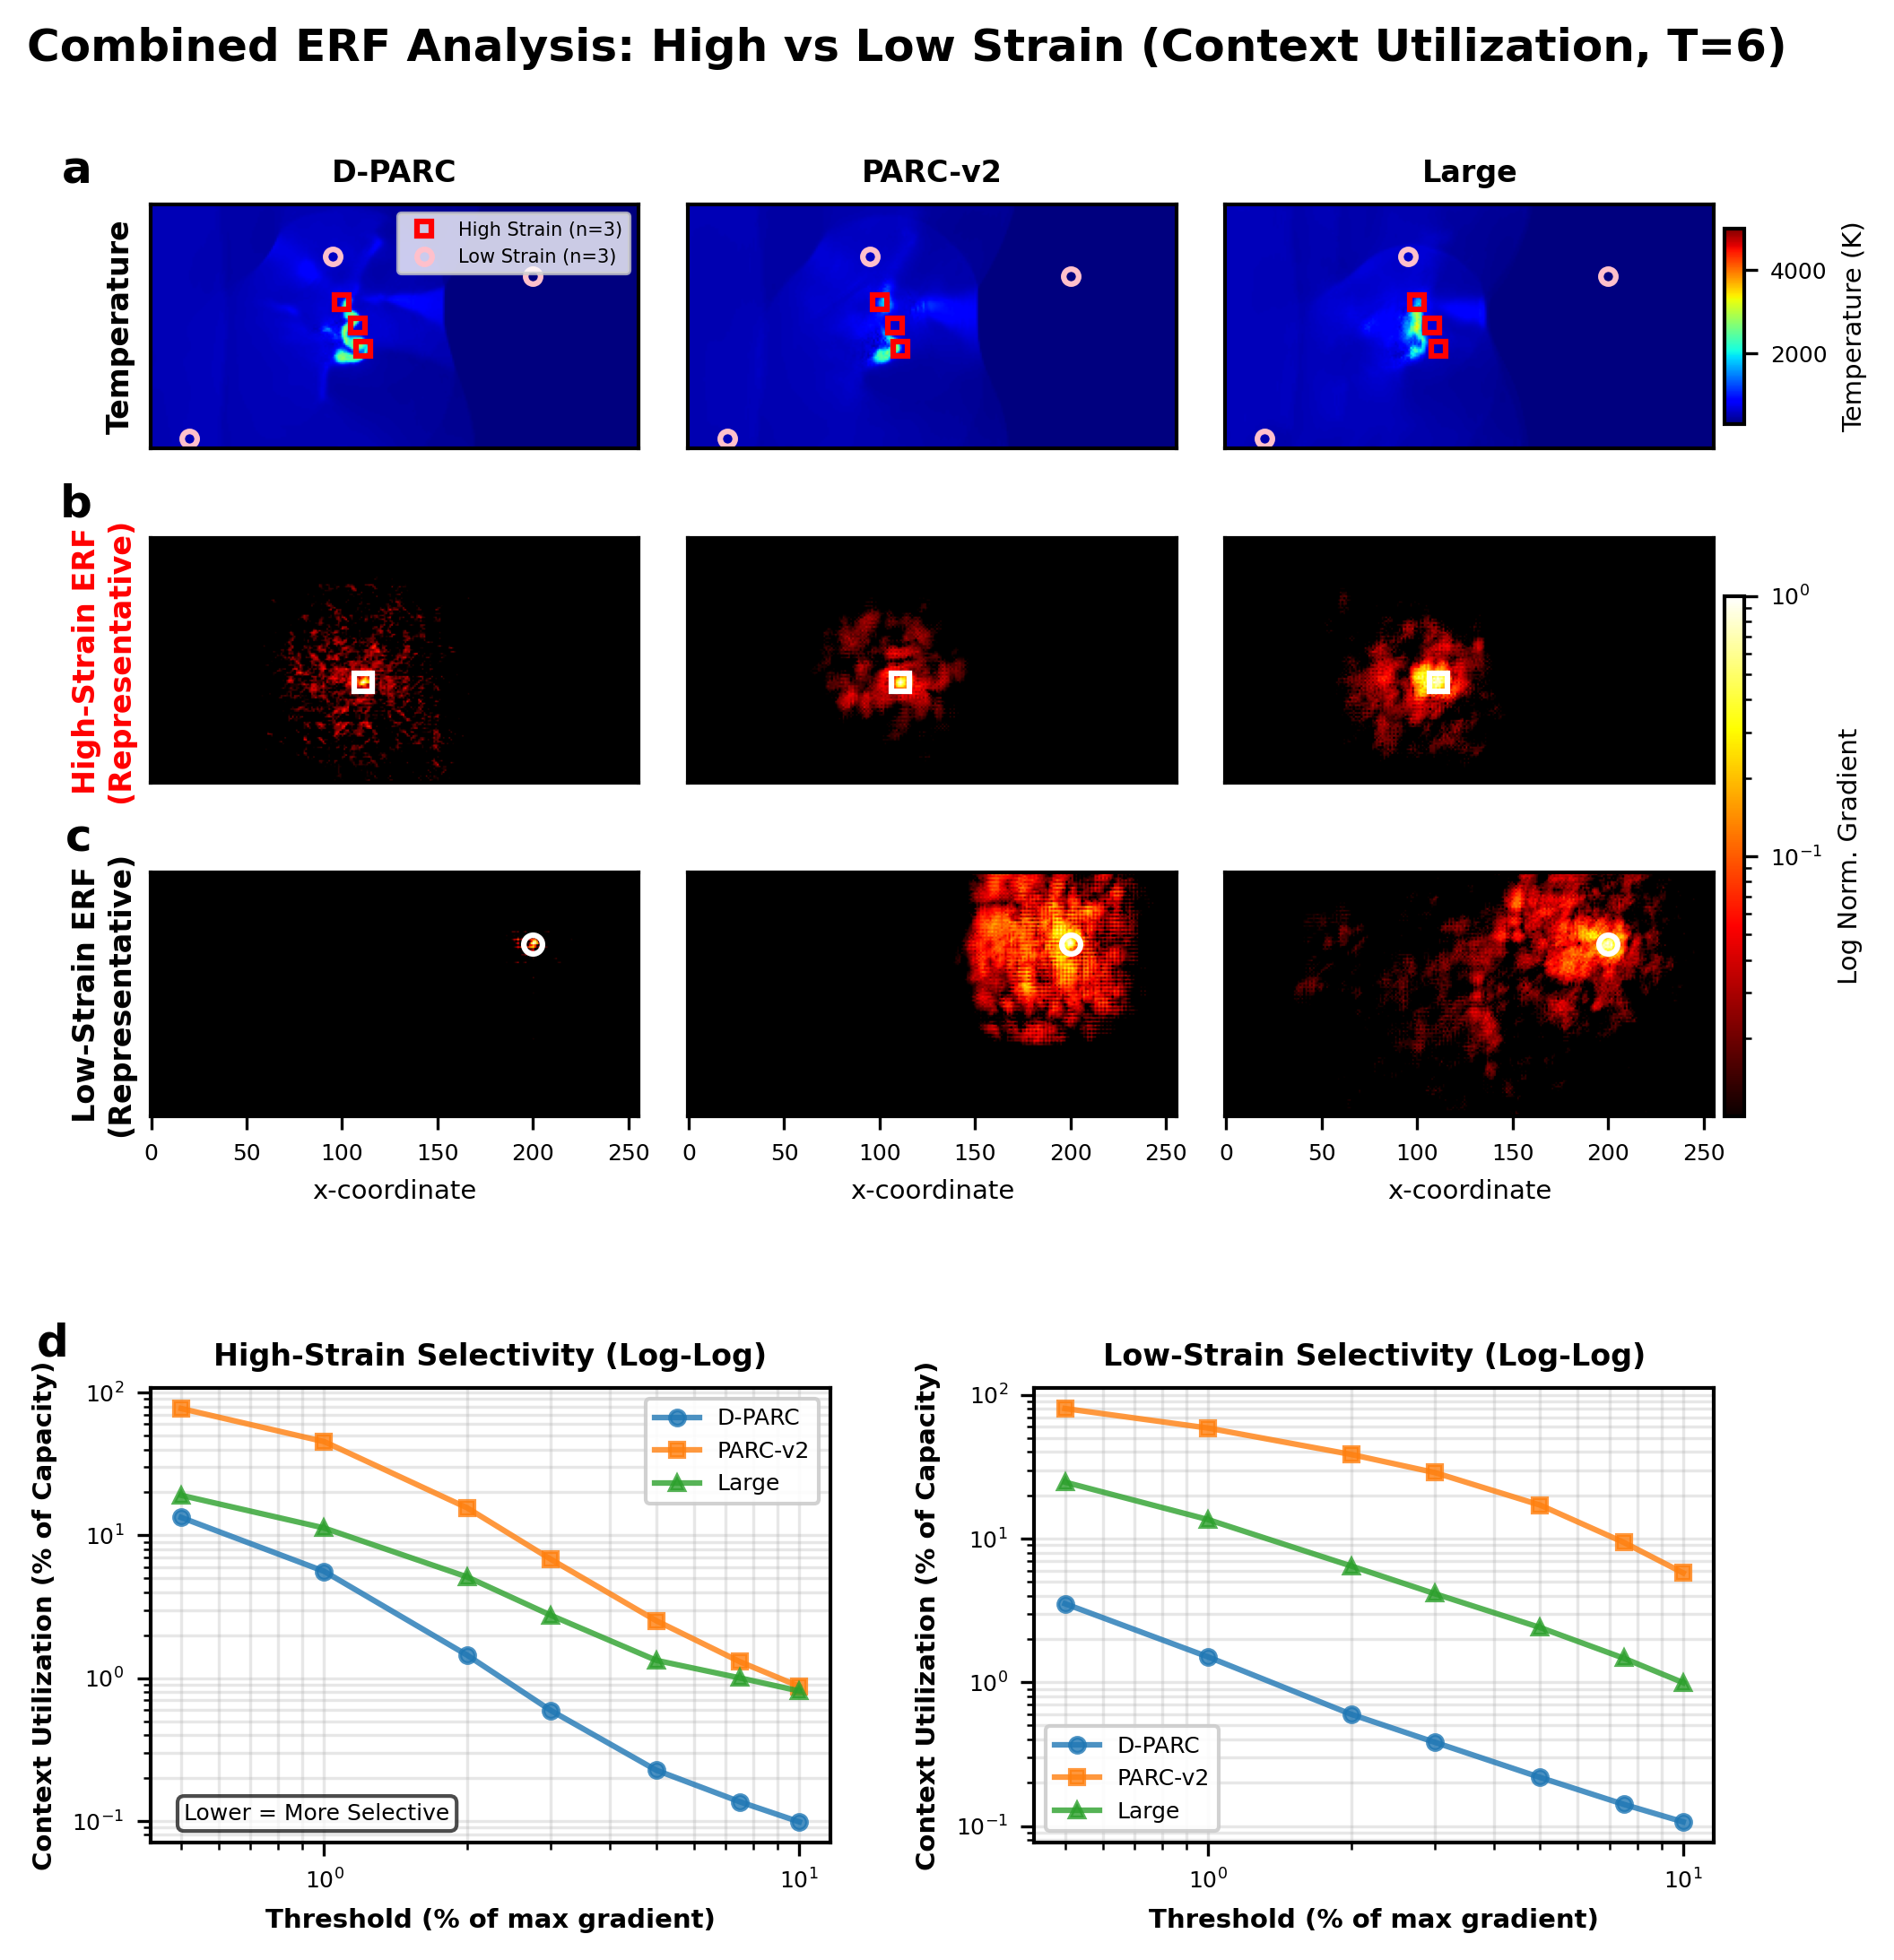


✓ Combined figure generation complete.

GENERATING COMBINED FIGURE (RENAMED: PARCv2 & PARCv2-L)

[Info] Preparing data for combined figure...
  -> Using Global Capacity: 32768 px
  -> Using PARCv2 TRF Capacity: 6084 px
[Info] Building combined figure...

✓ Saved combined figure to: erf_multipoint_analysis/COMBINED_high_low_strain_T6_UTILIZATION.png
✓ Saved combined figure to: erf_multipoint_analysis/COMBINED_high_low_strain_T6_UTILIZATION.pdf


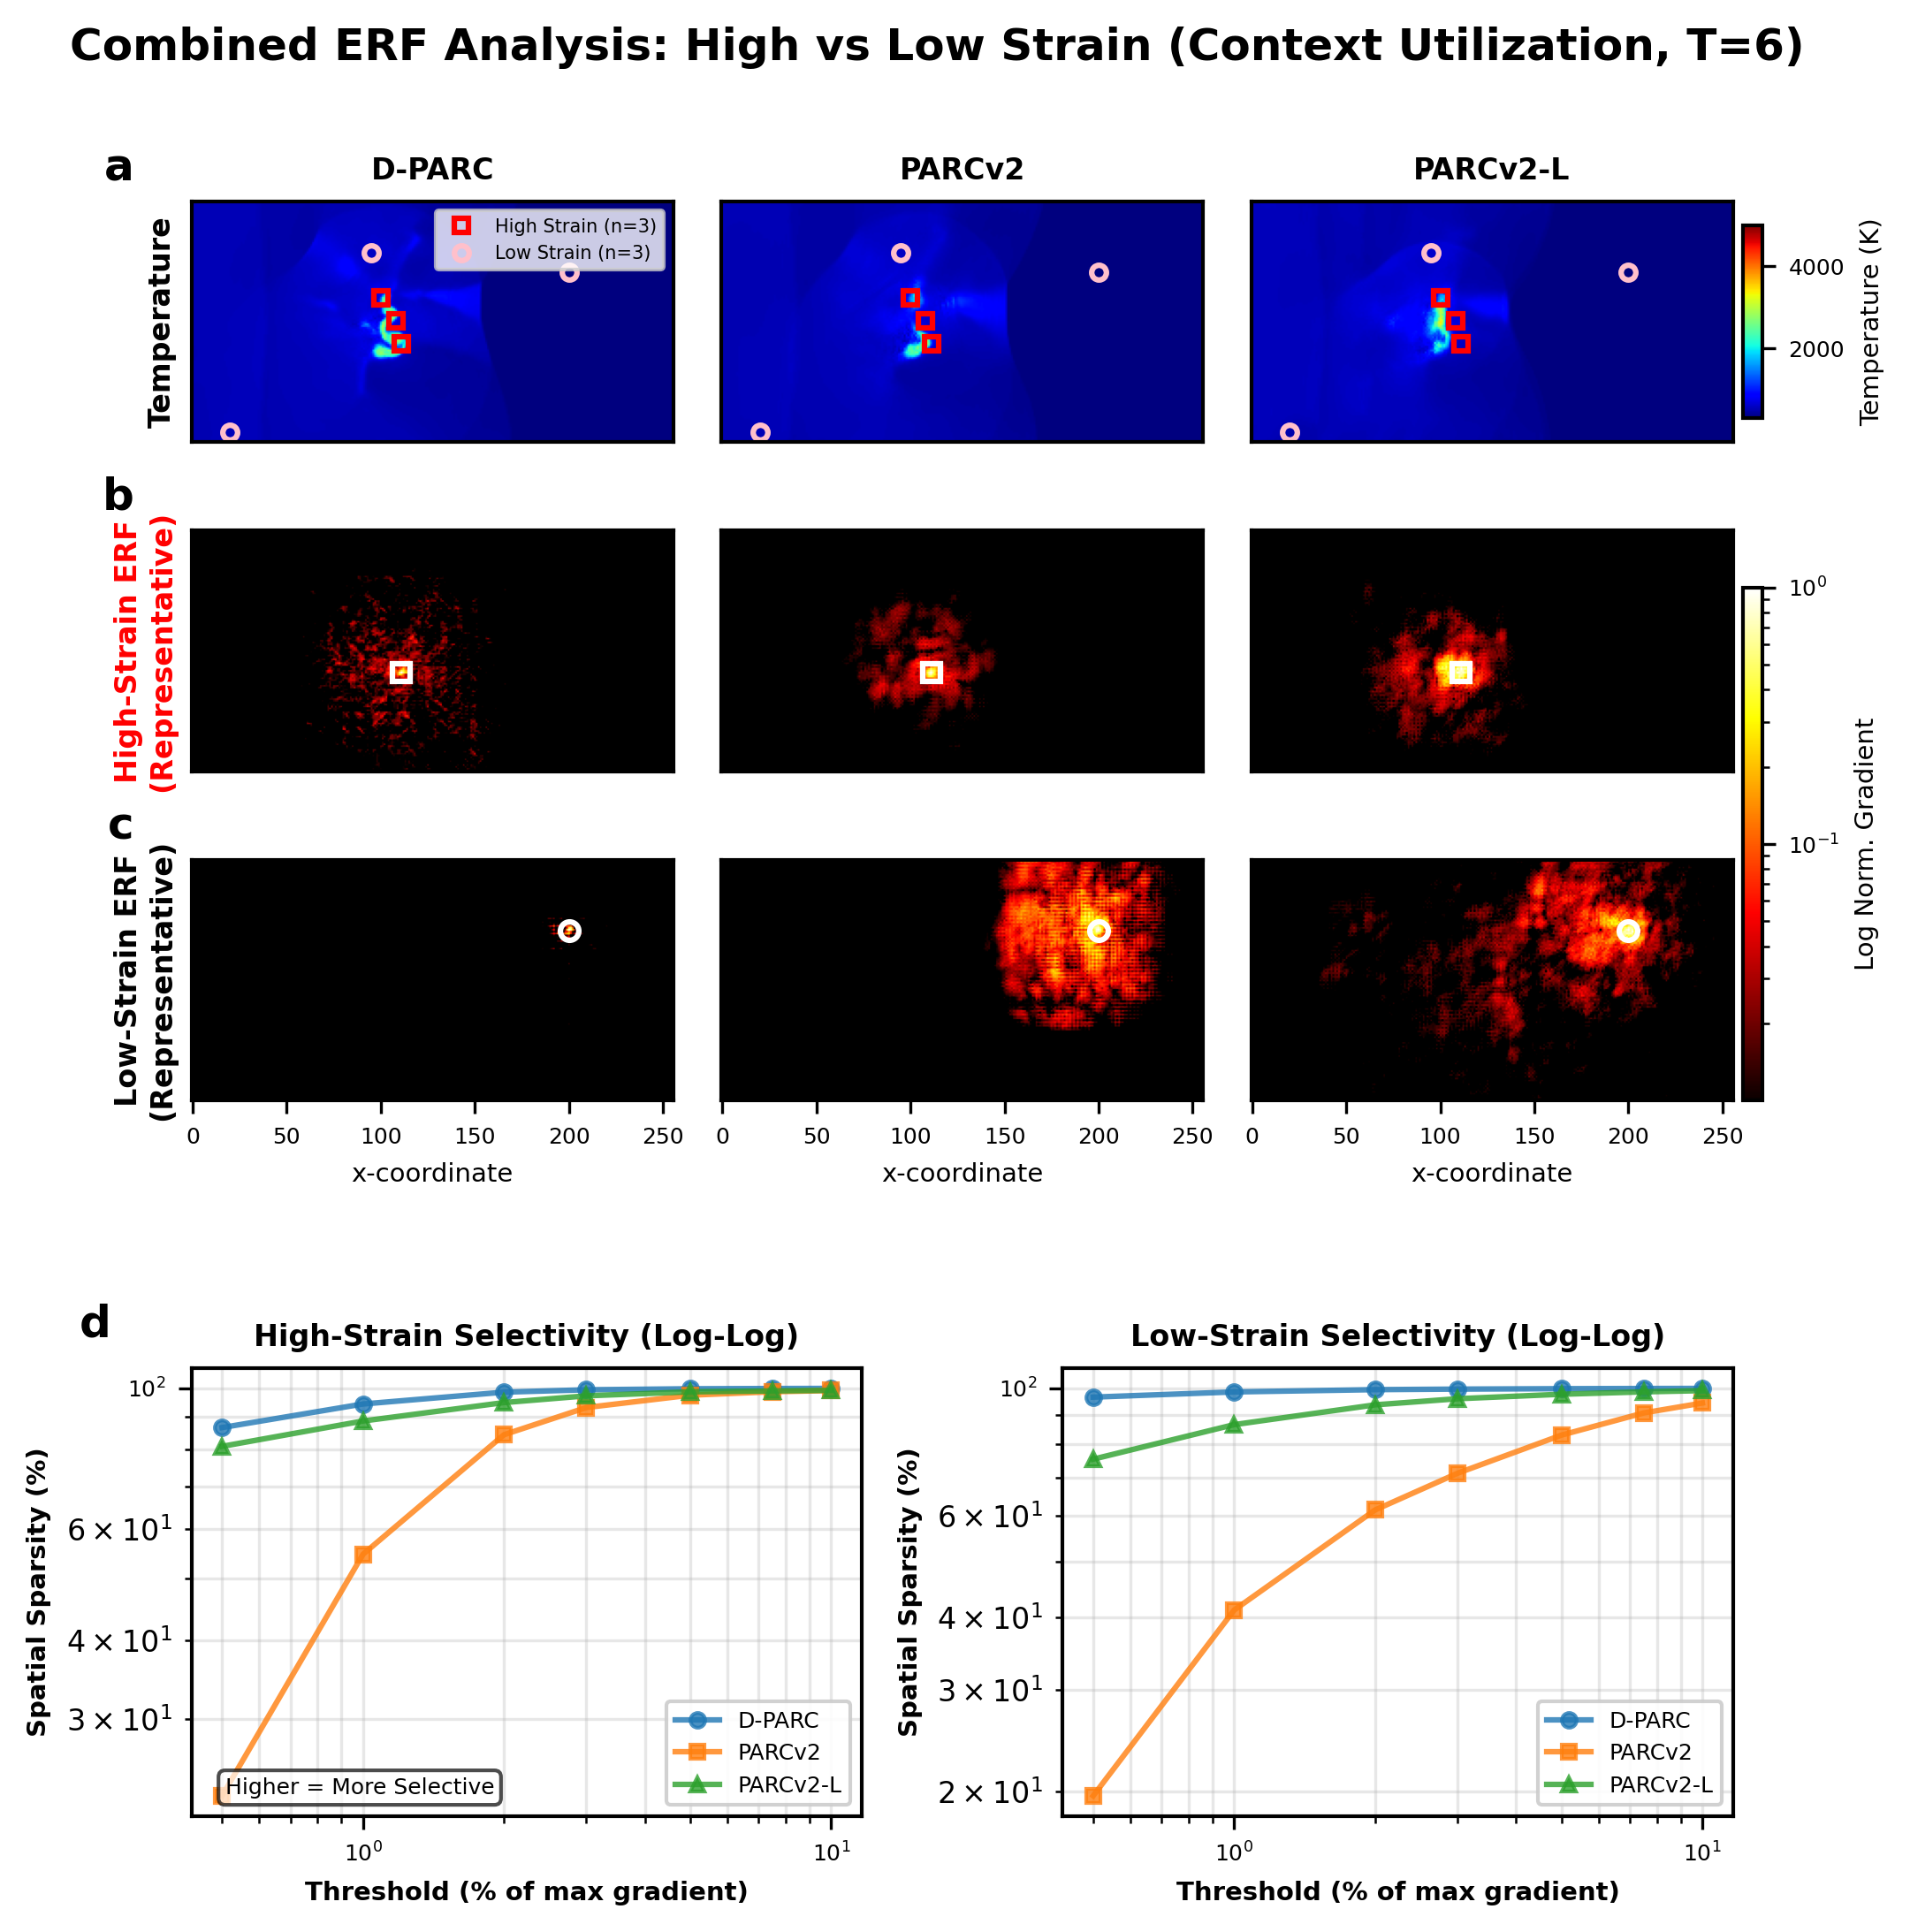


✓ Combined figure generation complete.


In [15]:
################################################################################
# CELL: Combined Publication Figure - High vs Low Strain (Context Utilization)
# UPDATED: Panel (d) now shows RELATIVE CONTEXT UTILIZATION (Log-Log)
################################################################################
"""
Generates a single, combined publication figure from the multi-point
analysis for Energetic Materials (Temperature).

Updates:
- Panel 'd' now plots CONTEXT UTILIZATION: (Area / Capacity) * 100
- PARCv2 Capacity = 6,084 pixels (TRF)
- D-PARC/Large Capacity = HxW (Global)
- Shows architectural efficiency rather than just physical size.
"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import numpy as np
import gc

print("\n" + "="*80)
print("GENERATING COMBINED FIGURE (CONTEXT UTILIZATION LAYOUT)")
print("="*80)

# =============================================================================
# Sub-plotter: Panels (a, b, c) - Temp + ERF Grids (Standard)
# =============================================================================

def plot_panel_a_b_c_temp_erf(
    fig, gs_panel,
    state_d_np, state_s_np, state_l_np,
    erf_high_d_masked, erf_high_s_masked, erf_high_l_masked, point_high,
    erf_low_d_masked, erf_low_s_masked, erf_low_l_masked, point_low,
    all_high_points, all_low_points,
    vmin, vmax, vmin_shared
):
    """
    Draws the 3x3 grid and labels them as panels a, b, and c.
    """
    # Note: hspace=-0.52 preserved for Energetic Materials aspect ratio
    gs_sub = gridspec.GridSpecFromSubplotSpec(3, 3, subplot_spec=gs_panel,
                                                hspace=-0.52, wspace=0.1)

    high_marker_props = {'marker': 's', 'markersize': 4, 'markerfacecolor': 'none',
                         'markeredgecolor': 'red', 'markeredgewidth': 1.5, 'linestyle': 'none'}
    low_marker_props = {'marker': 'o', 'markersize': 4, 'markerfacecolor': 'none',
                        'markeredgecolor': 'pink', 'markeredgewidth': 1.5, 'linestyle': 'none'}

    temp_axes = []
    erf_axes = []

    # --- Panel (a) References ---
    ax_a_ref, ax_b_ref, ax_c_ref = None, None, None

    # --- Row 0: Panel (a) - Temperature ---
    for col, (temp_data, title) in enumerate([
        (state_d_np, 'D-PARC'),
        (state_s_np, 'PARC-v2'),
        (state_l_np, 'Large')
    ]):
        ax = fig.add_subplot(gs_sub[0, col])
        if col == 0: ax_a_ref = ax
        im = ax.imshow(temp_data, cmap='jet', origin='lower', vmin=vmin, vmax=vmax)
        temp_axes.append(ax)

        for pt in all_high_points: ax.plot(pt[1], pt[0], **high_marker_props)
        for pt in all_low_points: ax.plot(pt[1], pt[0], **low_marker_props)

        ax.set_title(title, fontweight='bold', fontsize=8)

        if col == 0:
            ax.set_ylabel('Temperature', fontweight='bold', fontsize=8)
            legend_elements = [
                Line2D([0], [0], **high_marker_props, label=f'High Strain (n={len(all_high_points)})'),
                Line2D([0], [0], **low_marker_props, label=f'Low Strain (n={len(all_low_points)})')
            ]
            ax.legend(handles=legend_elements, fontsize=5, loc='upper right')

        ax.set_xticks([])
        ax.set_yticks([])

    # Add single colorbar for Temperature row
    pos_last_ax = temp_axes[-1].get_position()
    pos_first_ax = temp_axes[0].get_position()
    cbar_ax_temp = fig.add_axes([
        pos_last_ax.x1 + 0.005,
        pos_first_ax.y0 + pos_first_ax.height * 0.1,
        0.01,
        pos_first_ax.height * 0.8
    ])
    fig.colorbar(im, cax=cbar_ax_temp, label='Temperature (K)')
    cbar_ax_temp.yaxis.label.set_fontsize(7)
    cbar_ax_temp.tick_params(labelsize=6)

    # --- Row 1: Panel (b) - High-Strain ERF ---
    for col, (erf_data, title) in enumerate([
        (erf_high_d_masked, 'D-PARC'),
        (erf_high_s_masked, 'PARC-v2'),
        (erf_high_l_masked, 'Large')
    ]):
        ax = fig.add_subplot(gs_sub[1, col])
        if col == 0: ax_b_ref = ax
        ax.set_facecolor('black')
        im_erf = ax.imshow(erf_data, cmap='hot', origin='lower',
                           norm=LogNorm(vmin=vmin_shared, vmax=1.0))
        erf_axes.append(ax)
        ax.plot(point_high[1], point_high[0], 's', markersize=5,
                markerfacecolor='none', markeredgecolor='white', markeredgewidth=1.5)
        if col == 0:
            ax.set_ylabel('High-Strain ERF\n(Representative)', fontweight='bold', color='red', fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

    # --- Row 2: Panel (c) - Low-Strain ERF ---
    for col, (erf_data, title) in enumerate([
        (erf_low_d_masked, 'D-PARC'),
        (erf_low_s_masked, 'PARC-v2'),
        (erf_low_l_masked, 'Large')
    ]):
        ax = fig.add_subplot(gs_sub[2, col])
        if col == 0: ax_c_ref = ax
        ax.set_facecolor('black')
        im_erf = ax.imshow(erf_data, cmap='hot', origin='lower',
                           norm=LogNorm(vmin=vmin_shared, vmax=1.0))
        erf_axes.append(ax)
        ax.plot(point_low[1], point_low[0], 'o', markersize=5,
                markerfacecolor='none', markeredgecolor='white', markeredgewidth=1.5)
        ax.set_xlabel('x-coordinate', fontsize=7)
        if col == 0:
            ax.set_ylabel('Low-Strain ERF\n(Representative)', fontweight='bold', color='black', fontsize=8)

        ax.tick_params(axis='x', labelsize=6)
        ax.set_yticks([])

    # Add single colorbar for ERF rows (b and c)
    pos_last_ax_low = erf_axes[-1].get_position()
    pos_first_ax_high = erf_axes[0].get_position()
    cbar_ax_erf = fig.add_axes([
        pos_last_ax_low.x1 + 0.005,
        pos_last_ax_low.y0,
        0.01,
        (pos_first_ax_high.y1 - pos_last_ax_low.y0) * 0.9
    ])
    fig.colorbar(im_erf, cax=cbar_ax_erf, label='Log Norm. Gradient')
    cbar_ax_erf.yaxis.label.set_fontsize(7)
    cbar_ax_erf.tick_params(labelsize=6)

    # --- Add Panel Labels (a, b, c) ---
    label_props = {'fontsize': 12, 'fontweight': 'bold', 'va': 'bottom', 'ha': 'right'}
    ax_a_ref.text(-0.12, 1.05, 'a', transform=ax_a_ref.transAxes, **label_props)
    ax_b_ref.text(-0.12, 1.05, 'b', transform=ax_b_ref.transAxes, **label_props)
    ax_c_ref.text(-0.12, 1.05, 'c', transform=ax_c_ref.transAxes, **label_props)

# =============================================================================
# Sub-plotter: Panel (d) - Context Utilization (LOG-LOG)
# =============================================================================

def plot_panel_d_utilization(fig, gs_panel, high_areas, low_areas, thresholds, 
                             parcv2_denom, dparc_denom):
    """
    Draws the 1x2 grid for Context Utilization as Panel (d).
    Calculates (Area / Capacity) * 100 for each model.
    """
    gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_panel,
                                                wspace=0.3)

    thresh_percent = np.array(thresholds) * 100
    line_props = {'linewidth': 1.5, 'markersize': 4, 'alpha': 0.8}
    
    # Map models to their denominators
    denoms = {'D-PARC': dparc_denom, 'PARC-v2': parcv2_denom, 'Large': dparc_denom}

    # Helper to transform Area -> Utilization %
    def get_util(model_name, area_list):
        return [(a / denoms[model_name]) * 100 for a in area_list]

    # ========== HIGH-STRAIN: Utilization ==========
    ax = fig.add_subplot(gs_sub[0, 0])
    
    # Add Panel (d) Label
    ax.text(-0.12, 1.05, 'd', transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='bottom', ha='right')

    for model, marker in [('D-PARC', 'o-'), ('PARC-v2', 's-'), ('Large', '^-')]:
        y_vals = get_util(model, high_areas[model])
        ax.loglog(thresh_percent, y_vals, marker, label=model, **line_props)

    ax.set_xlabel('Threshold (% of max gradient)', fontweight='bold', fontsize=7)
    ax.set_ylabel('Context Utilization (% of Capacity)', fontweight='bold', fontsize=7)
    ax.set_title('High-Strain Selectivity (Log-Log)', fontweight='bold', fontsize=8)
    ax.legend(framealpha=0.9, fontsize=6)
    ax.grid(True, alpha=0.3, which='both')
    ax.tick_params(axis='both', which='major', labelsize=6)
    
    # Annotation
    ax.text(0.05, 0.05, 'Lower = More Selective', transform=ax.transAxes, 
            fontsize=6, bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))

    # ========== LOW-STRAIN: Utilization ==========
    ax = fig.add_subplot(gs_sub[0, 1])
    
    for model, marker in [('D-PARC', 'o-'), ('PARC-v2', 's-'), ('Large', '^-')]:
        y_vals = get_util(model, low_areas[model])
        ax.loglog(thresh_percent, y_vals, marker, label=model, **line_props)

    ax.set_xlabel('Threshold (% of max gradient)', fontweight='bold', fontsize=7)
    ax.set_ylabel('Context Utilization (% of Capacity)', fontweight='bold', fontsize=7)
    ax.set_title('Low-Strain Selectivity (Log-Log)', fontweight='bold', fontsize=8)
    ax.legend(framealpha=0.9, fontsize=6)
    ax.grid(True, alpha=0.3, which='both')
    ax.tick_params(axis='both', which='major', labelsize=6)

# =============================================================================
# Main Orchestrator Function
# =============================================================================

def plot_combined_high_low_strain_figure(
    all_results,
    state_d, state_s, state_l,
    norm_params,
    all_high_points, all_low_points,
    thresholds,
    timestep, vmin, vmax,
    output_dir
):
    """
    Main function to generate the combined multi-panel figure.
    """
    print("\n[Info] Preparing data for combined figure...")
    set_plot_style()

    # --- 0. Define Denominators ---
    # Global Domain (HxW) from input state shape
    H, W = state_d.shape[-2], state_d.shape[-1]
    GLOBAL_AREA = H * W
    TRF_AREA = 6084 # Fixed PARCv2 TRF
    
    print(f"  -> Using Global Capacity: {GLOBAL_AREA} px")
    print(f"  -> Using PARCv2 TRF Capacity: {TRF_AREA} px")

    # --- 1. Data Prep for Panel (a) ---
    channel_idx = 0 
    state_d_np = denormalize_channel(state_d[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    state_s_np = denormalize_channel(state_s[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    state_l_np = denormalize_channel(state_l[0, channel_idx].cpu().numpy(), channel_idx, norm_params)

    # Use Point 1 (Index 0) for representative visual
    erf_high_d = all_results['D-PARC']['high_strain']['point_1']['erf_map']
    erf_high_s = all_results['PARC-v2']['high_strain']['point_1']['erf_map']
    erf_high_l = all_results['Large']['high_strain']['point_1']['erf_map']
    point_high = all_high_points[0]

    erf_low_d = all_results['D-PARC']['low_strain']['point_1']['erf_map']
    erf_low_s = all_results['PARC-v2']['low_strain']['point_1']['erf_map']
    erf_low_l = all_results['Large']['low_strain']['point_1']['erf_map']
    point_low = all_low_points[0]

    def process_erf(erf_map):
        erf_agg = np.sum(erf_map, axis=0)
        erf_norm = erf_agg / (erf_agg.max() + 1e-10)
        threshold = 0.01
        return np.where(erf_norm > threshold, erf_norm, np.nan)

    erf_high_d_masked = process_erf(erf_high_d)
    erf_high_s_masked = process_erf(erf_high_s)
    erf_high_l_masked = process_erf(erf_high_l)
    erf_low_d_masked = process_erf(erf_low_d)
    erf_low_s_masked = process_erf(erf_low_s)
    erf_low_l_masked = process_erf(erf_low_l)

    def safe_nanmin(arr, default=1e-3):
        valid = arr[~np.isnan(arr)]
        return valid.min() if len(valid) > 0 else default

    vmin_shared = min([
        safe_nanmin(erf_high_d_masked), safe_nanmin(erf_high_s_masked), safe_nanmin(erf_high_l_masked),
        safe_nanmin(erf_low_d_masked), safe_nanmin(erf_low_s_masked), safe_nanmin(erf_low_l_masked)
    ])

    # --- 2. Data Prep for Panel (b) ---
    # We still fetch AREAS here, but plot_panel_d will transform them to %
    high_areas = {
        'D-PARC': [all_results['D-PARC']['high_strain']['average'][t]['area_mean'] for t in thresholds],
        'PARC-v2': [all_results['PARC-v2']['high_strain']['average'][t]['area_mean'] for t in thresholds],
        'Large': [all_results['Large']['high_strain']['average'][t]['area_mean'] for t in thresholds]
    }
    low_areas = {
        'D-PARC': [all_results['D-PARC']['low_strain']['average'][t]['area_mean'] for t in thresholds],
        'PARC-v2': [all_results['PARC-v2']['low_strain']['average'][t]['area_mean'] for t in thresholds],
        'Large': [all_results['Large']['low_strain']['average'][t]['area_mean'] for t in thresholds]
    }

    # --- 3. Create Figure and Layout ---
    print("[Info] Building combined figure...")
    fig = plt.figure(figsize=(7.5, 9))

    main_gs = gridspec.GridSpec(2, 1, figure=fig,
                                height_ratios=[3, 1], hspace=0.05)

    gs_abc = main_gs[0] # Gridspec for panels a, b, c
    gs_d = main_gs[1]   # Gridspec for panel d

    # --- 4. Call Sub-plotters ---
    plot_panel_a_b_c_temp_erf(
        fig, gs_abc,
        state_d_np, state_s_np, state_l_np,
        erf_high_d_masked, erf_high_s_masked, erf_high_l_masked, point_high,
        erf_low_d_masked, erf_low_s_masked, erf_low_l_masked, point_low,
        all_high_points, all_low_points,
        vmin, vmax, vmin_shared
    )

    plot_panel_d_utilization(
        fig, gs_d,
        high_areas, low_areas, thresholds,
        parcv2_denom=TRF_AREA,
        dparc_denom=GLOBAL_AREA
    )

    # --- 5. Finalize and Save ---
    fig.suptitle(f'Combined ERF Analysis: High vs Low Strain (Context Utilization, T={timestep})',
                 fontsize=12, fontweight='bold', y=0.86)

    output_path = output_dir / f'COMBINED_high_low_strain_T{timestep}_UTILIZATION.png'
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    print(f"\n✓ Saved combined figure to: {output_path}")

    output_path_pdf = output_path.with_suffix('.pdf')
    plt.savefig(output_path_pdf, bbox_inches='tight')
    print(f"✓ Saved combined figure to: {output_path_pdf}")

    plt.show()
    plt.close(fig)
    gc.collect()

# =============================================================================
# Run the Combined Plotting
# =============================================================================

try:
    plot_combined_high_low_strain_figure(
        all_results,
        state_at_t_deform, state_at_t_standard, state_at_t_large,
        norm_params,
        HIGH_STRAIN_POINTS,
        LOW_STRAIN_POINTS,
        TEST_THRESHOLDS,
        ANALYZE_TIMESTEP,
        VMIN_VIZ,
        VMAX_VIZ,
        OUTPUT_DIR
    )
except NameError as e:
    print(f"\n[ERROR] Required data not found: {e}")
    print("Please ensure you have successfully run the 'Multi-Point ERF Analysis' cell")
except Exception as e:
    print(f"\n[ERROR] An unexpected error occurred: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)
print("✓ Combined figure generation complete.")
print("="*80)################################################################################
# CELL: Combined Publication Figure - High vs Low Strain (Context Utilization)
# UPDATED: Renamed PARC-v2 -> PARCv2 and Large -> PARCv2-L
################################################################################
"""
Generates a single, combined publication figure from the multi-point
analysis for Energetic Materials (Temperature).

Updates:
- Renamed models: PARC-v2 -> PARCv2, Large -> PARCv2-L
- Panel 'd' now plots CONTEXT UTILIZATION: (Area / Capacity) * 100
- PARCv2 Capacity = 6,084 pixels (TRF)
- D-PARC/PARCv2-L Capacity = HxW (Global)
"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import numpy as np
import gc

print("\n" + "="*80)
print("GENERATING COMBINED FIGURE (RENAMED: PARCv2 & PARCv2-L)")
print("="*80)

# =============================================================================
# Sub-plotter: Panels (a, b, c) - Temp + ERF Grids (Standard)
# =============================================================================

def plot_panel_a_b_c_temp_erf(
    fig, gs_panel,
    state_d_np, state_s_np, state_l_np,
    erf_high_d_masked, erf_high_s_masked, erf_high_l_masked, point_high,
    erf_low_d_masked, erf_low_s_masked, erf_low_l_masked, point_low,
    all_high_points, all_low_points,
    vmin, vmax, vmin_shared
):
    """
    Draws the 3x3 grid and labels them as panels a, b, and c.
    """
    # Note: hspace=-0.52 preserved for Energetic Materials aspect ratio
    gs_sub = gridspec.GridSpecFromSubplotSpec(3, 3, subplot_spec=gs_panel,
                                                hspace=-0.52, wspace=0.1)

    high_marker_props = {'marker': 's', 'markersize': 4, 'markerfacecolor': 'none',
                         'markeredgecolor': 'red', 'markeredgewidth': 1.5, 'linestyle': 'none'}
    low_marker_props = {'marker': 'o', 'markersize': 4, 'markerfacecolor': 'none',
                        'markeredgecolor': 'pink', 'markeredgewidth': 1.5, 'linestyle': 'none'}

    temp_axes = []
    erf_axes = []

    # --- Panel (a) References ---
    ax_a_ref, ax_b_ref, ax_c_ref = None, None, None

    # --- Row 0: Panel (a) - Temperature ---
    # UPDATED LABELS HERE
    for col, (temp_data, title) in enumerate([
        (state_d_np, 'D-PARC'),
        (state_s_np, 'PARCv2'),     # Renamed
        (state_l_np, 'PARCv2-L')    # Renamed
    ]):
        ax = fig.add_subplot(gs_sub[0, col])
        if col == 0: ax_a_ref = ax
        im = ax.imshow(temp_data, cmap='jet', origin='lower', vmin=vmin, vmax=vmax)
        temp_axes.append(ax)

        for pt in all_high_points: ax.plot(pt[1], pt[0], **high_marker_props)
        for pt in all_low_points: ax.plot(pt[1], pt[0], **low_marker_props)

        ax.set_title(title, fontweight='bold', fontsize=8)

        if col == 0:
            ax.set_ylabel('Temperature', fontweight='bold', fontsize=8)
            legend_elements = [
                Line2D([0], [0], **high_marker_props, label=f'High Strain (n={len(all_high_points)})'),
                Line2D([0], [0], **low_marker_props, label=f'Low Strain (n={len(all_low_points)})')
            ]
            ax.legend(handles=legend_elements, fontsize=5, loc='upper right')

        ax.set_xticks([])
        ax.set_yticks([])

    # Add single colorbar for Temperature row
    pos_last_ax = temp_axes[-1].get_position()
    pos_first_ax = temp_axes[0].get_position()
    cbar_ax_temp = fig.add_axes([
        pos_last_ax.x1 + 0.005,
        pos_first_ax.y0 + pos_first_ax.height * 0.1,
        0.01,
        pos_first_ax.height * 0.8
    ])
    fig.colorbar(im, cax=cbar_ax_temp, label='Temperature (K)')
    cbar_ax_temp.yaxis.label.set_fontsize(7)
    cbar_ax_temp.tick_params(labelsize=6)

    # --- Row 1: Panel (b) - High-Strain ERF ---
    # UPDATED LABELS HERE
    for col, (erf_data, title) in enumerate([
        (erf_high_d_masked, 'D-PARC'),
        (erf_high_s_masked, 'PARCv2'),    # Renamed
        (erf_high_l_masked, 'PARCv2-L')   # Renamed
    ]):
        ax = fig.add_subplot(gs_sub[1, col])
        if col == 0: ax_b_ref = ax
        ax.set_facecolor('black')
        im_erf = ax.imshow(erf_data, cmap='hot', origin='lower',
                           norm=LogNorm(vmin=vmin_shared, vmax=1.0))
        erf_axes.append(ax)
        ax.plot(point_high[1], point_high[0], 's', markersize=5,
                markerfacecolor='none', markeredgecolor='white', markeredgewidth=1.5)
        if col == 0:
            ax.set_ylabel('High-Strain ERF\n(Representative)', fontweight='bold', color='red', fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

    # --- Row 2: Panel (c) - Low-Strain ERF ---
    # UPDATED LABELS HERE
    for col, (erf_data, title) in enumerate([
        (erf_low_d_masked, 'D-PARC'),
        (erf_low_s_masked, 'PARCv2'),     # Renamed
        (erf_low_l_masked, 'PARCv2-L')    # Renamed
    ]):
        ax = fig.add_subplot(gs_sub[2, col])
        if col == 0: ax_c_ref = ax
        ax.set_facecolor('black')
        im_erf = ax.imshow(erf_data, cmap='hot', origin='lower',
                           norm=LogNorm(vmin=vmin_shared, vmax=1.0))
        erf_axes.append(ax)
        ax.plot(point_low[1], point_low[0], 'o', markersize=5,
                markerfacecolor='none', markeredgecolor='white', markeredgewidth=1.5)
        ax.set_xlabel('x-coordinate', fontsize=7)
        if col == 0:
            ax.set_ylabel('Low-Strain ERF\n(Representative)', fontweight='bold', color='black', fontsize=8)

        ax.tick_params(axis='x', labelsize=6)
        ax.set_yticks([])

    # Add single colorbar for ERF rows (b and c)
    pos_last_ax_low = erf_axes[-1].get_position()
    pos_first_ax_high = erf_axes[0].get_position()
    cbar_ax_erf = fig.add_axes([
        pos_last_ax_low.x1 + 0.005,
        pos_last_ax_low.y0,
        0.01,
        (pos_first_ax_high.y1 - pos_last_ax_low.y0) * 0.9
    ])
    fig.colorbar(im_erf, cax=cbar_ax_erf, label='Log Norm. Gradient')
    cbar_ax_erf.yaxis.label.set_fontsize(7)
    cbar_ax_erf.tick_params(labelsize=6)

    # --- Add Panel Labels (a, b, c) ---
    label_props = {'fontsize': 12, 'fontweight': 'bold', 'va': 'bottom', 'ha': 'right'}
    ax_a_ref.text(-0.12, 1.05, 'a', transform=ax_a_ref.transAxes, **label_props)
    ax_b_ref.text(-0.12, 1.05, 'b', transform=ax_b_ref.transAxes, **label_props)
    ax_c_ref.text(-0.12, 1.05, 'c', transform=ax_c_ref.transAxes, **label_props)

# =============================================================================
# Sub-plotter: Panel (d) - Context Utilization (LOG-LOG)
# =============================================================================

#ef plot_panel_d_utilization(fig, gs_panel, high_areas, low_areas, thresholds, 
#                            parcv2_denom, dparc_denom):
#   """
#   Draws the 1x2 grid for Context Utilization as Panel (d).
#   Calculates (Area / Capacity) * 100 for each model.
#   """
#   gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_panel,
#                                               wspace=0.3)
#
#   thresh_percent = np.array(thresholds) * 100
#   line_props = {'linewidth': 1.5, 'markersize': 4, 'alpha': 0.8}
#   
#   # Map models to their denominators
#   # UPDATED KEYS
#   denoms = {'D-PARC': dparc_denom, 'PARCv2': parcv2_denom, 'PARCv2-L': dparc_denom}
#
#   # Helper to transform Area -> Utilization %
#   def get_util(model_name, area_list):
#       return [(a / denoms[model_name]) * 100 for a in area_list]
#
#   # ========== HIGH-STRAIN: Utilization ==========
#   ax = fig.add_subplot(gs_sub[0, 0])
#   
#   # Add Panel (d) Label
#   ax.text(-0.12, 1.05, 'd', transform=ax.transAxes,
#           fontsize=12, fontweight='bold', va='bottom', ha='right')
#
#   # UPDATED LOOP
#   for model, marker in [('D-PARC', 'o-'), ('PARCv2', 's-'), ('PARCv2-L', '^-')]:
#       y_vals = get_util(model, high_areas[model])
#       ax.loglog(thresh_percent, y_vals, marker, label=model, **line_props)
#
#   ax.set_xlabel('Threshold (% of max gradient)', fontweight='bold', fontsize=7)
#   ax.set_ylabel('Context Utilization (% of Capacity)', fontweight='bold', fontsize=7)
#   ax.set_title('High-Strain Selectivity (Log-Log)', fontweight='bold', fontsize=8)
#   ax.legend(framealpha=0.9, fontsize=6)
#   ax.grid(True, alpha=0.3, which='both')
#   ax.tick_params(axis='both', which='major', labelsize=6)
#   
#   # Annotation
#   ax.text(0.05, 0.05, 'Lower = More Selective', transform=ax.transAxes, 
#           fontsize=6, bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
#
#   # ========== LOW-STRAIN: Utilization ==========
#   ax = fig.add_subplot(gs_sub[0, 1])
#   
#   # UPDATED LOOP
#   for model, marker in [('D-PARC', 'o-'), ('PARCv2', 's-'), ('PARCv2-L', '^-')]:
#       y_vals = get_util(model, low_areas[model])
#       ax.loglog(thresh_percent, y_vals, marker, label=model, **line_props)
#
#   ax.set_xlabel('Threshold (% of max gradient)', fontweight='bold', fontsize=7)
#   ax.set_ylabel('Context Utilization (% of Capacity)', fontweight='bold', fontsize=7)
#   ax.set_title('Low-Strain Selectivity (Log-Log)', fontweight='bold', fontsize=8)
#   ax.legend(framealpha=0.9, fontsize=6)
#   ax.grid(True, alpha=0.3, which='both')
#   ax.tick_params(axis='both', which='major', labelsize=6)
#

def plot_panel_d_utilization(fig, gs_panel, high_areas, low_areas, thresholds,
                             parcv2_denom, dparc_denom):
    """
    Draws the 1x2 grid for Spatial Sparsity as Panel (d).
    Sparsity = (1 - Area/Capacity) * 100  ==  100 - utilization.
    """
    gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_panel,
                                                wspace=0.3)

    thresh_percent = np.array(thresholds) * 100
    line_props = {'linewidth': 1.5, 'markersize': 4, 'alpha': 0.8}

    denoms = {'D-PARC': dparc_denom, 'PARCv2': parcv2_denom, 'PARCv2-L': dparc_denom}

    # Helper to transform Area -> Spatial Sparsity %
    def get_sparsity(model_name, area_list):
        return [100.0 - (a / denoms[model_name]) * 100.0 for a in area_list]

    # ========== HIGH-STRAIN: Sparsity ==========
    ax = fig.add_subplot(gs_sub[0, 0])
    ax.text(-0.12, 1.05, 'd', transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='bottom', ha='right')

    for model, marker in [('D-PARC', 'o-'), ('PARCv2', 's-'), ('PARCv2-L', '^-')]:
        y_vals = get_sparsity(model, high_areas[model])
        ax.loglog(thresh_percent, y_vals, marker, label=model, **line_props)

    ax.set_xlabel('Threshold (% of max gradient)', fontweight='bold', fontsize=7)
    ax.set_ylabel('Spatial Sparsity (%)', fontweight='bold', fontsize=7)
    ax.set_title('High-Strain Selectivity (Log-Log)', fontweight='bold', fontsize=8)
    ax.legend(framealpha=0.9, fontsize=6)
    ax.grid(True, alpha=0.3, which='both')
    ax.tick_params(axis='both', which='major', labelsize=6)
    ax.text(0.05, 0.05, 'Higher = More Selective', transform=ax.transAxes,
            fontsize=6, bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))

    # ========== LOW-STRAIN: Sparsity ==========
    ax = fig.add_subplot(gs_sub[0, 1])

    for model, marker in [('D-PARC', 'o-'), ('PARCv2', 's-'), ('PARCv2-L', '^-')]:
        y_vals = get_sparsity(model, low_areas[model])
        ax.loglog(thresh_percent, y_vals, marker, label=model, **line_props)

    ax.set_xlabel('Threshold (% of max gradient)', fontweight='bold', fontsize=7)
    ax.set_ylabel('Spatial Sparsity (%)', fontweight='bold', fontsize=7)
    ax.set_title('Low-Strain Selectivity (Log-Log)', fontweight='bold', fontsize=8)
    ax.legend(framealpha=0.9, fontsize=6)
    ax.grid(True, alpha=0.3, which='both')
    ax.tick_params(axis='both', which='major', labelsize=6)
# =============================================================================
# Main Orchestrator Function
# =============================================================================

def plot_combined_high_low_strain_figure(
    all_results,
    state_d, state_s, state_l,
    norm_params,
    all_high_points, all_low_points,
    thresholds,
    timestep, vmin, vmax,
    output_dir
):
    """
    Main function to generate the combined multi-panel figure.
    """
    print("\n[Info] Preparing data for combined figure...")
    set_plot_style()

    # --- 0. Define Denominators ---
    # Global Domain (HxW) from input state shape
    H, W = state_d.shape[-2], state_d.shape[-1]
    GLOBAL_AREA = H * W
    TRF_AREA = 6084 # Fixed PARCv2 TRF
    
    print(f"  -> Using Global Capacity: {GLOBAL_AREA} px")
    print(f"  -> Using PARCv2 TRF Capacity: {TRF_AREA} px")

    # --- 1. Data Prep for Panel (a) ---
    channel_idx = 0 
    state_d_np = denormalize_channel(state_d[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    state_s_np = denormalize_channel(state_s[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    state_l_np = denormalize_channel(state_l[0, channel_idx].cpu().numpy(), channel_idx, norm_params)

    # Use Point 1 (Index 0) for representative visual
    # NOTE: Using OLD KEYS to fetch data, but will label as NEW NAMES
    erf_high_d = all_results['D-PARC']['high_strain']['point_1']['erf_map']
    erf_high_s = all_results['PARC-v2']['high_strain']['point_1']['erf_map']
    erf_high_l = all_results['Large']['high_strain']['point_1']['erf_map']
    point_high = all_high_points[0]

    erf_low_d = all_results['D-PARC']['low_strain']['point_1']['erf_map']
    erf_low_s = all_results['PARC-v2']['low_strain']['point_1']['erf_map']
    erf_low_l = all_results['Large']['low_strain']['point_1']['erf_map']
    point_low = all_low_points[0]

    def process_erf(erf_map):
        erf_agg = np.sum(erf_map, axis=0)
        erf_norm = erf_agg / (erf_agg.max() + 1e-10)
        threshold = 0.01
        return np.where(erf_norm > threshold, erf_norm, np.nan)

    erf_high_d_masked = process_erf(erf_high_d)
    erf_high_s_masked = process_erf(erf_high_s)
    erf_high_l_masked = process_erf(erf_high_l)
    erf_low_d_masked = process_erf(erf_low_d)
    erf_low_s_masked = process_erf(erf_low_s)
    erf_low_l_masked = process_erf(erf_low_l)

    def safe_nanmin(arr, default=1e-3):
        valid = arr[~np.isnan(arr)]
        return valid.min() if len(valid) > 0 else default

    vmin_shared = min([
        safe_nanmin(erf_high_d_masked), safe_nanmin(erf_high_s_masked), safe_nanmin(erf_high_l_masked),
        safe_nanmin(erf_low_d_masked), safe_nanmin(erf_low_s_masked), safe_nanmin(erf_low_l_masked)
    ])

    # --- 2. Data Prep for Panel (b) ---
    # Fetch with OLD keys ('PARC-v2', 'Large'), store as NEW keys ('PARCv2', 'PARCv2-L')
    high_areas = {
        'D-PARC': [all_results['D-PARC']['high_strain']['average'][t]['area_mean'] for t in thresholds],
        'PARCv2': [all_results['PARC-v2']['high_strain']['average'][t]['area_mean'] for t in thresholds],
        'PARCv2-L': [all_results['Large']['high_strain']['average'][t]['area_mean'] for t in thresholds]
    }
    low_areas = {
        'D-PARC': [all_results['D-PARC']['low_strain']['average'][t]['area_mean'] for t in thresholds],
        'PARCv2': [all_results['PARC-v2']['low_strain']['average'][t]['area_mean'] for t in thresholds],
        'PARCv2-L': [all_results['Large']['low_strain']['average'][t]['area_mean'] for t in thresholds]
    }

    # --- 3. Create Figure and Layout ---
    print("[Info] Building combined figure...")
    fig = plt.figure(figsize=(7.5, 9))

    main_gs = gridspec.GridSpec(2, 1, figure=fig,
                                height_ratios=[3, 1], hspace=0.05)

    gs_abc = main_gs[0] # Gridspec for panels a, b, c
    gs_d = main_gs[1]   # Gridspec for panel d

    # --- 4. Call Sub-plotters ---
    plot_panel_a_b_c_temp_erf(
        fig, gs_abc,
        state_d_np, state_s_np, state_l_np,
        erf_high_d_masked, erf_high_s_masked, erf_high_l_masked, point_high,
        erf_low_d_masked, erf_low_s_masked, erf_low_l_masked, point_low,
        all_high_points, all_low_points,
        vmin, vmax, vmin_shared
    )

    plot_panel_d_utilization(
        fig, gs_d,
        high_areas, low_areas, thresholds,
        parcv2_denom=TRF_AREA,
        dparc_denom=GLOBAL_AREA
    )

    # --- 5. Finalize and Save ---
    fig.suptitle(f'Combined ERF Analysis: High vs Low Strain (Context Utilization, T={timestep})',
                 fontsize=12, fontweight='bold', y=0.86)

    output_path = output_dir / f'COMBINED_high_low_strain_T{timestep}_UTILIZATION.png'
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    print(f"\n✓ Saved combined figure to: {output_path}")

    output_path_pdf = output_path.with_suffix('.pdf')
    plt.savefig(output_path_pdf, bbox_inches='tight')
    print(f"✓ Saved combined figure to: {output_path_pdf}")

    plt.show()
    plt.close(fig)
    gc.collect()

# =============================================================================
# Run the Combined Plotting
# =============================================================================

try:
    plot_combined_high_low_strain_figure(
        all_results,
        state_at_t_deform, state_at_t_standard, state_at_t_large,
        norm_params,
        HIGH_STRAIN_POINTS,
        LOW_STRAIN_POINTS,
        TEST_THRESHOLDS,
        ANALYZE_TIMESTEP,
        VMIN_VIZ,
        VMAX_VIZ,
        OUTPUT_DIR
    )
except NameError as e:
    print(f"\n[ERROR] Required data not found: {e}")
    print("Please ensure you have successfully run the 'Multi-Point ERF Analysis' cell")
except Exception as e:
    print(f"\n[ERROR] An unexpected error occurred: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)
print("✓ Combined figure generation complete.")
print("="*80)